# Pangeo-Enabled ESM Pattern Scaling (PEEPS)
# libraries and helper functions

For simplicity in this notebook, many of the repeated calculations used for
linear pattern scaling are included as functions in the `helper.py` script,
which is a part of this repository and sourced:

In [1]:
# Load all of the libraries
from matplotlib import pyplot as plt
import pandas as pd
import os
import xarray as xr
import numpy as np
import sklearn as skl
import cftime

import sys
sys.path.append("..")
import fxns


%matplotlib inline
%config InlineBackend.figure_format = 'retina'
plt.rcParams['figure.figsize'] = 12, 6

# easier to read displays in console
pd.set_option('display.max_columns', None)


# Prep where to write the processed data out to
DATA_DIR = "./data/"
os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(DATA_DIR+"field", exist_ok=True)
os.makedirs(DATA_DIR+"global", exist_ok=True)
os.makedirs(DATA_DIR+"beta", exist_ok=True)
os.makedirs(DATA_DIR+"intercept", exist_ok=True)
os.makedirs(DATA_DIR+"yhat", exist_ok=True)
os.makedirs(DATA_DIR+"error_metrics", exist_ok=True)
os.makedirs(DATA_DIR+"raw_data", exist_ok=True)



In [2]:
# Files that are going to be generated by this script...
tag = 'CanESM5_historical_r10i1p1f1n_npp'

field_ofile = DATA_DIR + "field/" + tag + "field.nc"
global_ofile = DATA_DIR + "global/" + tag + "global.nc"

d = xr.open_dataset(DATA_DIR+"raw-data/data/CCCma_CanESM5_historical_r10i1p1f1_Lmon_npp_gn_v20190429_.nc")

cell_area = xr.open_dataset(DATA_DIR+"raw-data/areacella/CCCma_CanESM5_historical_r10i1p1f1_Lmon_npp_gn_v20190429_.nc")

land_percent = xr.open_dataset(DATA_DIR+"raw-data/sftlf/CCCma_CanESM5_historical_r10i1p1f1_Lmon_npp_gn_v20190429_.nc")    


In [3]:
# Save meta data information
VAR = d.variable_id
all_attrs = d.attrs
original_units = d[VAR].units
keys_to_keep = ["variable_id", "variant_label", "experiment_id", "frequency", "grid_label", "source_id"]
meta_data = {k: all_attrs[k] for k in keys_to_keep if k in all_attrs}

In [4]:
# The first thing we need to do is get the annual field which should be total
# carbon content per year.
# TODO right now we are assuming a 365 day calander across models we may want to update this.
seconds_per_year = (365 * 24 * 60 * 60) / 12
annual_monthly_rate = d.coarsen(time=12).sum() * seconds_per_year

 # Calculate the land cell area, make sure that the land cell area where
# land is 0 assign it a na value so that
land_cell_area = cell_area.areacella * land_percent.sftlf * (1 / 100)
land_cell_area = land_cell_area.where(land_cell_area != 0, other=np.nan)

# Calculate the total annual carbon. Update attributes to reflect the
# new units.
# TODO figure out a way to add the attribtue information!
field = annual_monthly_rate * land_cell_area.values

##ACS ?


# Convert from kg of C to the Petagram of C which are the
# unites I am used to thinking in/hector units.
field = field * 1e-12
#np.nanmax(field.npp.values)

# annual_total_carbon = annual_total_carbon.assign_attrs()
# meta_data["frequency"] = "yr"
# meta_data["units"] = original_units.replace(" m-2 s-1", "")
# for k, v in meta_data.items():
#    annual_total_carbon.attrs[f"{k}"] = str(v)
field.attrs["frequency"] = "year"
field.attrs["units"] = "Pg C"
field.to_netcdf(field_ofile, mode="w")

field

<xarray.Dataset> Size: 5MB
Dimensions:    (lat: 64, bnds: 2, lon: 128, time: 165)
Coordinates:
  * lat        (lat) float64 512B -87.86 -85.1 -82.31 ... 82.31 85.1 87.86
    lat_bnds   (lat, bnds) float64 1kB ...
    lon_bnds   (lon, bnds) float64 2kB ...
    time_bnds  (time, bnds) object 3kB 1850-06-16 12:00:00 ... 2014-07-16 22:...
  * lon        (lon) float64 1kB 0.0 2.812 5.625 8.438 ... 351.6 354.4 357.2
  * time       (time) object 1kB 1850-07-01 17:00:00 ... 2014-07-01 17:00:00
Dimensions without coordinates: bnds
Data variables:
    npp        (time, lat, lon) float32 5MB 3.529e-13 3.529e-13 ... nan nan
Attributes: (12/57)
    CCCma_model_hash:            55f484f90aff0e32c5a8e92a42c6b9ae7ffe6224
    CCCma_parent_runid:          rc3.1-pictrl
    CCCma_pycmor_hash:           33c30511acc319a98240633965a04ca99c26427e
    CCCma_runid:                 rc3.1-his10
    Conventions:                 CF-1.7 CMIP-6.2
    YMDH_branch_time_in_child:   1850:01:01:00
    ...                          ...
    tracking_id:                 hdl:21.14100/230572bf-d227-4fb9-97a0-1df6b0b...
    variable_id:                 npp
    variant_label:               r10i1p1f1
    version:                     v20190429
    version_id:                  v20190429
    units:                       Pg C

In [5]:
# The global values, for the carbon values this is going to be
# the global total, since we have already multiplied by the
# land area we do not need to do the weighting.
other_dims = set(field.dims) - {"time"} # define that will sum over every dim except time
global_ts = field.sum(other_dims, skipna=True)
global_ts.to_netcdf(global_ofile, mode='w')

global_ts

<xarray.Dataset> Size: 2kB
Dimensions:  (time: 165)
Coordinates:
  * time     (time) object 1kB 1850-07-01 17:00:00 ... 2014-07-01 17:00:00
Data variables:
    npp      (time) float32 660B 60.07 60.83 59.37 60.33 ... 84.34 83.75 82.41
Attributes: (12/57)
    CCCma_model_hash:            55f484f90aff0e32c5a8e92a42c6b9ae7ffe6224
    CCCma_parent_runid:          rc3.1-pictrl
    CCCma_pycmor_hash:           33c30511acc319a98240633965a04ca99c26427e
    CCCma_runid:                 rc3.1-his10
    Conventions:                 CF-1.7 CMIP-6.2
    YMDH_branch_time_in_child:   1850:01:01:00
    ...                          ...
    tracking_id:                 hdl:21.14100/230572bf-d227-4fb9-97a0-1df6b0b...
    variable_id:                 npp
    variant_label:               r10i1p1f1
    version:                     v20190429
    version_id:                  v20190429
    units:                       Pg C

In [6]:
# Linear Pattern Scaling Portion
# The times should align since we are originating from the same raw netcdf file
# although this is an assumption TODO don't rely on assumptions.
field_with_global = field.copy()
field_with_global["time"] = global_ts[VAR]


field_with_global


<xarray.Dataset> Size: 5MB
Dimensions:    (lat: 64, bnds: 2, lon: 128, time: 165)
Coordinates:
  * lat        (lat) float64 512B -87.86 -85.1 -82.31 ... 82.31 85.1 87.86
    lat_bnds   (lat, bnds) float64 1kB ...
    lon_bnds   (lon, bnds) float64 2kB ...
    time_bnds  (time, bnds) object 3kB 1850-06-16 12:00:00 ... 2014-07-16 22:...
  * lon        (lon) float64 1kB 0.0 2.812 5.625 8.438 ... 351.6 354.4 357.2
  * time       (time) float32 660B 60.07 60.83 59.37 60.33 ... 84.34 83.75 82.41
Dimensions without coordinates: bnds
Data variables:
    npp        (time, lat, lon) float32 5MB 3.529e-13 3.529e-13 ... nan nan
Attributes: (12/57)
    CCCma_model_hash:            55f484f90aff0e32c5a8e92a42c6b9ae7ffe6224
    CCCma_parent_runid:          rc3.1-pictrl
    CCCma_pycmor_hash:           33c30511acc319a98240633965a04ca99c26427e
    CCCma_runid:                 rc3.1-his10
    Conventions:                 CF-1.7 CMIP-6.2
    YMDH_branch_time_in_child:   1850:01:01:00
    ...                          ...
    tracking_id:                 hdl:21.14100/230572bf-d227-4fb9-97a0-1df6b0b...
    variable_id:                 npp
    variant_label:               r10i1p1f1
    version:                     v20190429
    version_id:                  v20190429
    units:                       Pg C

In [7]:
field_with_global = field_with_global.rename({VAR: "field"})

# Use the field with global time series to do the regression.
# Save the results.
reg = field_with_global.polyfit(dim="time", deg=1)

reg

<xarray.Dataset> Size: 133kB
Dimensions:                     (degree: 2, lat: 64, lon: 128)
Coordinates:
  * degree                      (degree) int64 16B 1 0
  * lat                         (lat) float64 512B -87.86 -85.1 ... 85.1 87.86
  * lon                         (lon) float64 1kB 0.0 2.812 ... 354.4 357.2
Data variables:
    field_polyfit_coefficients  (degree, lat, lon) float64 131kB 2.167e-14 .....
Attributes: (12/57)
    CCCma_model_hash:            55f484f90aff0e32c5a8e92a42c6b9ae7ffe6224
    CCCma_parent_runid:          rc3.1-pictrl
    CCCma_pycmor_hash:           33c30511acc319a98240633965a04ca99c26427e
    CCCma_runid:                 rc3.1-his10
    Conventions:                 CF-1.7 CMIP-6.2
    YMDH_branch_time_in_child:   1850:01:01:00
    ...                          ...
    tracking_id:                 hdl:21.14100/230572bf-d227-4fb9-97a0-1df6b0b...
    variable_id:                 npp
    variant_label:               r10i1p1f1
    version:                     v20190429
    version_id:                  v20190429
    units:                       Pg C

In [8]:
beta = reg.field_polyfit_coefficients.sel(degree=1)
intercept = reg.field_polyfit_coefficients.sel(degree=0)

beta.to_netcdf(DATA_DIR + "beta/" + tag + "beta.nc", mode='w')
intercept.to_netcdf(DATA_DIR + "intercept/" + tag + "intercept.nc", mode='w')

# Beyond here are extra QAQC steps that will not be part of the formal pipeline.
# Pattern-scaled reconstruction
yhat = beta * global_ts + intercept
yhat = yhat.transpose(*("lat", "lon", "time"))
yhat.to_netcdf(DATA_DIR + "yhat/" + tag + "yhat.nc", mode='w')

# Error metrics for quailty checks, these are going to tbe the most standardized versions.
# TODO this following chunk is part of the QAQC and will probably be removed from the formal pipeline
# TODO might want to consider masking out the 0s so that we don't run into issues with NAs, although
# that might be overkil...
# These are all our "insample" error metrics
var_obs = field.var(dim="time")
sd_obs = var_obs ** 0.5
sd_sim = yhat.var(dim="time") ** 0.5
mean_obs = field.mean(dim="time")
mean_sim = yhat.mean(dim="time")

resid = yhat - field
mse = (resid * resid).mean(dim="time")
ns = mse / var_obs
ct_bias = abs(mean_obs - mean_sim) / sd_obs
ct_var = sd_sim / sd_obs

resid.to_netcdf(DATA_DIR + "error_metrics/" + tag + "resid.nc", mode='w')
mse.to_netcdf(DATA_DIR + "error_metrics/" + tag + "mse.nc", mode='w')
ns.to_netcdf(DATA_DIR + "error_metrics/" + tag + "ns.nc", mode='w')
ct_bias.to_netcdf(DATA_DIR + "error_metrics/" + tag + "ctbias.nc", mode='w')
ct_var.to_netcdf(DATA_DIR + "error_metrics/" + tag + "ctvar.nc", mode='w')


/opt/miniconda3/envs/cmip6/lib/python3.14/site-packages/xarray/core/nputils.py:242: RuntimeWarning: Degrees of freedom <= 0 for slice.
  result = getattr(npmodule, name)(values, axis=axis, **kwargs)
/opt/miniconda3/envs/cmip6/lib/python3.14/site-packages/xarray/core/nputils.py:242: RuntimeWarning: Degrees of freedom <= 0 for slice.
  result = getattr(npmodule, name)(values, axis=axis, **kwargs)


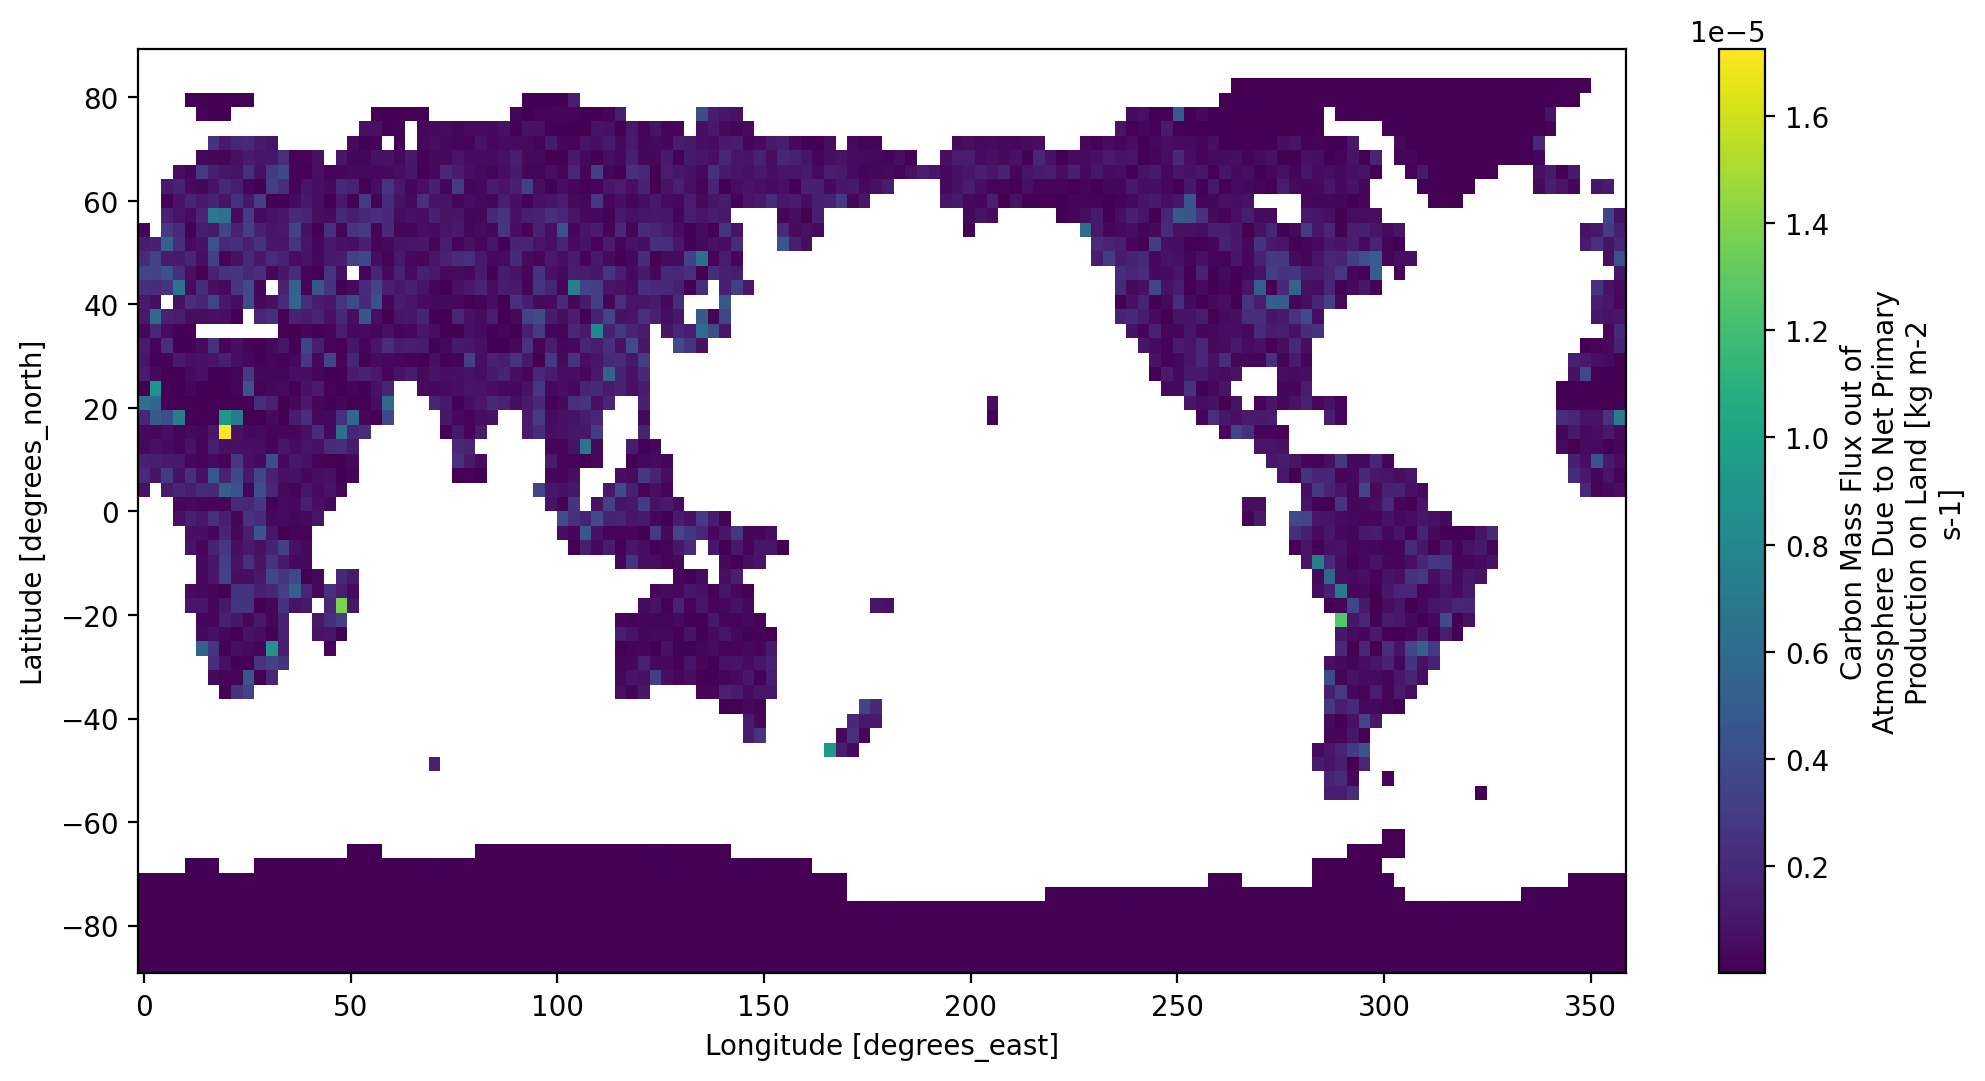

In [9]:
ct_bias.npp.plot()

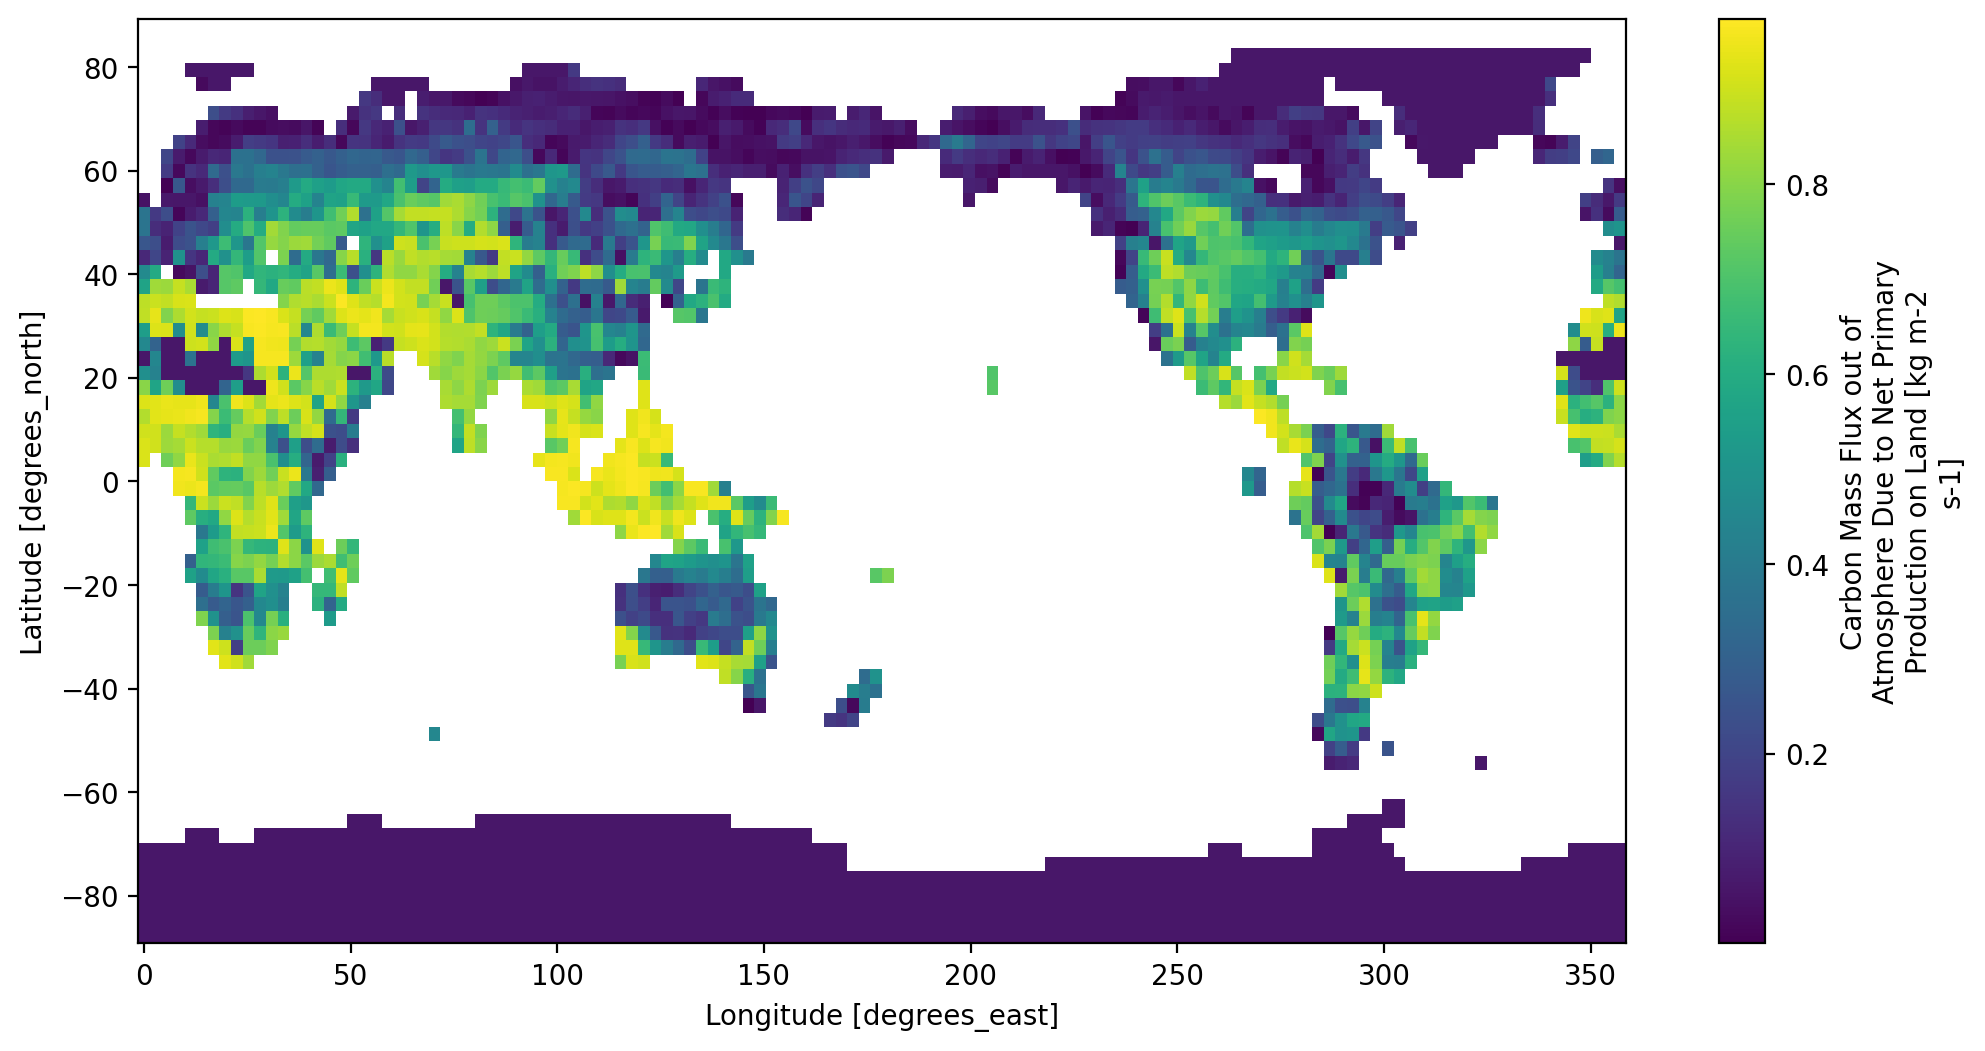

In [10]:
ct_var.npp.plot()

# Testing cross sample

## Idea 0 

use TGAV as one of the predictors. Pretty sure won't work because think not being able to use hist pattern on global NPP to predict future means the patterns (parameters) are different at different temps. Using TGAV as the predictor won't lead to temperature varying patterns (parameters). But check to be sure. 



## Idea 1 

We have 1950-2014 pattern and 2015-2100 pattern from CanESM5.

What if we additionally interpolate from historical pattern params to future pattern params?

$ (int, beta)_t = t*(int,beta)_{hist} + (1-t) * (int, beta)_{585} $

So then we could take the pattern of how the historical pattern evolves over time from CanESM5 and 
apply to the historical pattern(s) from TRENDY.

- absolutely an assumption and there would be caveats eg we are specifcally applying the CanESM5 ssp585 time evolution to TRENDY historical because we can show for CanESM5 (other SSPs) that just using history to estimate 585 is wrong. 

- Don't see a way around extrapolating if we want to use TRENDY. But we could look at a couple ESMs and Scenarios 

- This would also essentially move things out of sync in the feedback. We'd be applying a 585 pattern to a hector trajectory that isn't necessarily getting to 585. 

- how much do the spatial patterns differ by ESM


/opt/miniconda3/envs/cmip6/lib/python3.14/site-packages/xarray/core/nputils.py:242: RuntimeWarning: Degrees of freedom <= 0 for slice.
  result = getattr(npmodule, name)(values, axis=axis, **kwargs)


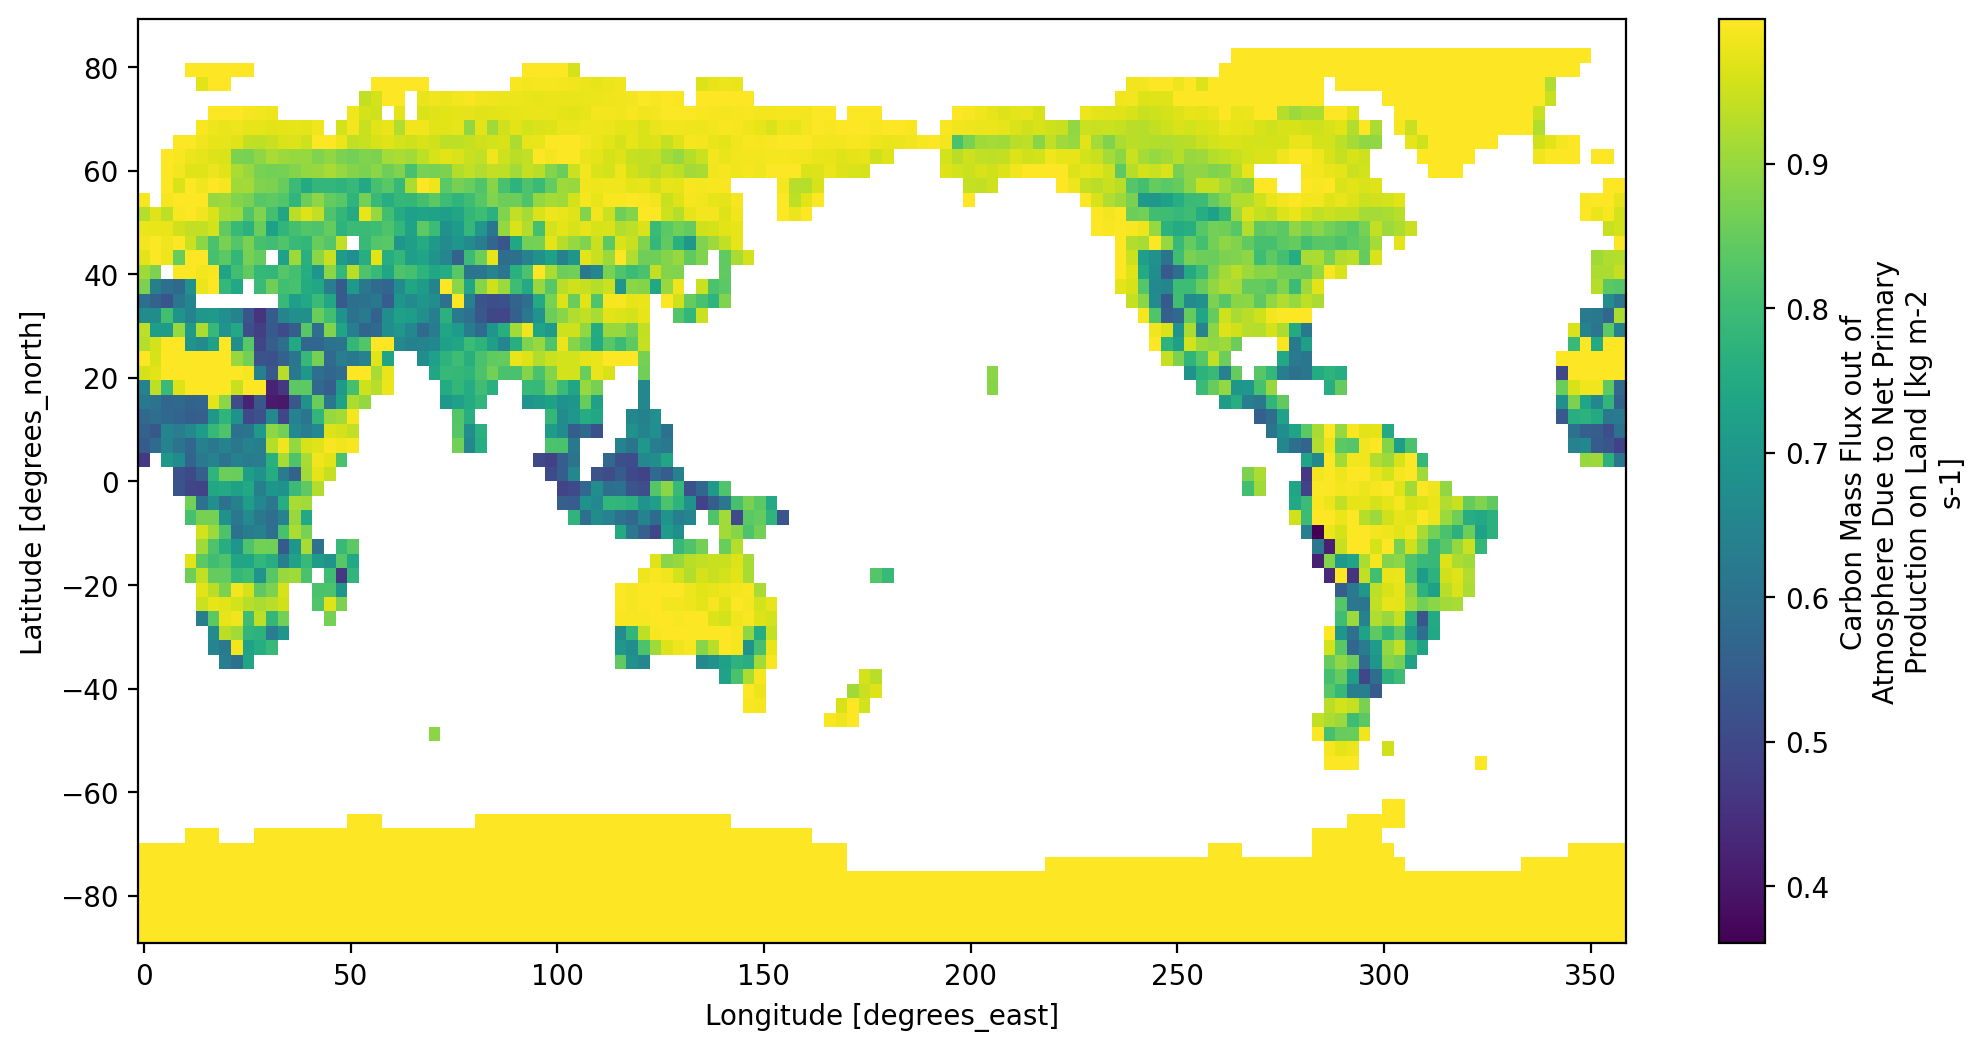

In [13]:
# Idea 0: historical pattern using GSAT as regressor, evaluate that pattern, then test that pattern on ssp585 data

# indep var

hist_gsat = pd.read_csv(DATA_DIR + "temp-data/cmip6_CMIP6_CMIP_CCCma_CanESM5_historical_r10i1p1f1_Amon_tas_gn_v20190429_temp.csv")
global_xr = xr.Dataset({'GSAT': xr.DataArray(hist_gsat['value']-273.16,
                                             coords = [field['time']], 
                                             dims = ['time'])}) 
x = global_xr['GSAT'].values.reshape(-1,1)


# dependent var
testglobal = field.copy()
stacked = testglobal.stack(unifiedspatial=['lat', 'lon']).copy()
y = stacked[VAR].fillna(0).values


# do regression
linear_regressor = skl.linear_model.LinearRegression(fit_intercept = True)
linear_regressor.fit(x,y)

# shape params
tmp = linear_regressor.coef_.T
beta = xr.Dataset({'beta': xr.DataArray(linear_regressor.coef_.T, 
                                        coords = [['estimated_param'], stacked.unifiedspatial], 
                                        dims=['param', 'unifiedspatial'])}).unstack('unifiedspatial').copy()
intercept = xr.Dataset({'intercept': xr.DataArray(linear_regressor.intercept_.reshape(tmp.shape),
                                                   coords = [['estimated_param'], stacked.unifiedspatial], 
                                                   dims=['param', 'unifiedspatial'])}).unstack('unifiedspatial').copy()

yhat = beta['beta'] * global_xr['GSAT'] + intercept['intercept']
yhat = yhat.sel(param='estimated_param').drop_vars('param') .copy()
yhat = yhat.transpose(*("lat", "lon", "time")).rename(VAR).copy()


# evaluate this pattern
# Error metrics for quailty checks, these are going to tbe the most standardized versions.
# TODO this following chunk is part of the QAQC and will probably be removed from the formal pipeline
# TODO might want to consider masking out the 0s so that we don't run into issues with NAs, although
# that might be overkil...
# These are all our "insample" error metrics
var_obs = field.var(dim="time")
sd_obs = var_obs ** 0.5
sd_sim = yhat.var(dim="time") ** 0.5
mean_obs = field.mean(dim="time")
mean_sim = yhat.mean(dim="time")

resid = yhat - field
mse = (resid * resid).mean(dim="time")
ns = (mse / var_obs) ** 0.5
ct_bias = abs(mean_obs - mean_sim) / sd_obs
ct_var = sd_sim / sd_obs

ns.npp.plot()

/opt/miniconda3/envs/cmip6/lib/python3.14/site-packages/xarray/core/nputils.py:242: RuntimeWarning: Degrees of freedom <= 0 for slice.
  result = getattr(npmodule, name)(values, axis=axis, **kwargs)


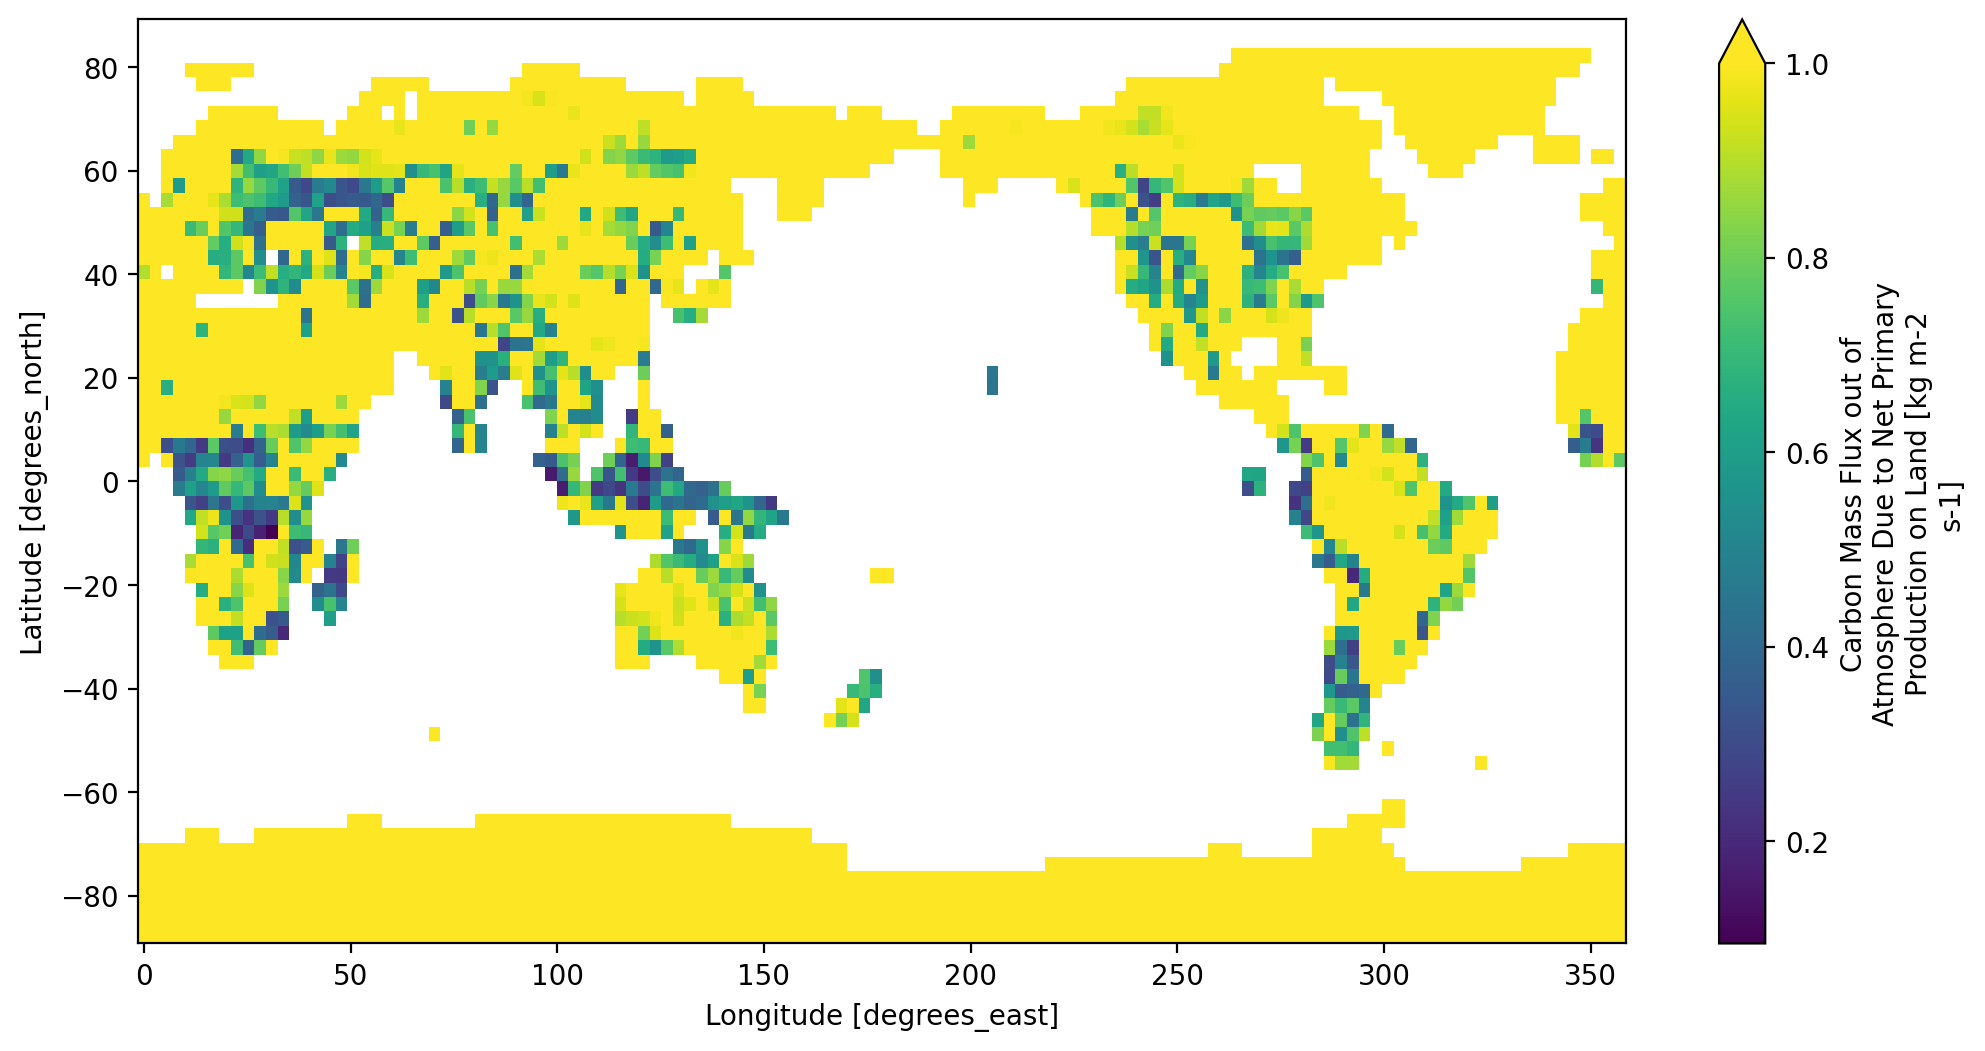

In [20]:
# load and prep comparison data
d = xr.open_dataset(DATA_DIR+"raw-data/data/CCCma_CanESM5_ssp585_r10i1p1f1_Lmon_npp_gn_v20190429_.nc")
cell_area = xr.open_dataset("data/raw-data/areacella/CCCma_CanESM5_ssp585_r10i1p1f1_Lmon_npp_gn_v20190429_.nc")
land_percent = xr.open_dataset(DATA_DIR+"raw-data/sftlf/CCCma_CanESM5_ssp585_r10i1p1f1_Lmon_npp_gn_v20190429_.nc")    
# Save meta data information
VAR = d.variable_id
all_attrs = d.attrs
original_units = d[VAR].units
keys_to_keep = ["variable_id", "variant_label", "experiment_id", "frequency", "grid_label", "source_id"]
meta_data = {k: all_attrs[k] for k in keys_to_keep if k in all_attrs}
# The first thing we need to do is get the annual field which should be total
# carbon content per year.
# TODO right now we are assuming a 365 day calander across models we may want to update this.
seconds_per_year = (365 * 24 * 60 * 60) / 12
annual_monthly_rate = d.coarsen(time=12).sum() * seconds_per_year
 # Calculate the land cell area, make sure that the land cell area where
# land is 0 assign it a na value so that
land_cell_area = cell_area.areacella * land_percent.sftlf * (1 / 100)
land_cell_area = land_cell_area.where(land_cell_area != 0, other=np.nan)
# Calculate the total annual carbon. Update attributes to reflect the
# new units.
# TODO figure out a way to add the attribtue information!
field_fut = annual_monthly_rate * land_cell_area.values
# Convert from kg of C to the Petagram of C which are the
# unites I am used to thinking in/hector units.
field_fut = field_fut * 1e-12
# annual_total_carbon = annual_total_carbon.assign_attrs()
# meta_data["frequency"] = "yr"
# meta_data["units"] = original_units.replace(" m-2 s-1", "")
# for k, v in meta_data.items():
#    annual_total_carbon.attrs[f"{k}"] = str(v)
field_fut.attrs["frequency"] = "year"
field_fut.attrs["units"] = "Pg C"


# apply pattern to SSP585 data
fut_gsat = pd.read_csv(DATA_DIR + "temp-data/cmip6_CMIP6_ScenarioMIP_CCCma_CanESM5_ssp585_r10i1p1f1_Amon_tas_gn_v20190429_temp.csv")
global_xr_fut = xr.Dataset({'GSAT': xr.DataArray(fut_gsat['value']-273.16,
                                             coords = [field_fut['time']], 
                                             dims = ['time'])}) 



yhat_fut = beta['beta'] * global_xr_fut['GSAT'] + intercept['intercept']
yhat_fut = yhat_fut.sel(param='estimated_param').drop_vars('param') .copy()
yhat_fut = yhat_fut.transpose(*("lat", "lon", "time")).rename(VAR).copy()



# errors
var_obs = field_fut.var(dim="time")
sd_obs = var_obs ** 0.5
sd_sim = yhat_fut.var(dim="time") ** 0.5
mean_obs = field_fut.mean(dim="time")
mean_sim = yhat_fut.mean(dim="time")

resid = yhat_fut - field_fut
mse = (resid * resid).mean(dim="time")
ns = (mse / var_obs) ** 0.5
ct_bias = abs(mean_obs - mean_sim) / sd_obs
ct_var = sd_sim / sd_obs


ns.npp.plot(vmax = 1)


In [21]:
gridded_bias = abs(mean_obs - mean_sim)

global_bias = gridded_bias.sum(other_dims, skipna=True)
global_bias

<xarray.Dataset> Size: 8B
Dimensions:  ()
Data variables:
    npp      float64 8B 23.7
Attributes: (12/57)
    CCCma_model_hash:            66c9146b8290f2c6ba88fd7d4119ba01e952e060
    CCCma_parent_runid:          rc3.1-his10
    CCCma_pycmor_hash:           33c30511acc319a98240633965a04ca99c26427e
    CCCma_runid:                 rc3.1-s8510
    Conventions:                 CF-1.7 CMIP-6.2
    YMDH_branch_time_in_child:   2015:01:01:00
    ...                          ...
    tracking_id:                 hdl:21.14100/5ff99cf0-39a3-4760-b6cc-44841c6...
    variable_id:                 npp
    variant_label:               r10i1p1f1
    version:                     v20190429
    version_id:                  v20190429
    units:                       Pg C

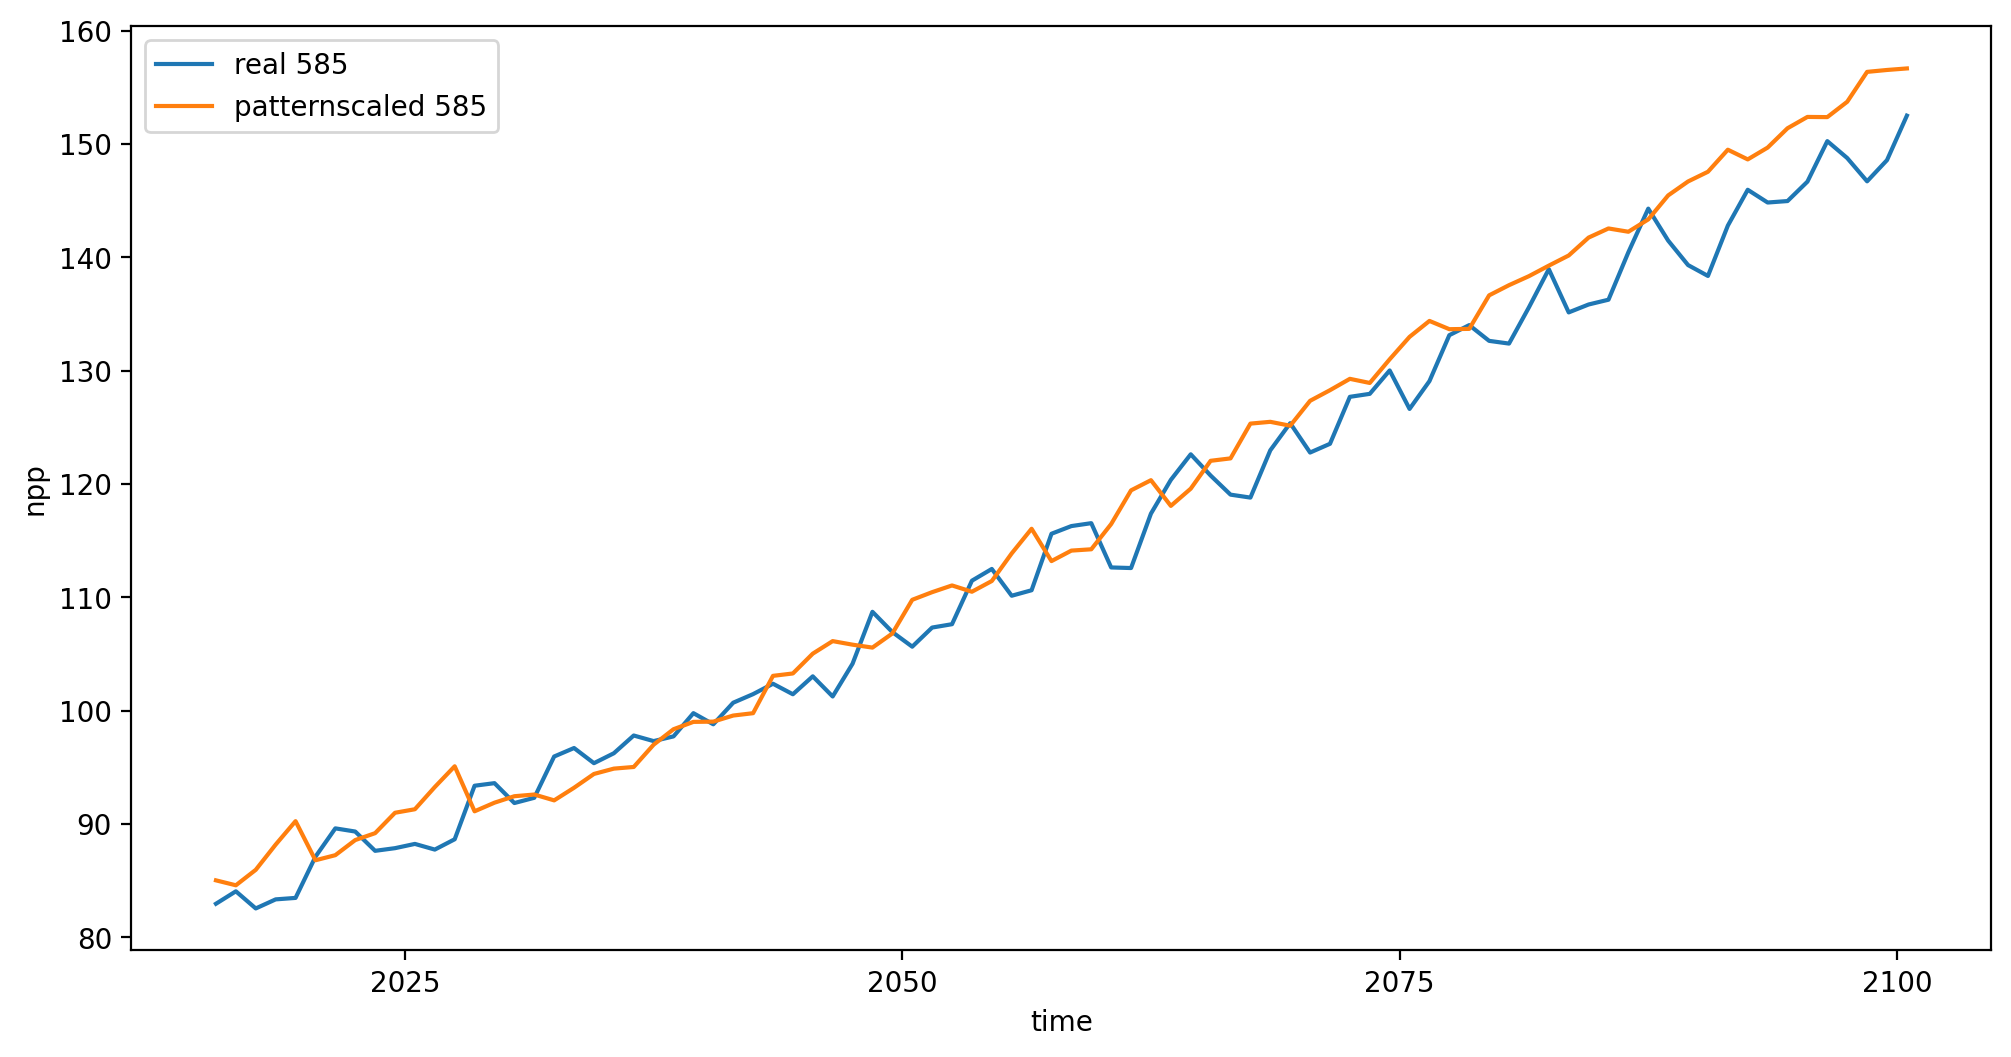

In [22]:
# get the variance in the global real SSP585 NPP to compare
#global_fut_real
global_fut585 = field_fut.sum(other_dims, skipna=True)
global_yhat585 = yhat_fut.sum(other_dims-{'bnds'}, skipna=True)

fig, ax = plt.subplots()
global_fut585.npp.plot(ax=ax, label = 'real 585')
global_yhat585.plot(ax=ax, label='patternscaled 585')
plt.legend()
plt.show()


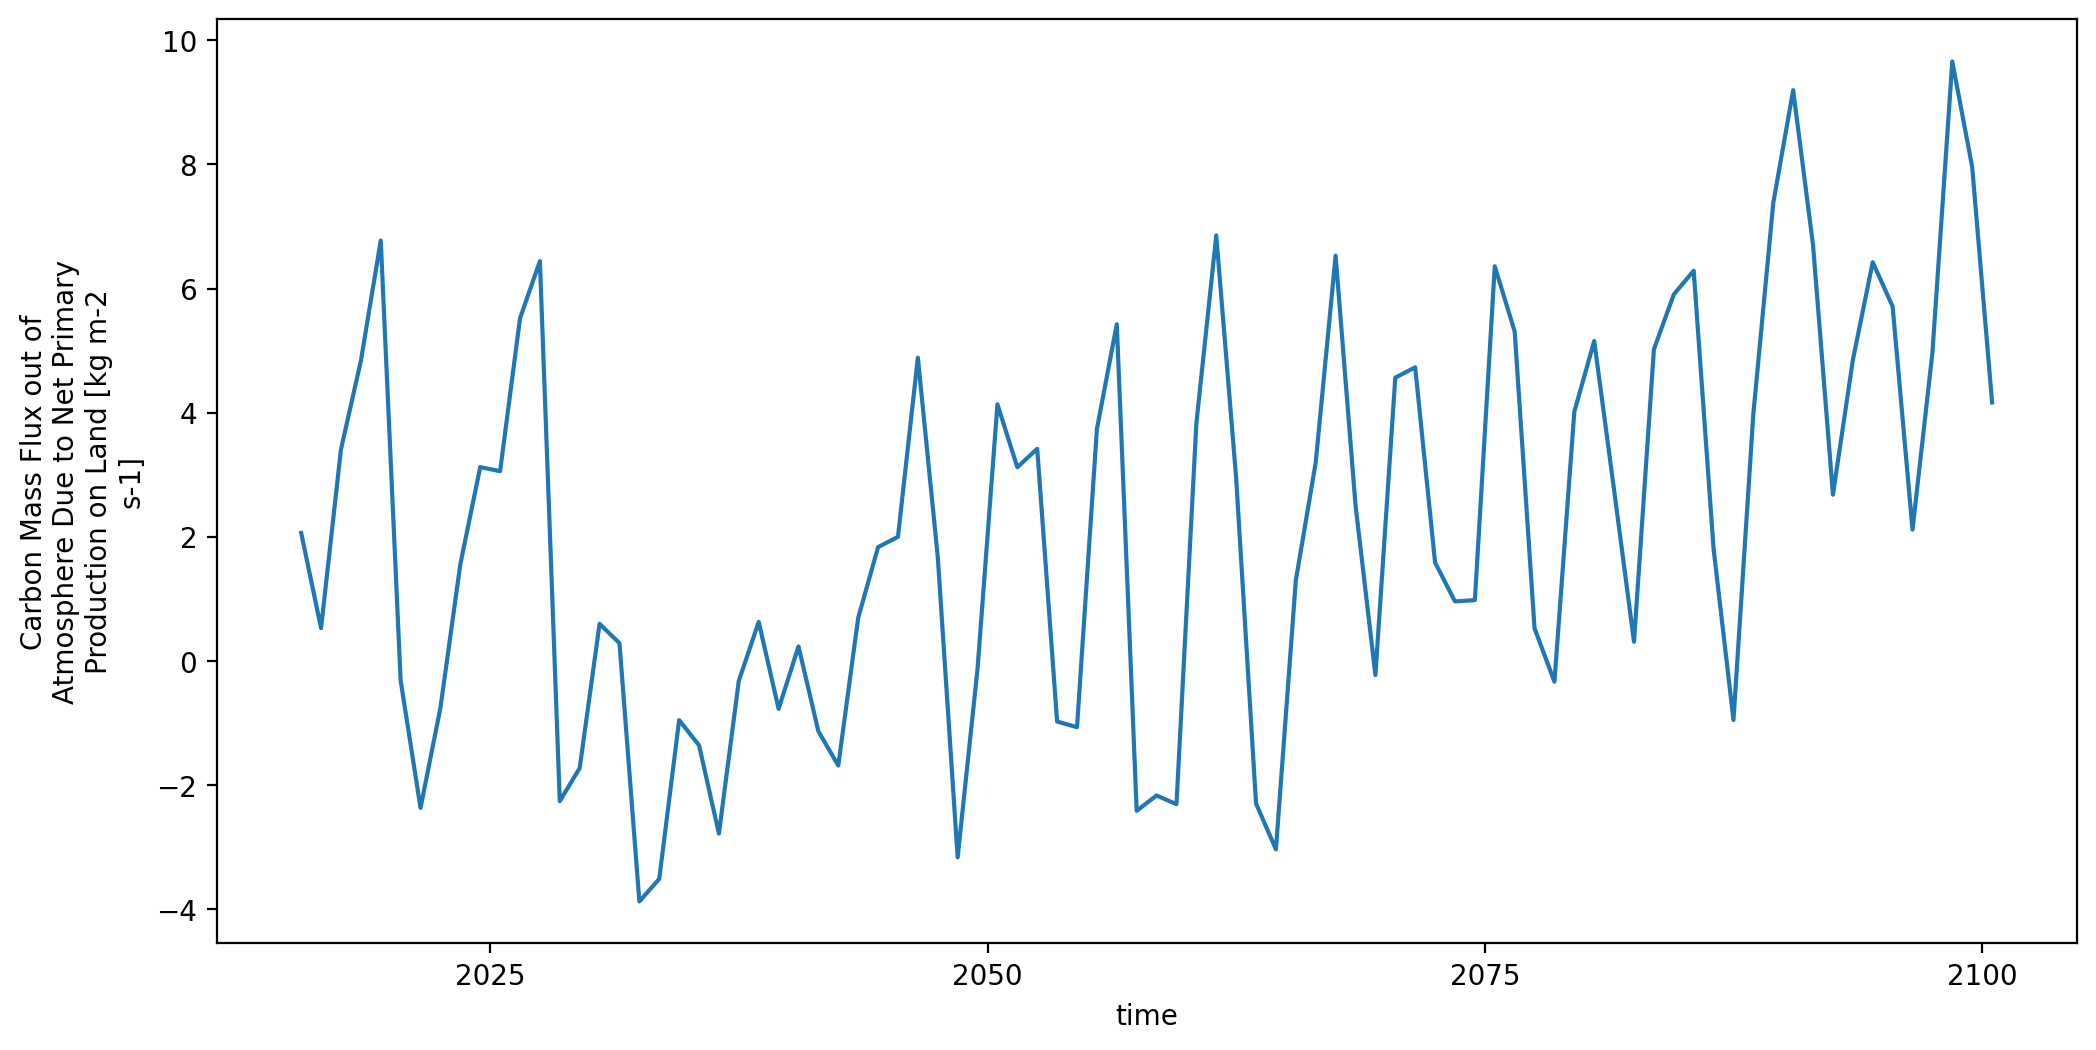

In [23]:
abs_resids = abs(resid)

global_resids = resid.sum(other_dims, skipna=True)
global_resids.npp.plot()

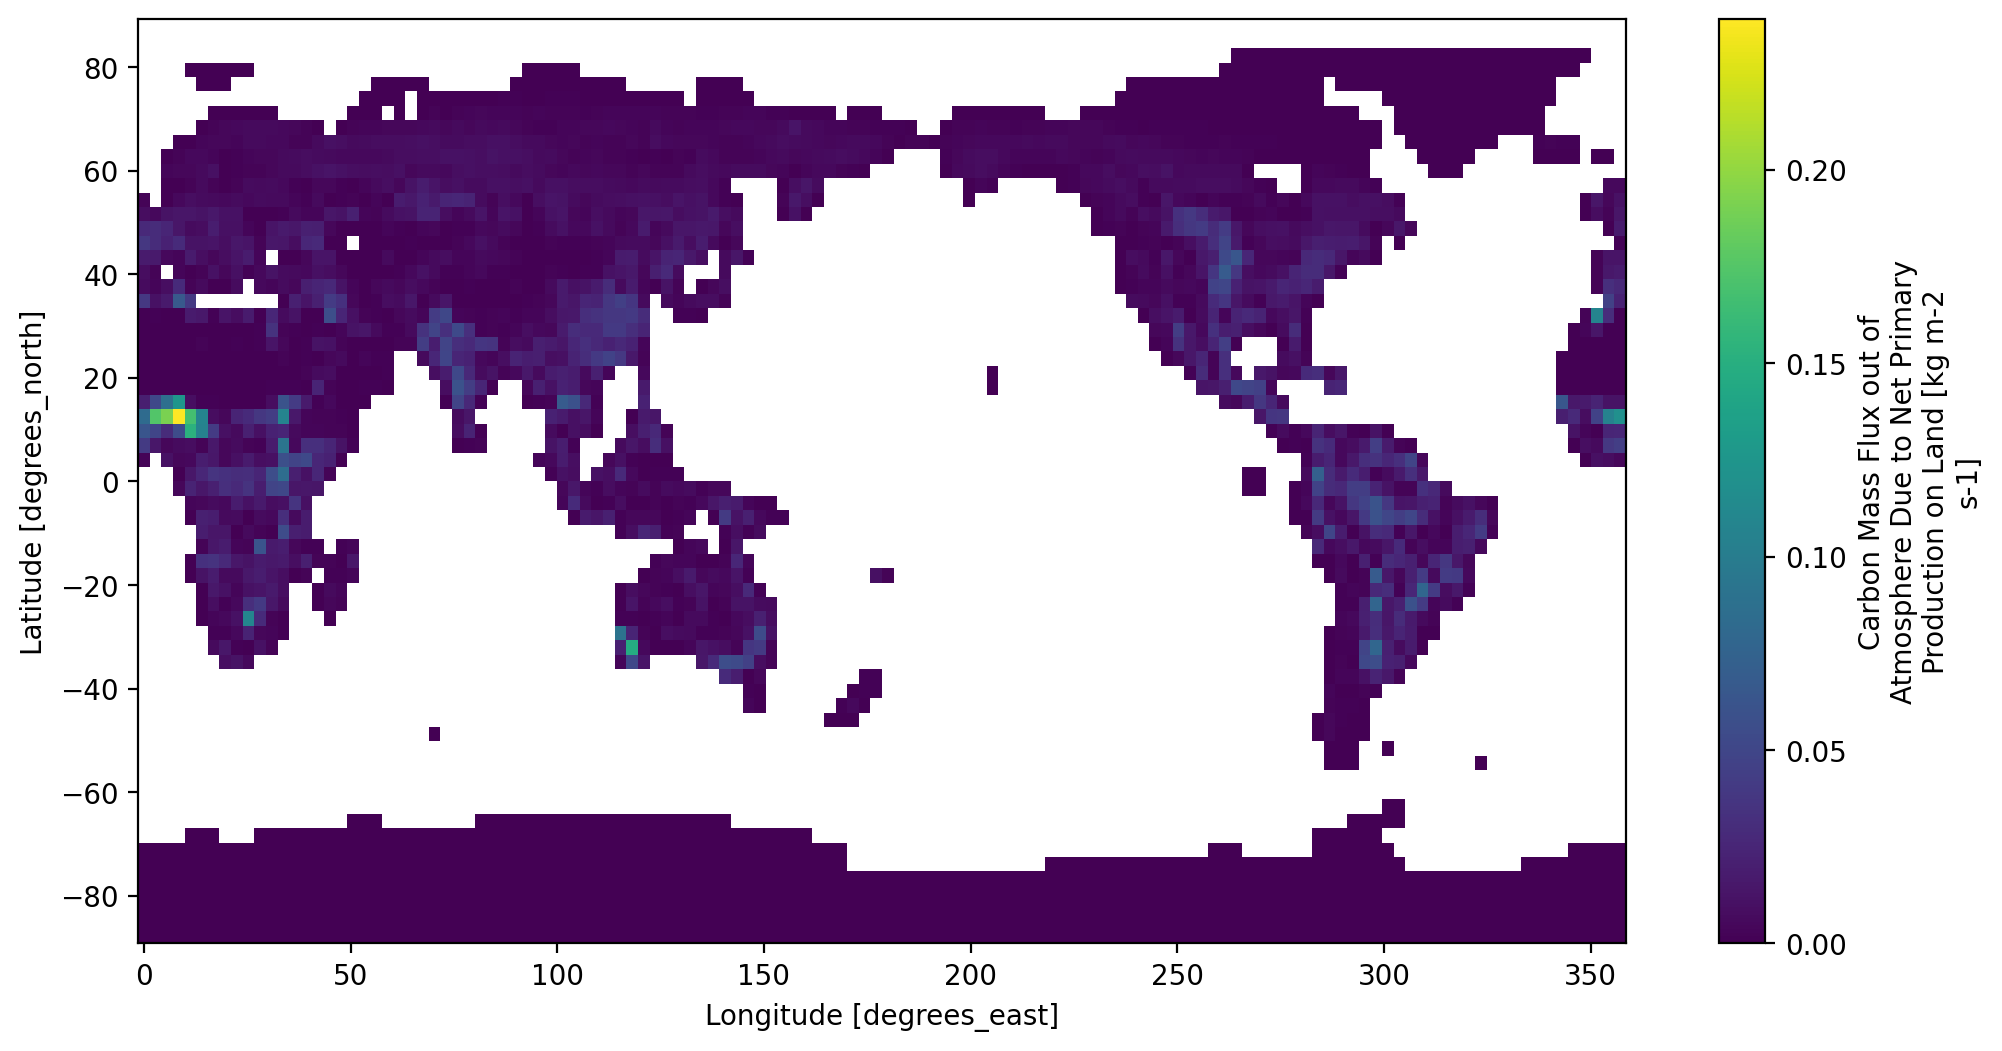

In [24]:
gridded_bias.npp.plot()


In [25]:
top15grids =field_fut.npp.mean(dim='time').stack(cell=('lon', 'lat')).to_series().nlargest(15).reset_index()

top15grids['max_bias/mean_npp'] = 0.234 / top15grids['npp']

top15grids

,lon,lat,npp,max_bias/mean_npp
0,33.7500,-4.185921,0.232084,1.008255
1,33.7500,-1.395307,0.229906,1.017805
2,8.4375,12.557756,0.227615,1.028051
3,11.2500,9.767146,0.221315,1.057317
4,112.5000,-1.395307,0.221203,1.057850
5,28.1250,-1.395307,0.220425,1.061586
6,78.7500,12.557756,0.219996,1.063656
7,30.9375,-1.395307,0.219383,1.066630
8,30.9375,-4.185921,0.216892,1.078879
9,36.5625,-9.767146,0.216295,1.081854


# So 100% error in the most productive grid cell.

from applying the historical pattern to 585

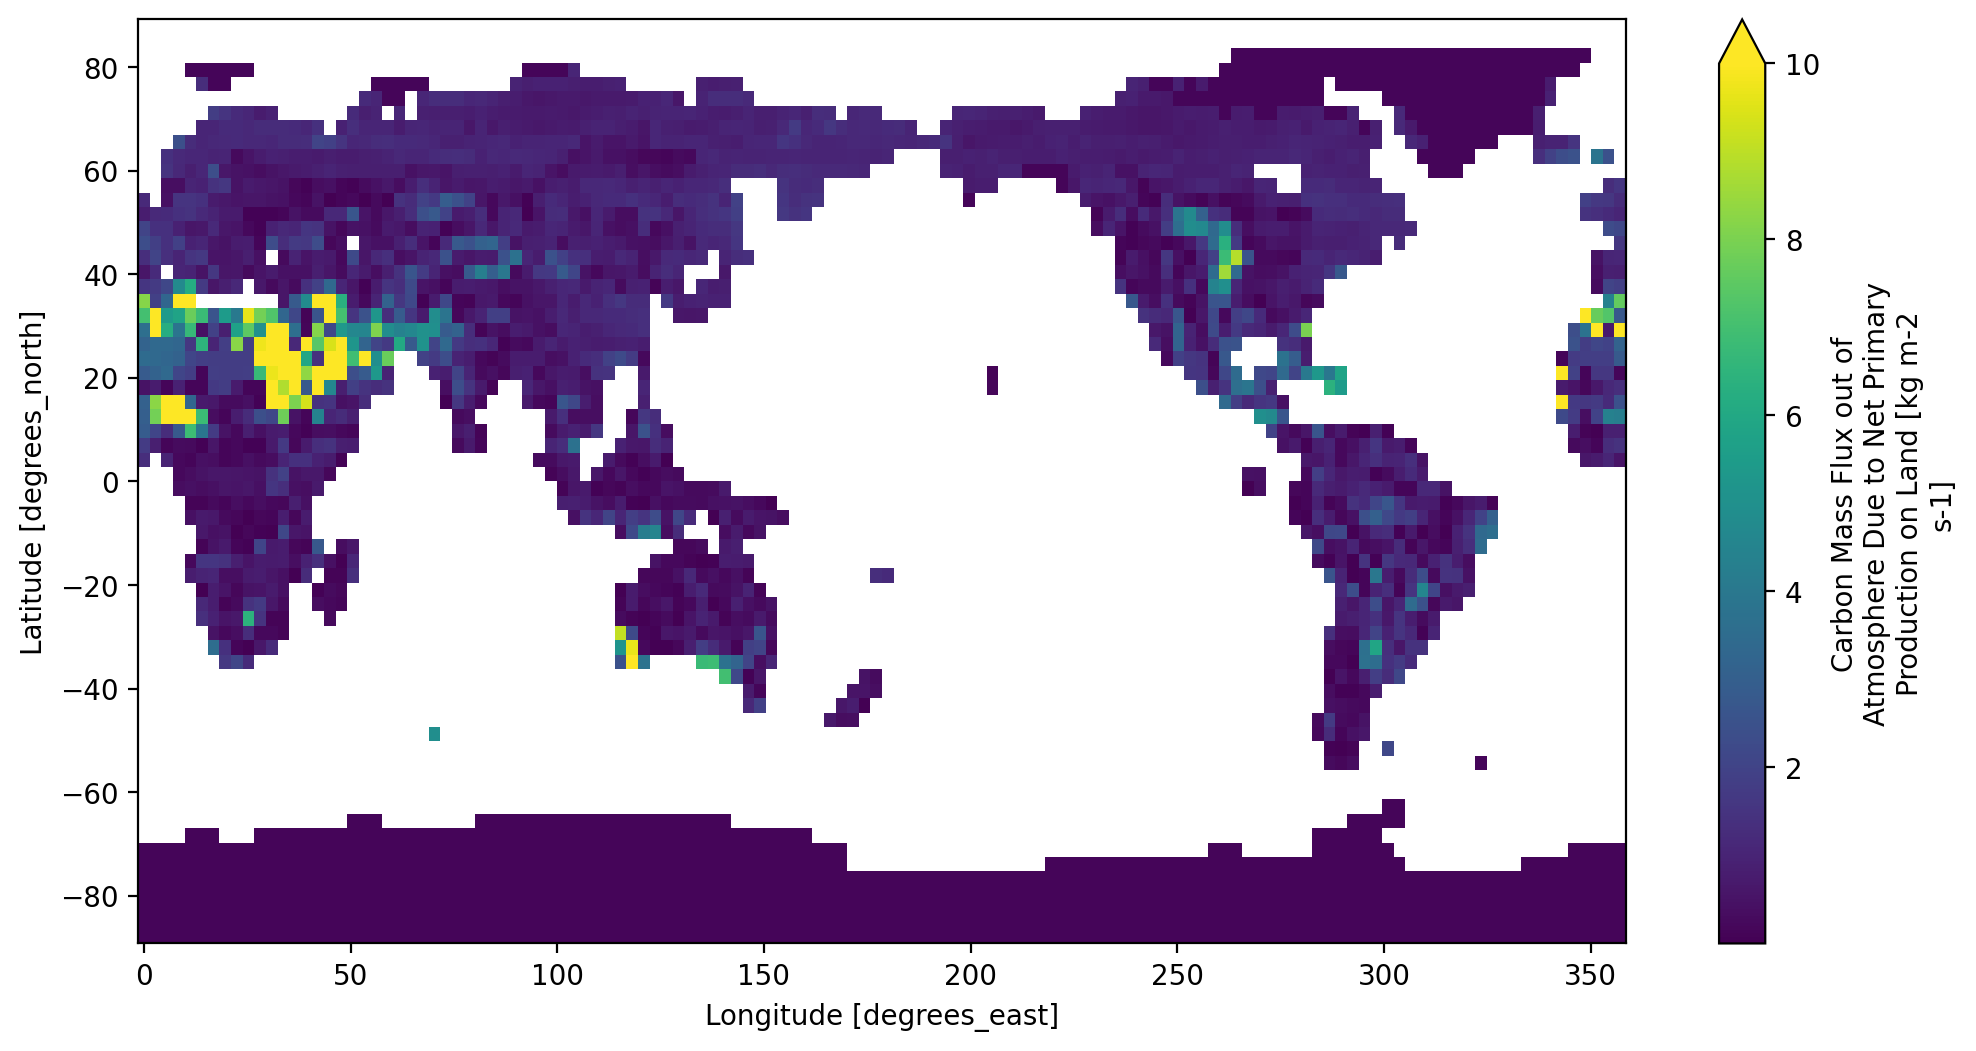

In [26]:
# continue evaluating - drop the one really bad grid cell so can see how things are elsewhere
ct_bias.npp.plot(vmax = 10)

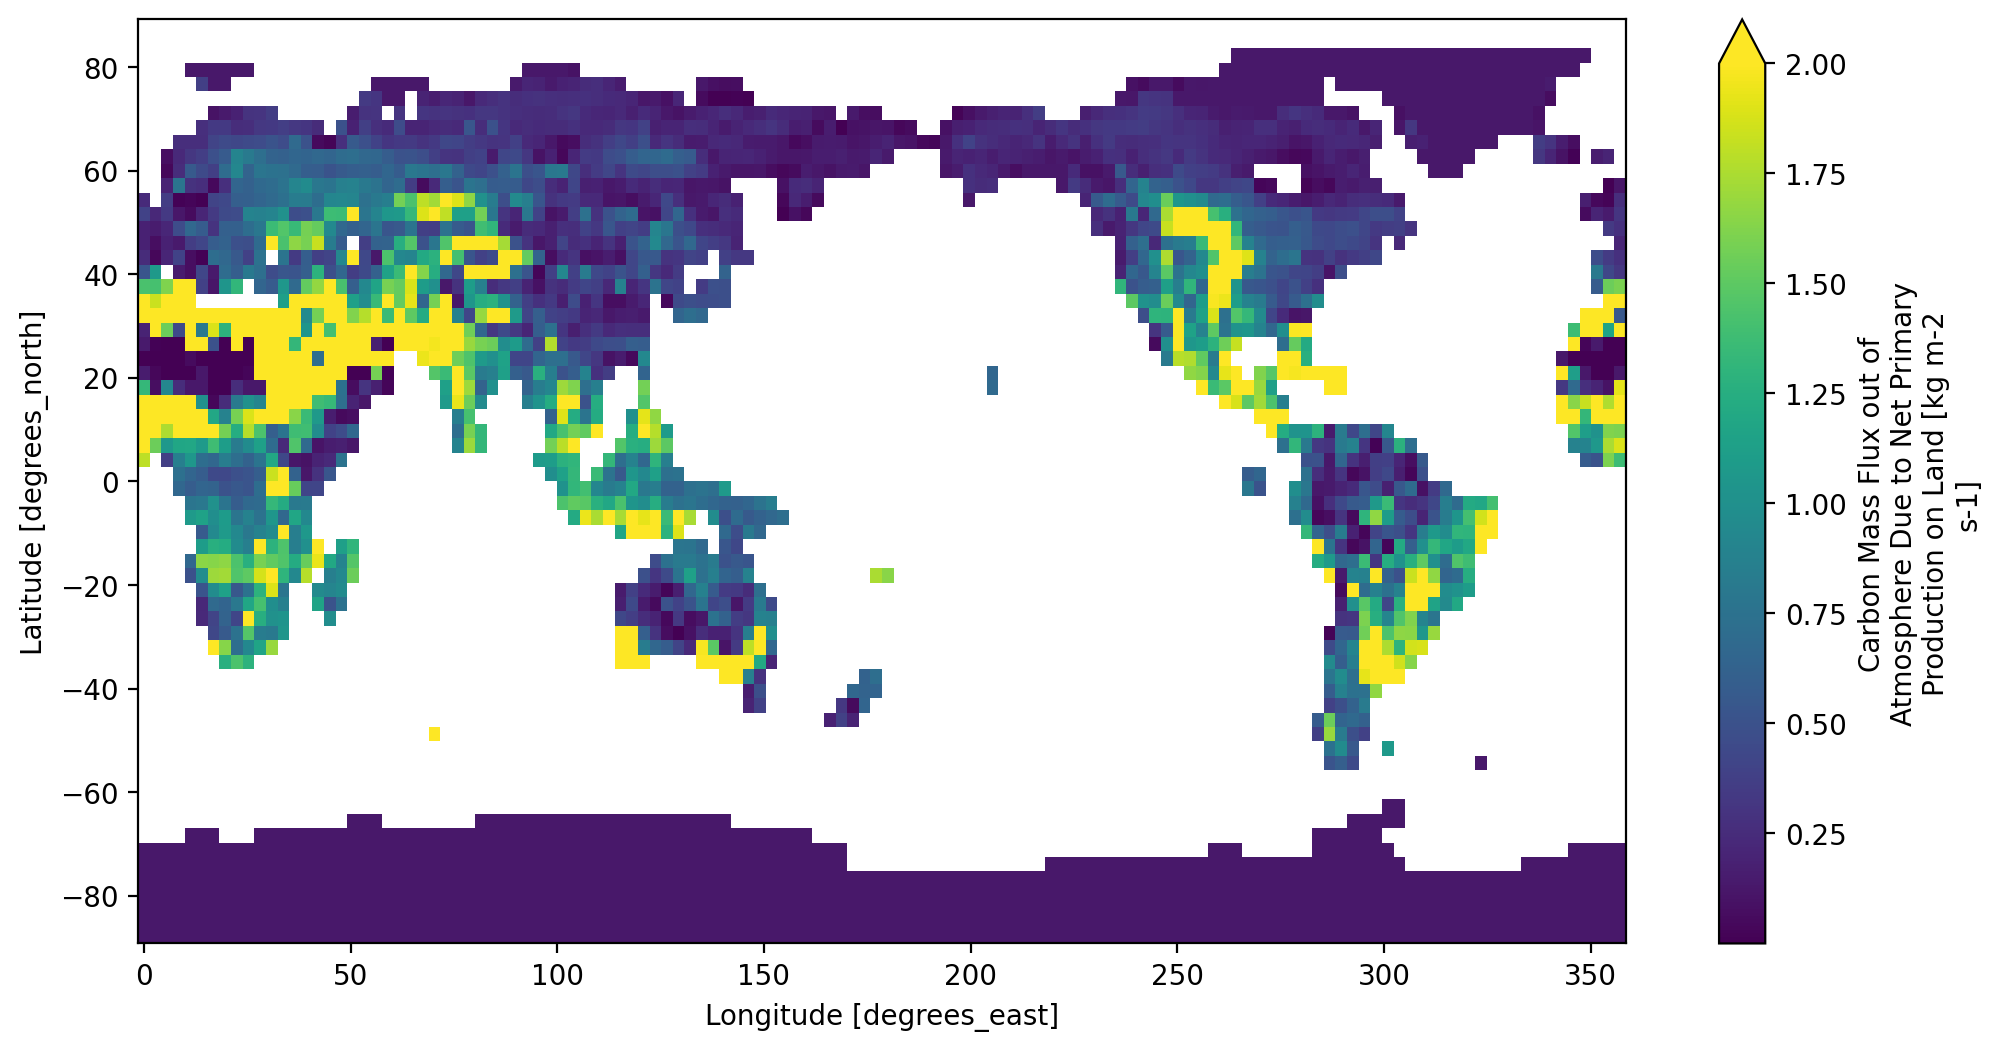

In [27]:
ct_var.npp.plot(vmax   = 2)

## Idea 2


Patterns by warming level (stitches inspired)

- this is stitches and using stitches to write the validation paper would be a lot more straightforward

- but it would probably very slow in an actual GCAM run, especially since we'd be generating gridded data when we only need GCAM region level. 

- We also don't really care about variability, which we'd be spending time creating and then smoothing back out if we use stitches.

- but we could mimic stitches with the patterns.


- Easy test: is Hector global NPP at +1deg the same whether that happens in 2070 or 2040? Assume not because history matters more in terrestrial: The running change in LUC from veg for NPP and soil temp for Rh may be enough to decouple from warming level.  

- Maybe decent actually based on below tests. Then the next step is to do the following including cross-check, because the spatial patterns might be different by scenario even for the same levels of warming.

But if somehow it does:

- learn the 0.5deg, 1 deg, 1.5 deg, etc patterns from SSp585 by subsetting the SSP585 data to years where each warming level is that temperature change.

- learn the 0.5deg, 1 deg, 1.5 deg, etc patterns from historical by subsetting the data to years where each warming level is that temperature change.

- learn the 0.5deg, 1 deg, 1.5 deg, etc patterns from SSP245 by subsetting the data to years where each warming level is that temperature change.

- cross check those SSP specific patterns to make sure they are just tied to warming level.

- learn the trendy historical patterns by warming level and apply them that way. 

- Caveat: the warming levels seen in TRENDY history won't be very broad. still have to figure out a way to extrapolate to higher levels to get to the future. At that point, gets ESM and SSP specific just like in Idea 1. 

- less issue of getting out of sync because we can just use Hector Tgav to pick which warming level pattern to use (independent of scenario).





- autoregressive won't work because will depend on not just time but land use at each time whih differs by scenario





In [31]:
hector = pd.read_csv(DATA_DIR+'hector_npp_rh_gsat_long.csv')

In [32]:
### NBP is wrong, need hector runs for NPP and Rh separately but otherwise this is code
NPP = hector[hector.variable == "NPP"]
Rh = hector[hector.variable == "RH"]

gsat = hector[hector.variable == "global_tas"]

In [33]:
f1 = gsat[gsat.value >= 1.75].copy()

f2 = f1[f1.value < 2.0].copy()

f2['ids'] = f2[['scenario']] + f2[['year']].values.astype(str)

NPP['ids'] = NPP[['scenario']] + NPP[['year']].values.astype(str)


NPP[NPP['ids'].isin(f2['ids'])].groupby('scenario')['value'].mean() # key Q: is this ia meaningful range of values or can we say things are basically the same.

scenario
1pctCO2          78.350998
1pctCO2-4xext    78.350998
abruptx2CO2      81.499044
ssp119           60.817446
ssp126           62.107197
ssp245           62.457445
ssp370           62.776627
ssp434           58.513427
ssp460           63.212561
ssp534-over      56.599997
ssp585           62.061040
Name: value, dtype: float64

So NPP ranges 60-62.5 for warming between 1.5-2 for SSP126, 245, 370, 585, 460 aka not diagnostic or overshoot



In [34]:
f1 = gsat[gsat.value >= 0.5].copy()

f2 = f1[f1.value < 0.75].copy()

f2['ids'] = f2[['scenario']] + f2[['year']].values.astype(str)

NPP['ids'] = NPP[['scenario']] + NPP[['year']].values.astype(str)

NPP[NPP['ids'].isin(f2['ids'])].groupby('scenario')['value'].mean() # key Q: is this ia meaningful range of values or can we say t

scenario
1pctCO2          65.083774
1pctCO2-4xext    65.083774
abruptx2CO2      81.499044
impulsex2CO2     61.628408
ssp119           59.083078
ssp126           59.083078
ssp245           59.083078
ssp370           59.083078
ssp434           59.083078
ssp460           59.083078
ssp534-over      59.083078
ssp585           59.083078
Name: value, dtype: float64

In [35]:
f1 = gsat[gsat.value >= 3.5].copy()

f2 = f1[f1.value < 3.75].copy()

f2['ids'] = f2[['scenario']] + f2[['year']].values.astype(str)

Rh['ids'] = Rh[['scenario']] + Rh[['year']].values.astype(str)

Rh[Rh['ids'].isin(f2['ids'])].groupby('scenario')['value'].mean() # key Q: is this ia meaningful range of values or can we say t

scenario
1pctCO2          81.014212
1pctCO2-4xext    81.014212
abruptx4CO2      71.020760
ssp370           64.978504
ssp460           70.158327
ssp585           64.958327
Name: value, dtype: float64

## Test it - half deg bin pattern applied to next half deg bin


### NOTE that for the first test, I did not think about the fact that we should _not_ be using metrics that include normalizing by SD in these exercises because there are so few years in each bin.

This first test is also not great because was just working with data I had at the time, and there weren't great examples to see. 


In [36]:
# bin GSAT
hist_gsat = pd.read_csv(DATA_DIR+"temp-data/cmip6_CMIP6_CMIP_CCCma_CanESM5_historical_r10i1p1f1_Amon_tas_gn_v20190429_temp.csv")
fut_gsat = pd.read_csv(DATA_DIR+"temp-data/cmip6_CMIP6_ScenarioMIP_CCCma_CanESM5_ssp585_r10i1p1f1_Amon_tas_gn_v20190429_temp.csv")

hist_gsat['value'] = hist_gsat['value'] - 273.15
fut_gsat['value'] = fut_gsat['value'] - 273.15

hist_avg = hist_gsat[hist_gsat['year'].between(1850, 1900)]['value'].mean()

hist_gsat['value'] = hist_gsat['value'] - hist_avg
fut_gsat['value'] = fut_gsat['value']  - hist_avg

# And smooth
hist_gsat['smooth_value'] = hist_gsat['value'].rolling(window=13).mean()
fut_gsat['smooth_value'] = fut_gsat['value'].rolling(window=13).mean()

hist_gsat['smooth_value'] = hist_gsat['smooth_value'].fillna(hist_gsat['value'])
fut_gsat['smooth_value'] = fut_gsat['smooth_value'].fillna(fut_gsat['value'])


In [37]:

binsize = 0.5
binedges = np.arange(-5, 10, binsize, )

hist_gsat['group'] = pd.cut(hist_gsat['smooth_value'], bins= binedges)
fut_gsat['group'] = pd.cut(fut_gsat['smooth_value'], bins= binedges)


hist_gsat

,variable,experiment,units,frequency,ensemble,model,year,value,smooth_value,group
0,tas,historical,K,mon,r10i1p1f1,CanESM5,1850,-0.225055,-0.225055,"(-0.5, 0.0]"
1,tas,historical,K,mon,r10i1p1f1,CanESM5,1851,-0.164105,-0.164105,"(-0.5, 0.0]"
2,tas,historical,K,mon,r10i1p1f1,CanESM5,1852,-0.117305,-0.117305,"(-0.5, 0.0]"
3,tas,historical,K,mon,r10i1p1f1,CanESM5,1853,-0.010311,-0.010311,"(-0.5, 0.0]"
4,tas,historical,K,mon,r10i1p1f1,CanESM5,1854,-0.212809,-0.212809,"(-0.5, 0.0]"
...,...,...,...,...,...,...,...,...,...,...
160,tas,historical,K,mon,r10i1p1f1,CanESM5,2010,1.511339,1.230223,"(1.0, 1.5]"
161,tas,historical,K,mon,r10i1p1f1,CanESM5,2011,1.650005,1.292668,"(1.0, 1.5]"
162,tas,historical,K,mon,r10i1p1f1,CanESM5,2012,1.754281,1.358024,"(1.0, 1.5]"
163,tas,historical,K,mon,r10i1p1f1,CanESM5,2013,1.676063,1.411920,"(1.0, 1.5]"


In [38]:
grouped_year_ranges = pd.DataFrame()    
for group_name, group_df in hist_gsat.groupby('group'):
    grouped_year_ranges = pd.concat([grouped_year_ranges,
                                     pd.DataFrame({
                                       'scenario': group_df['experiment'].unique(),  
                                       'ensemble': group_df['ensemble'].unique(), 
                                       'model': group_df['model'].unique(), 
                                       'start_yr': np.min(group_df['year']),
                                       'stop_yr': np.max(group_df['year']),
                                       'group': group_df['group'].unique()
                                     })],
                                     ignore_index=True)
# end for over groups in historical


for group_name, group_df in fut_gsat.groupby('group'):
    grouped_year_ranges = pd.concat([grouped_year_ranges,
                                     pd.DataFrame({
                                       'scenario': group_df['experiment'].unique(),  
                                       'ensemble': group_df['ensemble'].unique(), 
                                       'model': group_df['model'].unique(), 
                                       'start_yr': np.min(group_df['year']),
                                       'stop_yr': np.max(group_df['year']),
                                       'group': group_df['group'].unique()
                                     })],
                                     ignore_index=True)
# end for over groups in future

grouped_year_ranges

,scenario,ensemble,model,start_yr,stop_yr,group
0,historical,r10i1p1f1,CanESM5,1850,1918,"(-0.5, 0.0]"
1,historical,r10i1p1f1,CanESM5,1856,1996,"(0.0, 0.5]"
2,historical,r10i1p1f1,CanESM5,1997,2005,"(0.5, 1.0]"
3,historical,r10i1p1f1,CanESM5,2006,2014,"(1.0, 1.5]"
4,ssp585,r10i1p1f1,CanESM5,2015,2021,"(1.5, 2.0]"
5,ssp585,r10i1p1f1,CanESM5,2019,2038,"(2.0, 2.5]"
6,ssp585,r10i1p1f1,CanESM5,2039,2046,"(2.5, 3.0]"
7,ssp585,r10i1p1f1,CanESM5,2047,2053,"(3.0, 3.5]"
8,ssp585,r10i1p1f1,CanESM5,2054,2060,"(3.5, 4.0]"
9,ssp585,r10i1p1f1,CanESM5,2061,2066,"(4.0, 4.5]"


/opt/miniconda3/envs/cmip6/lib/python3.14/site-packages/xarray/core/nputils.py:242: RuntimeWarning: Degrees of freedom <= 0 for slice.
  result = getattr(npmodule, name)(values, axis=axis, **kwargs)
/opt/miniconda3/envs/cmip6/lib/python3.14/site-packages/xarray/core/nputils.py:242: RuntimeWarning: Degrees of freedom <= 0 for slice.
  result = getattr(npmodule, name)(values, axis=axis, **kwargs)


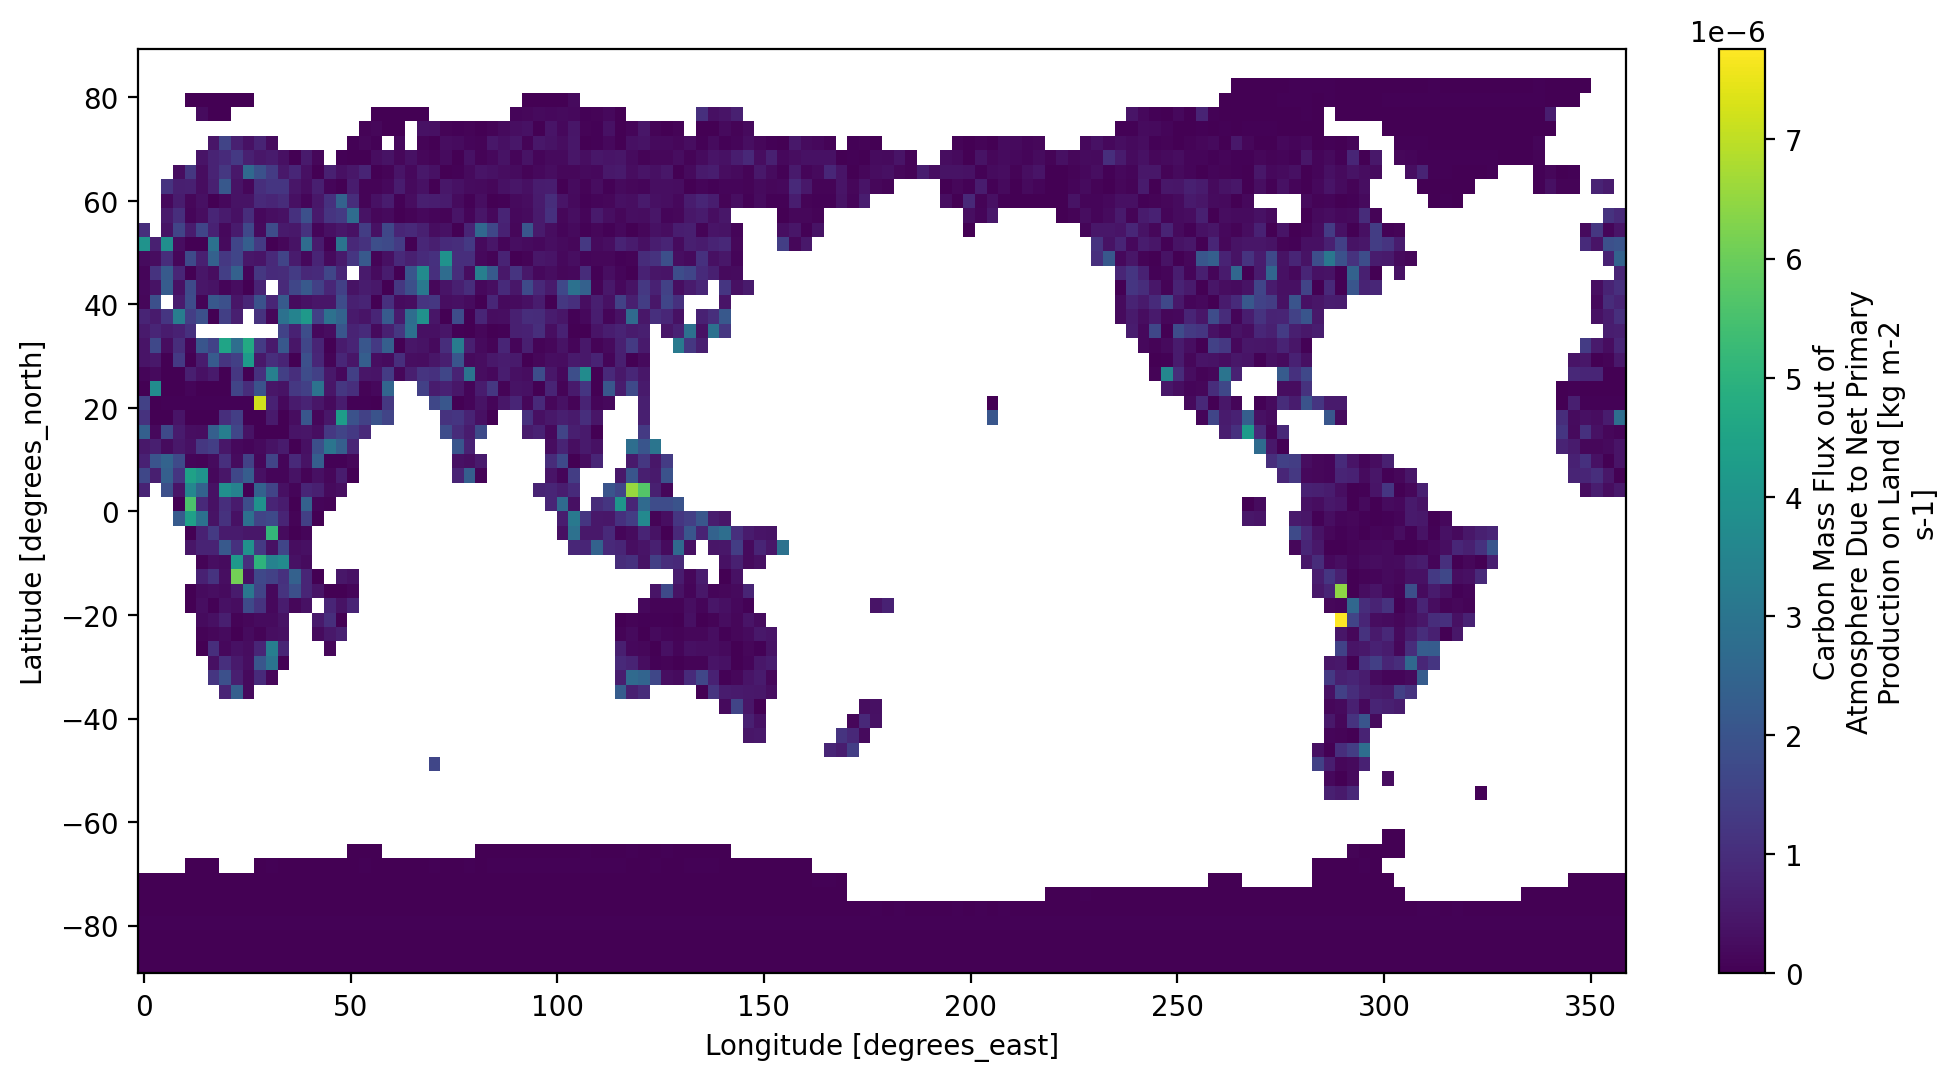

In [39]:
# Should properly smoosh all the data together  and loop over all groups
# Especially if pulling from all experiments + average over ensemble members.


# But because we are looking at hist vs ssp585, there isn't overlap.
# best we can do is train on (1.0,1.5] and test on (1.5, 2]. 
# Just manually filter to years for now

# train

tag = 'CanESM5_historical_r10i1p1f1n_npp_1to1p5'
field_ofile = DATA_DIR + "field/" + tag + "field.nc"
global_ofile = DATA_DIR + "global/" + tag + "global.nc"

d = xr.open_dataset(DATA_DIR+"raw-data/data/CCCma_CanESM5_historical_r10i1p1f1_Lmon_npp_gn_v20190429_.nc").sel(time= slice('2006','2014'))
cell_area = xr.open_dataset(DATA_DIR+"raw-data/areacella/CCCma_CanESM5_historical_r10i1p1f1_Lmon_npp_gn_v20190429_.nc")
land_percent = xr.open_dataset(DATA_DIR+"raw-data/sftlf/CCCma_CanESM5_historical_r10i1p1f1_Lmon_npp_gn_v20190429_.nc")

# Save meta data information
VAR = d.variable_id
all_attrs = d.attrs
original_units = d[VAR].units
keys_to_keep = ["variable_id", "variant_label", "experiment_id", "frequency", "grid_label", "source_id"]
meta_data = {k: all_attrs[k] for k in keys_to_keep if k in all_attrs}

# The first thing we need to do is get the annual field which should be total
# carbon content per year.
# TODO right now we are assuming a 365 day calander across models we may want to update this.
seconds_per_year = (365 * 24 * 60 * 60) / 12
annual_monthly_rate = d.coarsen(time=12).sum() * seconds_per_year

 # Calculate the land cell area, make sure that the land cell area where
# land is 0 assign it a na value so that
land_cell_area = cell_area.areacella * land_percent.sftlf * (1 / 100)
land_cell_area = land_cell_area.where(land_cell_area != 0, other=np.nan)

# Calculate the total annual carbon. Update attributes to reflect the
# new units.
# TODO figure out a way to add the attribtue information!
field = annual_monthly_rate * land_cell_area.values




# Convert from kg of C to the Petagram of C which are the
# unites I am used to thinking in/hector units.
field = field * 1e-12
#np.nanmax(field.npp.values)

# annual_total_carbon = annual_total_carbon.assign_attrs()
# meta_data["frequency"] = "yr"
# meta_data["units"] = original_units.replace(" m-2 s-1", "")
# for k, v in meta_data.items():
#    annual_total_carbon.attrs[f"{k}"] = str(v)
field.attrs["frequency"] = "year"
field.attrs["units"] = "Pg C"
field.to_netcdf(field_ofile, mode="w")

# The global values, for the carbon values this is going to be
# the global total, since we have already multiplied by the
# land area we do not need to do the weighting.
other_dims = set(field.dims) - {"time"} # define that will sum over every dim except time
global_ts = field.sum(other_dims, skipna=True)
global_ts.to_netcdf(global_ofile, mode='w')

# Linear Pattern Scaling Portion
# The times should align since we are originating from the same raw netcdf file
# although this is an assumption TODO don't rely on assumptions.
field_with_global = field.copy()
field_with_global["time"] = global_ts[VAR]
field_with_global = field_with_global.rename({VAR: "field"})

# Use the field with global time series to do the regression.
# Save the results.
reg = field_with_global.polyfit(dim="time", deg=1)

beta = reg.field_polyfit_coefficients.sel(degree=1)
intercept = reg.field_polyfit_coefficients.sel(degree=0)

beta.to_netcdf(DATA_DIR + "beta/" + tag + "beta.nc", mode='w')
intercept.to_netcdf(DATA_DIR + "intercept/" + tag + "intercept.nc", mode='w')

# Beyond here are extra QAQC steps that will not be part of the formal pipeline.
# Pattern-scaled reconstruction
yhat = beta * global_ts + intercept
yhat = yhat.transpose(*("lat", "lon", "time"))
yhat.to_netcdf(DATA_DIR + "yhat/" + tag + "yhat.nc", mode='w')

# Error metrics for quailty checks, these are going to tbe the most standardized versions.
# TODO this following chunk is part of the QAQC and will probably be removed from the formal pipeline
# TODO might want to consider masking out the 0s so that we don't run into issues with NAs, although
# that might be overkil...
# These are all our "insample" error metrics
var_obs = field.var(dim="time")
sd_obs = var_obs ** 0.5
sd_sim = yhat.var(dim="time") ** 0.5
mean_obs = field.mean(dim="time")
mean_sim = yhat.mean(dim="time")

resid = yhat - field
mse = (resid * resid).mean(dim="time")
ns = mse / var_obs
ct_bias = abs(mean_obs - mean_sim) / sd_obs
ct_var = sd_sim / sd_obs

resid.to_netcdf(DATA_DIR + "error_metrics/" + tag + "resid.nc", mode='w')
mse.to_netcdf(DATA_DIR + "error_metrics/" + tag + "mse.nc", mode='w')
ns.to_netcdf(DATA_DIR + "error_metrics/" + tag + "ns.nc", mode='w')
ct_bias.to_netcdf(DATA_DIR + "error_metrics/" + tag + "ctbias.nc", mode='w')
ct_var.to_netcdf(DATA_DIR + "error_metrics/" + tag + "ctvar.nc", mode='w')

ct_bias.npp.plot()

In [41]:
# evaluate on ssp585

# load and prep comparison data
d = xr.open_dataset(DATA_DIR+"raw-data/data/CCCma_CanESM5_ssp585_r10i1p1f1_Lmon_npp_gn_v20190429_.nc").sel(time= slice('2015','2021'))
cell_area = xr.open_dataset("data/raw-data/areacella/CCCma_CanESM5_ssp585_r10i1p1f1_Lmon_npp_gn_v20190429_.nc")
land_percent = xr.open_dataset(DATA_DIR+"raw-data/sftlf/CCCma_CanESM5_ssp585_r10i1p1f1_Lmon_npp_gn_v20190429_.nc")    
# Save meta data information
VAR = d.variable_id
all_attrs = d.attrs
original_units = d[VAR].units
keys_to_keep = ["variable_id", "variant_label", "experiment_id", "frequency", "grid_label", "source_id"]
meta_data = {k: all_attrs[k] for k in keys_to_keep if k in all_attrs}
# The first thing we need to do is get the annual field which should be total
# carbon content per year.
# TODO right now we are assuming a 365 day calander across models we may want to update this.
seconds_per_year = (365 * 24 * 60 * 60) / 12
annual_monthly_rate = d.coarsen(time=12).sum() * seconds_per_year
 # Calculate the land cell area, make sure that the land cell area where
# land is 0 assign it a na value so that
land_cell_area = cell_area.areacella * land_percent.sftlf * (1 / 100)
land_cell_area = land_cell_area.where(land_cell_area != 0, other=np.nan)
# Calculate the total annual carbon. Update attributes to reflect the
# new units.
# TODO figure out a way to add the attribtue information!
field_fut = annual_monthly_rate * land_cell_area.values
# Convert from kg of C to the Petagram of C which are the
# unites I am used to thinking in/hector units.
field_fut = field_fut * 1e-12
# annual_total_carbon = annual_total_carbon.assign_attrs()
# meta_data["frequency"] = "yr"
# meta_data["units"] = original_units.replace(" m-2 s-1", "")
# for k, v in meta_data.items():
#    annual_total_carbon.attrs[f"{k}"] = str(v)
field_fut.attrs["frequency"] = "year"
field_fut.attrs["units"] = "Pg C"



# The global values, for the carbon values this is going to be
# the global total, since we have already multiplied by the
# land area we do not need to do the weighting.
other_dims = set(field_fut.dims) - {"time"} # define that will sum over every dim except time
global_ts_fut = field_fut.sum(other_dims, skipna=True)


# estimate field and compare to truth
yhat_fut = beta * global_ts_fut + intercept
yhat_fut = yhat_fut.transpose(*("lat", "lon", "time")).copy()

# errors
var_obs = field_fut.var(dim="time")
sd_obs = var_obs ** 0.5
sd_sim = yhat_fut.var(dim="time") ** 0.5
mean_obs = field_fut.mean(dim="time")
mean_sim = yhat_fut.mean(dim="time")

resid = yhat_fut - field_fut
mse = (resid * resid).mean(dim="time")
ns = (mse / var_obs) ** 0.5
ct_bias = abs(mean_obs - mean_sim) / sd_obs
ct_var = sd_sim / sd_obs

/opt/miniconda3/envs/cmip6/lib/python3.14/site-packages/xarray/core/nputils.py:242: RuntimeWarning: Degrees of freedom <= 0 for slice.
  result = getattr(npmodule, name)(values, axis=axis, **kwargs)
/opt/miniconda3/envs/cmip6/lib/python3.14/site-packages/xarray/core/nputils.py:242: RuntimeWarning: Degrees of freedom <= 0 for slice.
  result = getattr(npmodule, name)(values, axis=axis, **kwargs)


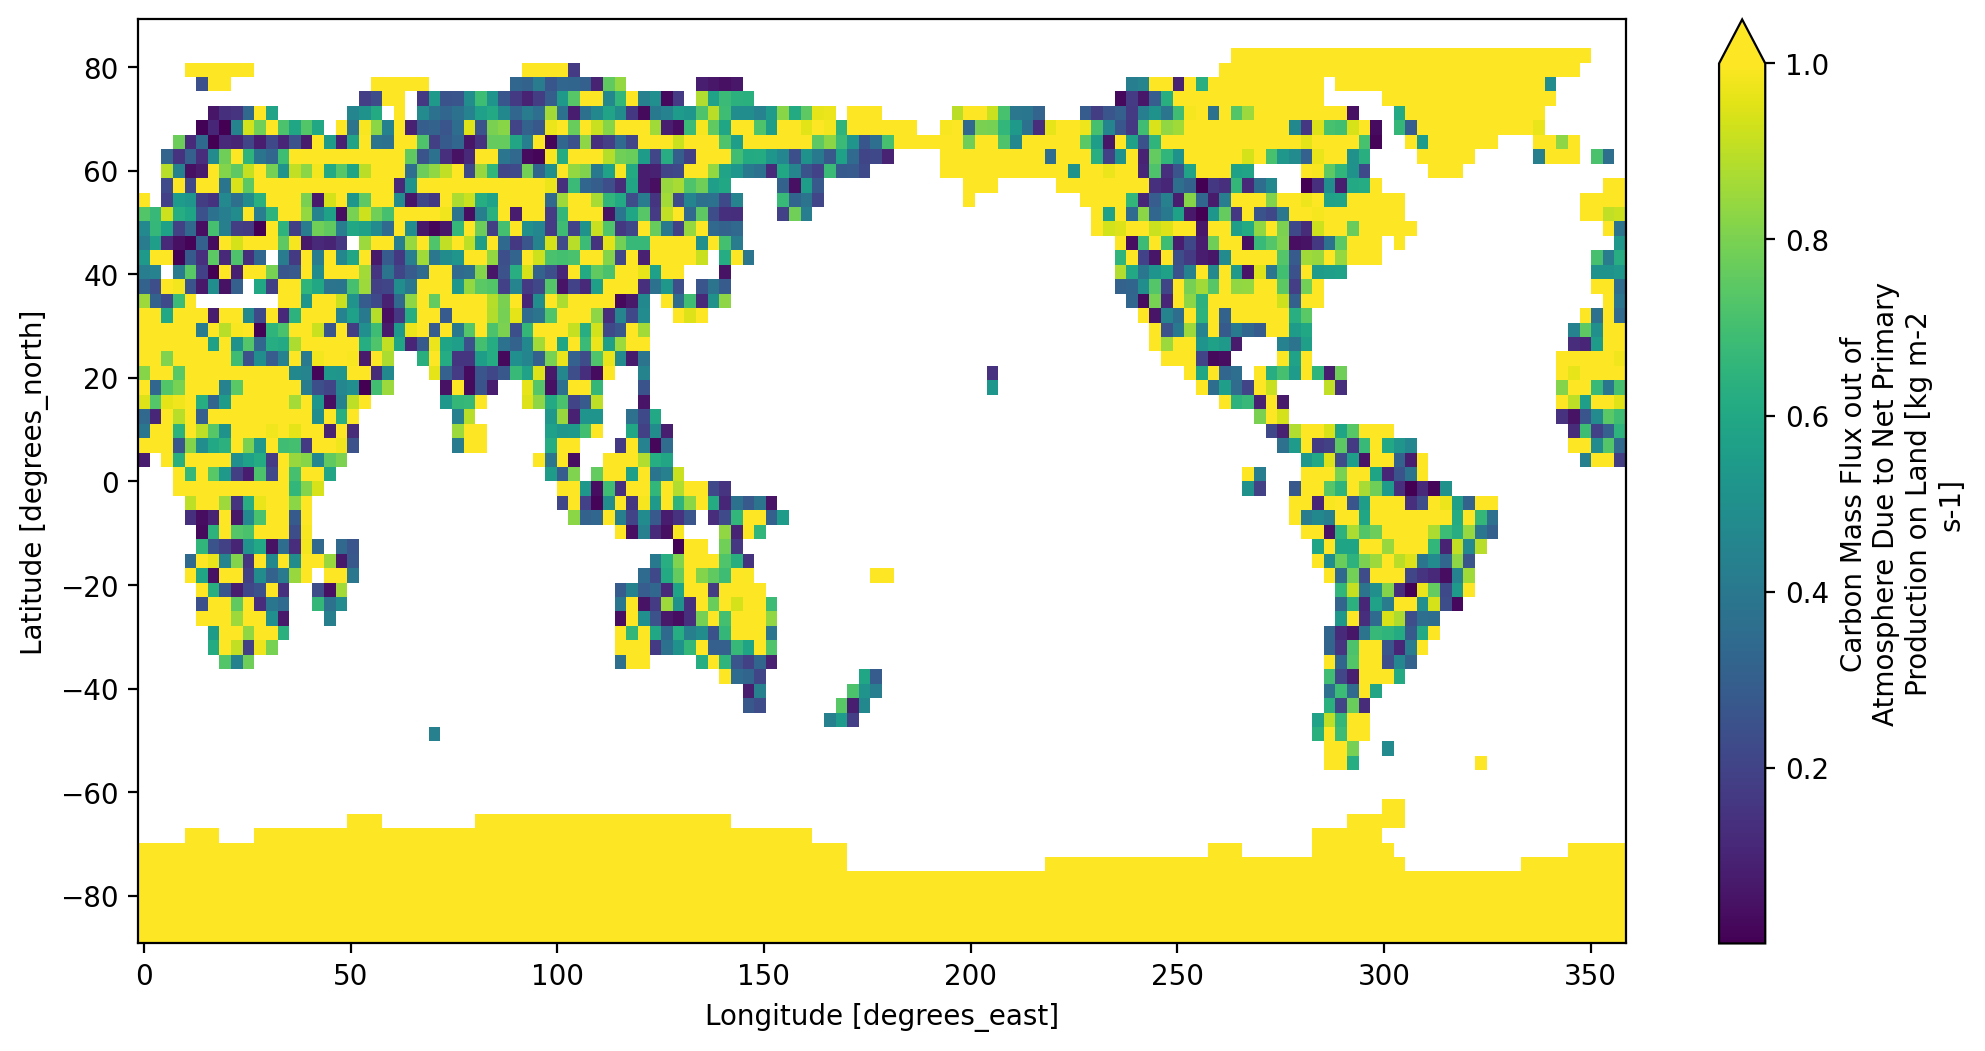

In [42]:
ct_bias.npp.plot(vmax = 1)

Improving over just using the historical pattern directly on 585.

# Ideal final test 

for every scenario with a specific bin (like 0.75 to 1.0 degC change),
learn the pattern for each scenario and for all the scenarios together.
Then evaluate all of the different patterns on the relevant range of global NPP

If the errors between each of those created maps are small, it means the pattern is
the same for each temperature bin regardless of SSP, and we can use the pattern on
all available data in that temperature bin.

Not going to do the full set of combinatons but going to load more data so can actually have examples of the same
0.25deg windows happening in multiple scenarios so we can more directly test the hypothesis.

further ideal:
- for ensemble avg for each ESMxScenario (do this by having all ensemble members in one matrix when doing the patternscaling )
- by GCAM region instead of gridded

In [43]:

# prep global temp for binning
gsat = pd.concat([pd.read_csv(DATA_DIR+"temp-data/cmip6_CMIP6_CMIP_CCCma_CanESM5_historical_r10i1p1f1_Amon_tas_gn_v20190429_temp.csv"),
                  pd.read_csv(DATA_DIR+"temp-data/cmip6_CMIP6_ScenarioMIP_CCCma_CanESM5_ssp126_r10i1p1f1_Amon_tas_gn_v20190429_temp.csv"),
                  pd.read_csv(DATA_DIR+"temp-data/cmip6_CMIP6_ScenarioMIP_CCCma_CanESM5_ssp245_r10i1p1f1_Amon_tas_gn_v20190429_temp.csv"),
                  pd.read_csv(DATA_DIR+"temp-data/cmip6_CMIP6_ScenarioMIP_CCCma_CanESM5_ssp585_r10i1p1f1_Amon_tas_gn_v20190429_temp.csv") ],
                  ignore_index=True
                )

gsat['value'] = gsat['value'] - 273.15


hist_avg = gsat[gsat['year'].between(1850, 1900)]['value'].mean()
gsat['value'] = gsat['value'] - hist_avg

gsat['smooth_value'] = gsat.groupby('experiment')['value'].rolling(window=13).mean().reset_index().drop(columns='level_1')['value']
# ^ binning on smooth data because less likelihood iav will cause years to go to the wrong bin + hector is smooth
gsat['smooth_value'] = gsat['smooth_value'].fillna(gsat['value']) # means front years aren't smoothed but better than NAs


# and bin 
binsize = 0.25
binedges = np.arange(-5, 10, binsize, )

gsat['group'] = pd.cut(gsat['smooth_value'], bins= binedges)

grouped_year_ranges = pd.DataFrame()    
for group_name, group_df in gsat.groupby(['group', 'experiment', 'ensemble', 'model']):
    #print(group_df)
    grouped_year_ranges = pd.concat([grouped_year_ranges,
                                     pd.DataFrame({
                                       'scenario': group_df['experiment'].unique(),  
                                       'ensemble': group_df['ensemble'].unique(), 
                                       'model': group_df['model'].unique(), 
                                       'start_yr': np.min(group_df['year']),
                                       'stop_yr': np.max(group_df['year']),
                                       'group': group_df['group'].unique()
                                     })],
                                     ignore_index=True)
# end for over groups in historical


grouped_year_ranges


,scenario,ensemble,model,start_yr,stop_yr,group
0,historical,r10i1p1f1,CanESM5,1850,1918,"(-0.25, 0.0]"
1,historical,r10i1p1f1,CanESM5,1856,1979,"(0.0, 0.25]"
2,historical,r10i1p1f1,CanESM5,1947,1996,"(0.25, 0.5]"
3,historical,r10i1p1f1,CanESM5,1997,2001,"(0.5, 0.75]"
4,historical,r10i1p1f1,CanESM5,2002,2005,"(0.75, 1.0]"
5,historical,r10i1p1f1,CanESM5,2006,2010,"(1.0, 1.25]"
6,historical,r10i1p1f1,CanESM5,2011,2014,"(1.25, 1.5]"
7,ssp126,r10i1p1f1,CanESM5,2023,2023,"(1.5, 1.75]"
8,ssp245,r10i1p1f1,CanESM5,2019,2019,"(1.5, 1.75]"
9,ssp585,r10i1p1f1,CanESM5,2015,2016,"(1.5, 1.75]"


Early on, the SSPs are all very similar and don't diverge til post 2050. Start Test on one of those later windows. 

```
27	ssp245	r10i1p1f1	CanESM5	2062	2069	(3.25, 3.5]
28	ssp585	r10i1p1f1	CanESM5	2050	2053	(3.25, 3.5]
29	ssp245	r10i1p1f1	CanESM5	2070	2076	(3.5, 3.75]
30	ssp585	r10i1p1f1	CanESM5	2054	2056	(3.5, 3.75]
31	ssp245	r10i1p1f1	CanESM5	2077	2083	(3.75, 4.0]
32	ssp585	r10i1p1f1	CanESM5	2057	2060	(3.75, 4.0]
```


/opt/miniconda3/envs/cmip6/lib/python3.14/site-packages/xarray/core/nputils.py:242: RuntimeWarning: Degrees of freedom <= 0 for slice.
  result = getattr(npmodule, name)(values, axis=axis, **kwargs)
/opt/miniconda3/envs/cmip6/lib/python3.14/site-packages/xarray/core/nputils.py:242: RuntimeWarning: Degrees of freedom <= 0 for slice.
  result = getattr(npmodule, name)(values, axis=axis, **kwargs)


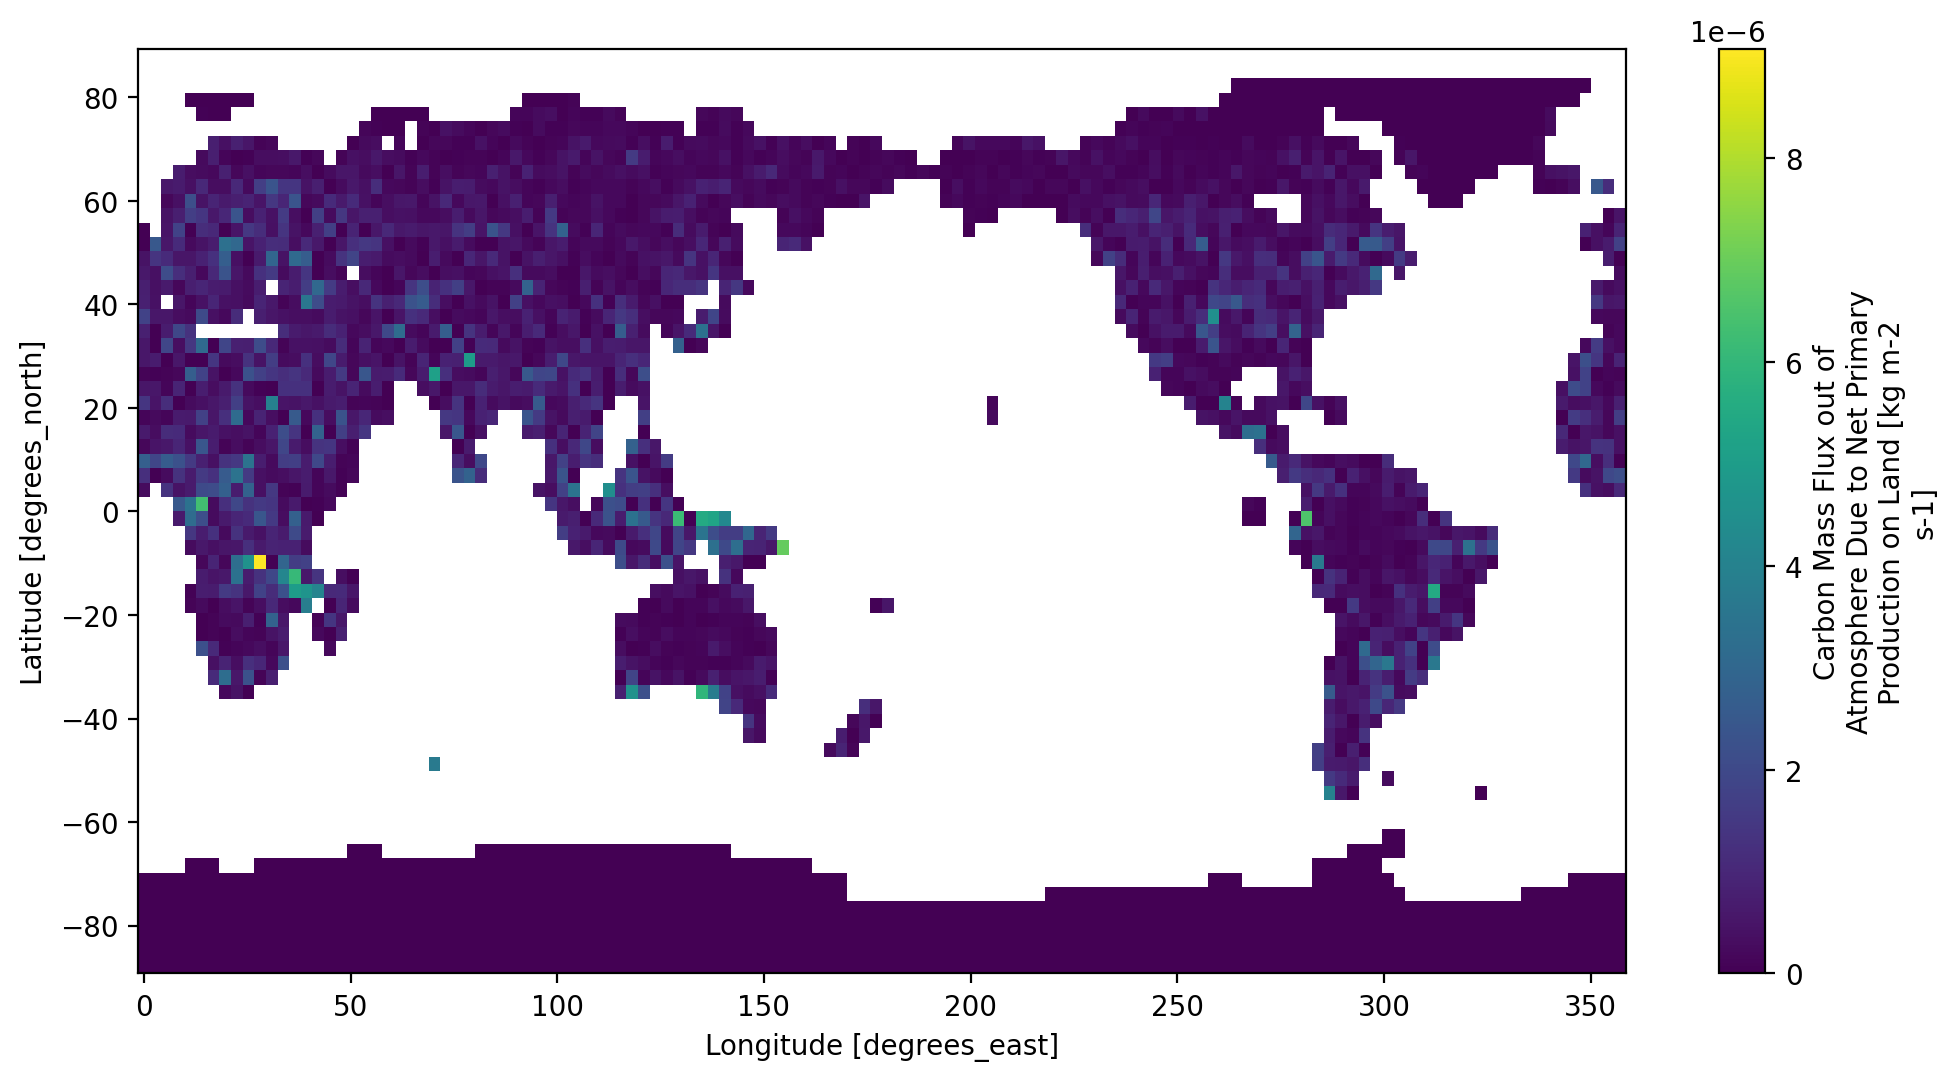

In [47]:
# train
tag = 'CanESM5_ssp245_r10i1p1f1n_npp_3p25to3p5'
field_ofile = DATA_DIR + "field/" + tag + "field.nc"
global_ofile = DATA_DIR + "global/" + tag + "global.nc"

d = xr.open_dataset(DATA_DIR+"raw-data/data/CCCma_CanESM5_ssp245_r10i1p1f1_Lmon_npp_gn_v20190429__npp.nc").sel(time= slice('2062','2069'))
cell_area = xr.open_dataset(DATA_DIR+"raw-data/areacella/CCCma_CanESM5_historical_r10i1p1f1_Lmon_npp_gn_v20190429_.nc")
land_percent = xr.open_dataset(DATA_DIR+"raw-data/sftlf/CCCma_CanESM5_historical_r10i1p1f1_Lmon_npp_gn_v20190429_.nc")

# Save meta data information
VAR = d.variable_id
all_attrs = d.attrs
original_units = d[VAR].units
keys_to_keep = ["variable_id", "variant_label", "experiment_id", "frequency", "grid_label", "source_id"]
meta_data = {k: all_attrs[k] for k in keys_to_keep if k in all_attrs}

# The first thing we need to do is get the annual field which should be total
# carbon content per year.
# TODO right now we are assuming a 365 day calander across models we may want to update this.
seconds_per_year = (365 * 24 * 60 * 60) / 12
annual_monthly_rate = d.coarsen(time=12).sum() * seconds_per_year

 # Calculate the land cell area, make sure that the land cell area where
# land is 0 assign it a na value so that
land_cell_area = cell_area.areacella * land_percent.sftlf * (1 / 100)
land_cell_area = land_cell_area.where(land_cell_area != 0, other=np.nan)

# Calculate the total annual carbon. Update attributes to reflect the
# new units.
# TODO figure out a way to add the attribtue information!
field = annual_monthly_rate * land_cell_area.values




# Convert from kg of C to the Petagram of C which are the
# unites I am used to thinking in/hector units.
field = field * 1e-12
#np.nanmax(field.npp.values)

# annual_total_carbon = annual_total_carbon.assign_attrs()
# meta_data["frequency"] = "yr"
# meta_data["units"] = original_units.replace(" m-2 s-1", "")
# for k, v in meta_data.items():
#    annual_total_carbon.attrs[f"{k}"] = str(v)
field.attrs["frequency"] = "year"
field.attrs["units"] = "Pg C"
field.to_netcdf(field_ofile, mode="w")

# The global values, for the carbon values this is going to be
# the global total, since we have already multiplied by the
# land area we do not need to do the weighting.
other_dims = set(field.dims) - {"time"} # define that will sum over every dim except time
global_ts = field.sum(other_dims, skipna=True)
global_ts.to_netcdf(global_ofile, mode='w')

# Linear Pattern Scaling Portion
# The times should align since we are originating from the same raw netcdf file
# although this is an assumption TODO don't rely on assumptions.
field_with_global = field.copy()
field_with_global["time"] = global_ts[VAR]
field_with_global = field_with_global.rename({VAR: "field"})

# Use the field with global time series to do the regression.
# Save the results.
reg = field_with_global.polyfit(dim="time", deg=1)

beta = reg.field_polyfit_coefficients.sel(degree=1)
intercept = reg.field_polyfit_coefficients.sel(degree=0)

beta.to_netcdf(DATA_DIR + "beta/" + tag + "beta.nc", mode='w')
intercept.to_netcdf(DATA_DIR + "intercept/" + tag + "intercept.nc", mode='w')

# Beyond here are extra QAQC steps that will not be part of the formal pipeline.
# Pattern-scaled reconstruction
yhat = beta * global_ts + intercept
yhat = yhat.transpose(*("lat", "lon", "time"))
yhat.to_netcdf(DATA_DIR + "yhat/" + tag + "yhat.nc", mode='w')

# Error metrics for quailty checks, these are going to tbe the most standardized versions.
# TODO this following chunk is part of the QAQC and will probably be removed from the formal pipeline
# TODO might want to consider masking out the 0s so that we don't run into issues with NAs, although
# that might be overkil...

# These are all our "insample" error metrics
var_obs = field.var(dim="time")
sd_obs = var_obs ** 0.5
sd_sim = yhat.var(dim="time") ** 0.5
mean_obs = field.mean(dim="time")
mean_sim = yhat.mean(dim="time")

resid = yhat - field
mse = (resid * resid).mean(dim="time")
ns = mse / var_obs
ct_bias = abs(mean_obs - mean_sim) / sd_obs
ct_var = sd_sim / sd_obs

resid.to_netcdf(DATA_DIR + "error_metrics/" + tag + "resid.nc", mode='w')
mse.to_netcdf(DATA_DIR + "error_metrics/" + tag + "mse.nc", mode='w')
ns.to_netcdf(DATA_DIR + "error_metrics/" + tag + "ns.nc", mode='w')
ct_bias.to_netcdf(DATA_DIR + "error_metrics/" + tag + "ctbias.nc", mode='w')
ct_var.to_netcdf(DATA_DIR + "error_metrics/" + tag + "ctvar.nc", mode='w')

ct_bias.npp.plot()

/opt/miniconda3/envs/cmip6/lib/python3.14/site-packages/xarray/core/nputils.py:242: RuntimeWarning: Degrees of freedom <= 0 for slice.
  result = getattr(npmodule, name)(values, axis=axis, **kwargs)
/opt/miniconda3/envs/cmip6/lib/python3.14/site-packages/xarray/core/nputils.py:242: RuntimeWarning: Degrees of freedom <= 0 for slice.
  result = getattr(npmodule, name)(values, axis=axis, **kwargs)


FileNotFoundError: [Errno 2] No such file or directory: 'figs/CT_bias_ssp585_2050to2053.png'

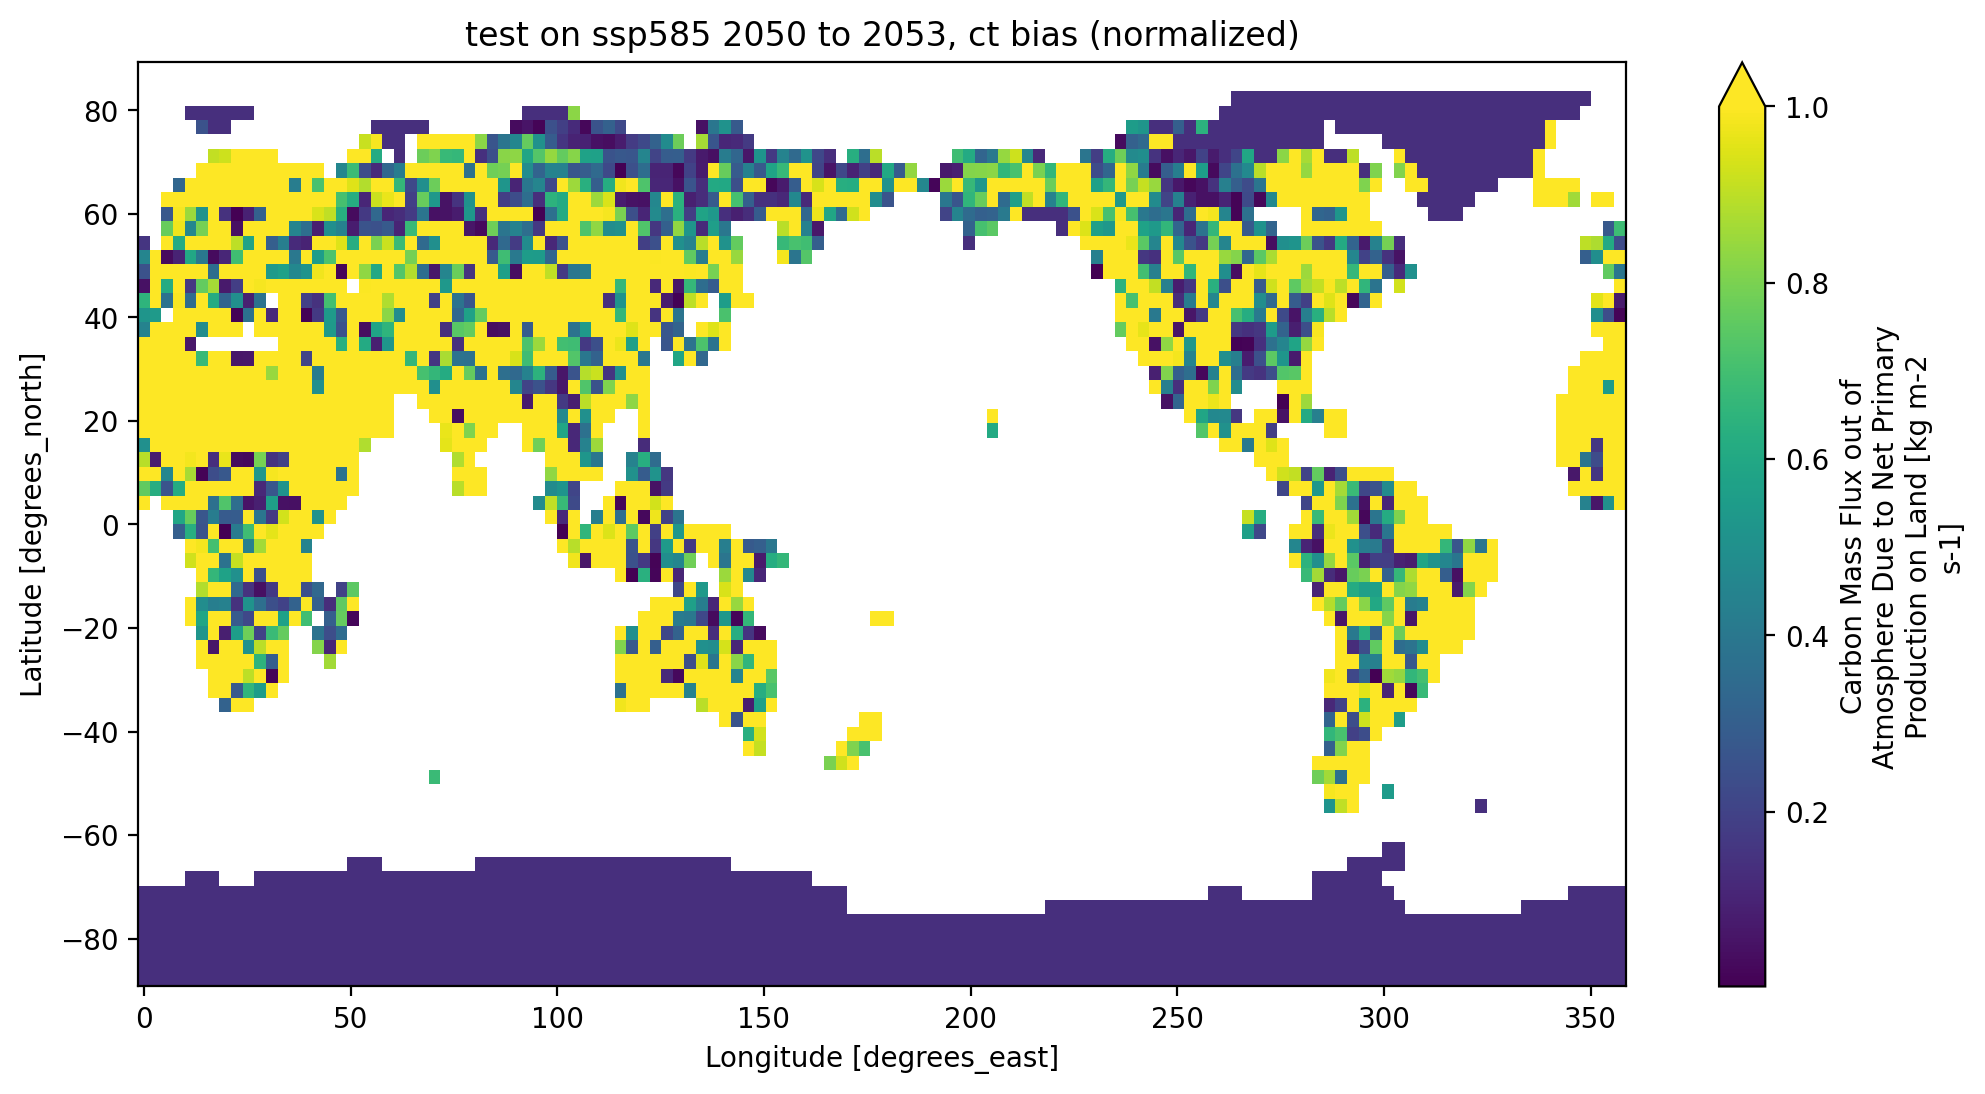

In [49]:
# evaluate on ssp585

# load and prep comparison data
d = xr.open_dataset(DATA_DIR+"raw-data/data/CCCma_CanESM5_ssp585_r10i1p1f1_Lmon_npp_gn_v20190429_.nc").sel(time= slice('2050','2053'))
cell_area = xr.open_dataset("data/raw-data/areacella/CCCma_CanESM5_ssp585_r10i1p1f1_Lmon_npp_gn_v20190429_.nc")
land_percent = xr.open_dataset(DATA_DIR+"raw-data/sftlf/CCCma_CanESM5_ssp585_r10i1p1f1_Lmon_npp_gn_v20190429_.nc")    
# Save meta data information
VAR = d.variable_id
all_attrs = d.attrs
original_units = d[VAR].units
keys_to_keep = ["variable_id", "variant_label", "experiment_id", "frequency", "grid_label", "source_id"]
meta_data = {k: all_attrs[k] for k in keys_to_keep if k in all_attrs}
# The first thing we need to do is get the annual field which should be total
# carbon content per year.
# TODO right now we are assuming a 365 day calander across models we may want to update this.
seconds_per_year = (365 * 24 * 60 * 60) / 12
annual_monthly_rate = d.coarsen(time=12).sum() * seconds_per_year
 # Calculate the land cell area, make sure that the land cell area where
# land is 0 assign it a na value so that
land_cell_area = cell_area.areacella * land_percent.sftlf * (1 / 100)
land_cell_area = land_cell_area.where(land_cell_area != 0, other=np.nan)
# Calculate the total annual carbon. Update attributes to reflect the
# new units.
# TODO figure out a way to add the attribtue information!
field_fut = annual_monthly_rate * land_cell_area.values
# Convert from kg of C to the Petagram of C which are the
# unites I am used to thinking in/hector units.
field_fut = field_fut * 1e-12
# annual_total_carbon = annual_total_carbon.assign_attrs()
# meta_data["frequency"] = "yr"
# meta_data["units"] = original_units.replace(" m-2 s-1", "")
# for k, v in meta_data.items():
#    annual_total_carbon.attrs[f"{k}"] = str(v)
field_fut.attrs["frequency"] = "year"
field_fut.attrs["units"] = "Pg C"



# The global values, for the carbon values this is going to be
# the global total, since we have already multiplied by the
# land area we do not need to do the weighting.
other_dims = set(field_fut.dims) - {"time"} # define that will sum over every dim except time
global_ts_fut = field_fut.sum(other_dims, skipna=True)

# estimate field and compare to truth
yhat_fut = beta * global_ts_fut + intercept
yhat_fut = yhat_fut.transpose(*("lat", "lon", "time")).copy()

# errors
var_obs = field_fut.var(dim="time")
sd_obs = var_obs ** 0.5
sd_sim = yhat_fut.var(dim="time") ** 0.5
mean_obs = field_fut.mean(dim="time")
mean_sim = yhat_fut.mean(dim="time")

resid = yhat_fut - field_fut
mse = (resid * resid).mean(dim="time")
ns = (mse / var_obs) ** 0.5
ct_bias = abs(mean_obs - mean_sim) / sd_obs
ct_var = sd_sim / sd_obs

bias = abs(mean_obs - mean_sim)

ct_bias.npp.plot(vmax = 1)
plt.title('test on ssp585 2050 to 2053, ct bias (normalized)')

# Save the plot to a file
plt.savefig("figs/CT_bias_ssp585_2050to2053.png", dpi=300, bbox_inches="tight")
plt.show()
# Clear the figure
plt.close()


bias.npp.plot()
plt.title('test on ssp585 2050 to 2053,  bias (unnormalized)')

# Save the plot to a file
plt.savefig("figs/bias_ssp585_2050to2053.png", dpi=300, bbox_inches="tight")
plt.show()
# Clear the figure
plt.close()


So the actual years it should be (2050-2053) doesn't perform great because it's so few years in both training and testing. Expected and won't be an issue with more realizations + patterns learned on same temp bin from all scenarios.
-> normalized metrics aren't great when only looking at a few years because the SD in the denominator kind of meaningless

- wish I had realized up above when looking at half deg bin pattern applied to next half degree


2047-2056 is better on CT bias because still close to correct bin but more years for more stable SD

2045-2060 gets worse again because covering too great a range of temperatures

Also want to check mask to see where need to actually care.

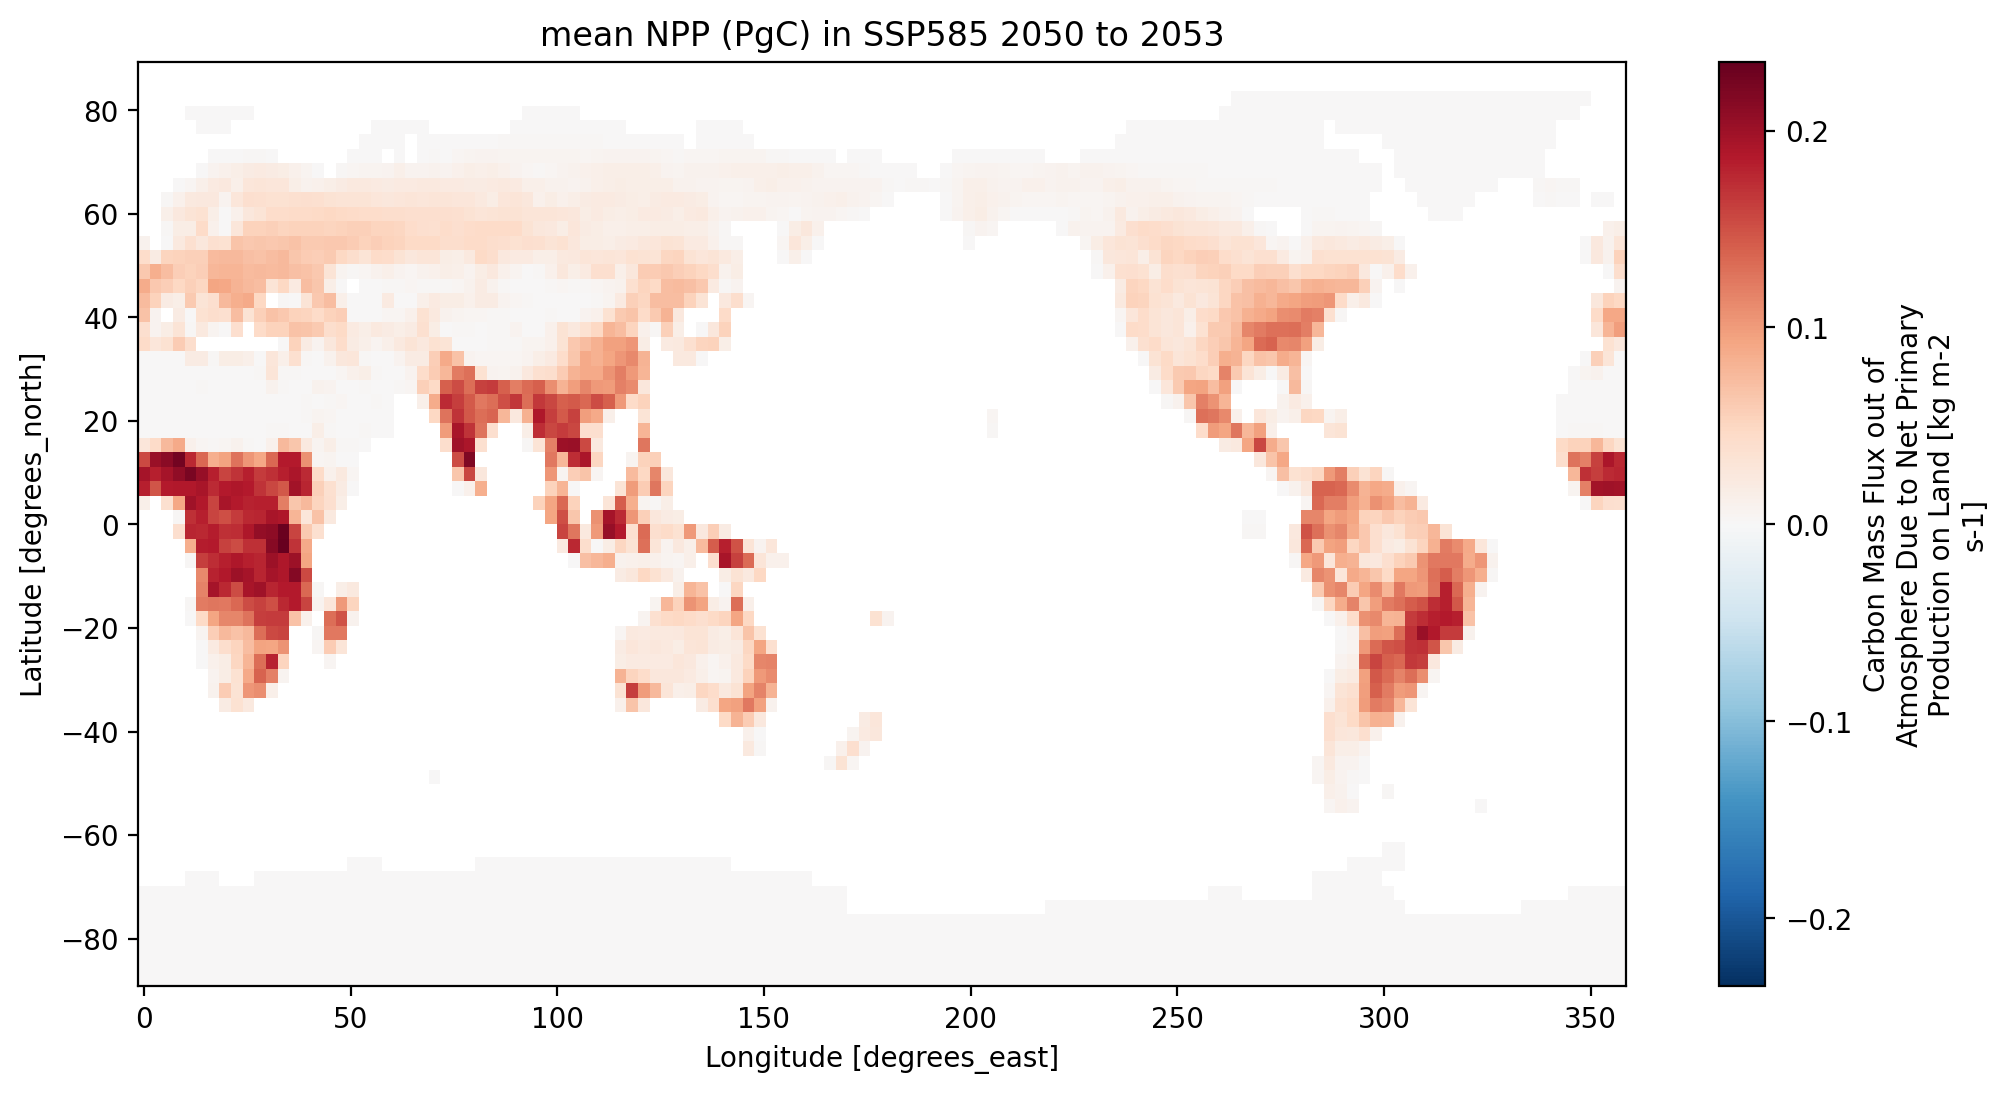

In [51]:
field_fut.npp.mean(dim = 'time').plot()
plt.title('mean NPP (PgC) in SSP585 2050 to 2053')
# Save the plot to a file
plt.savefig("figs/ssp585_2050to2053_meanNPP.png", dpi=300, bbox_inches="tight")
plt.show()
# Clear the figure
plt.close()

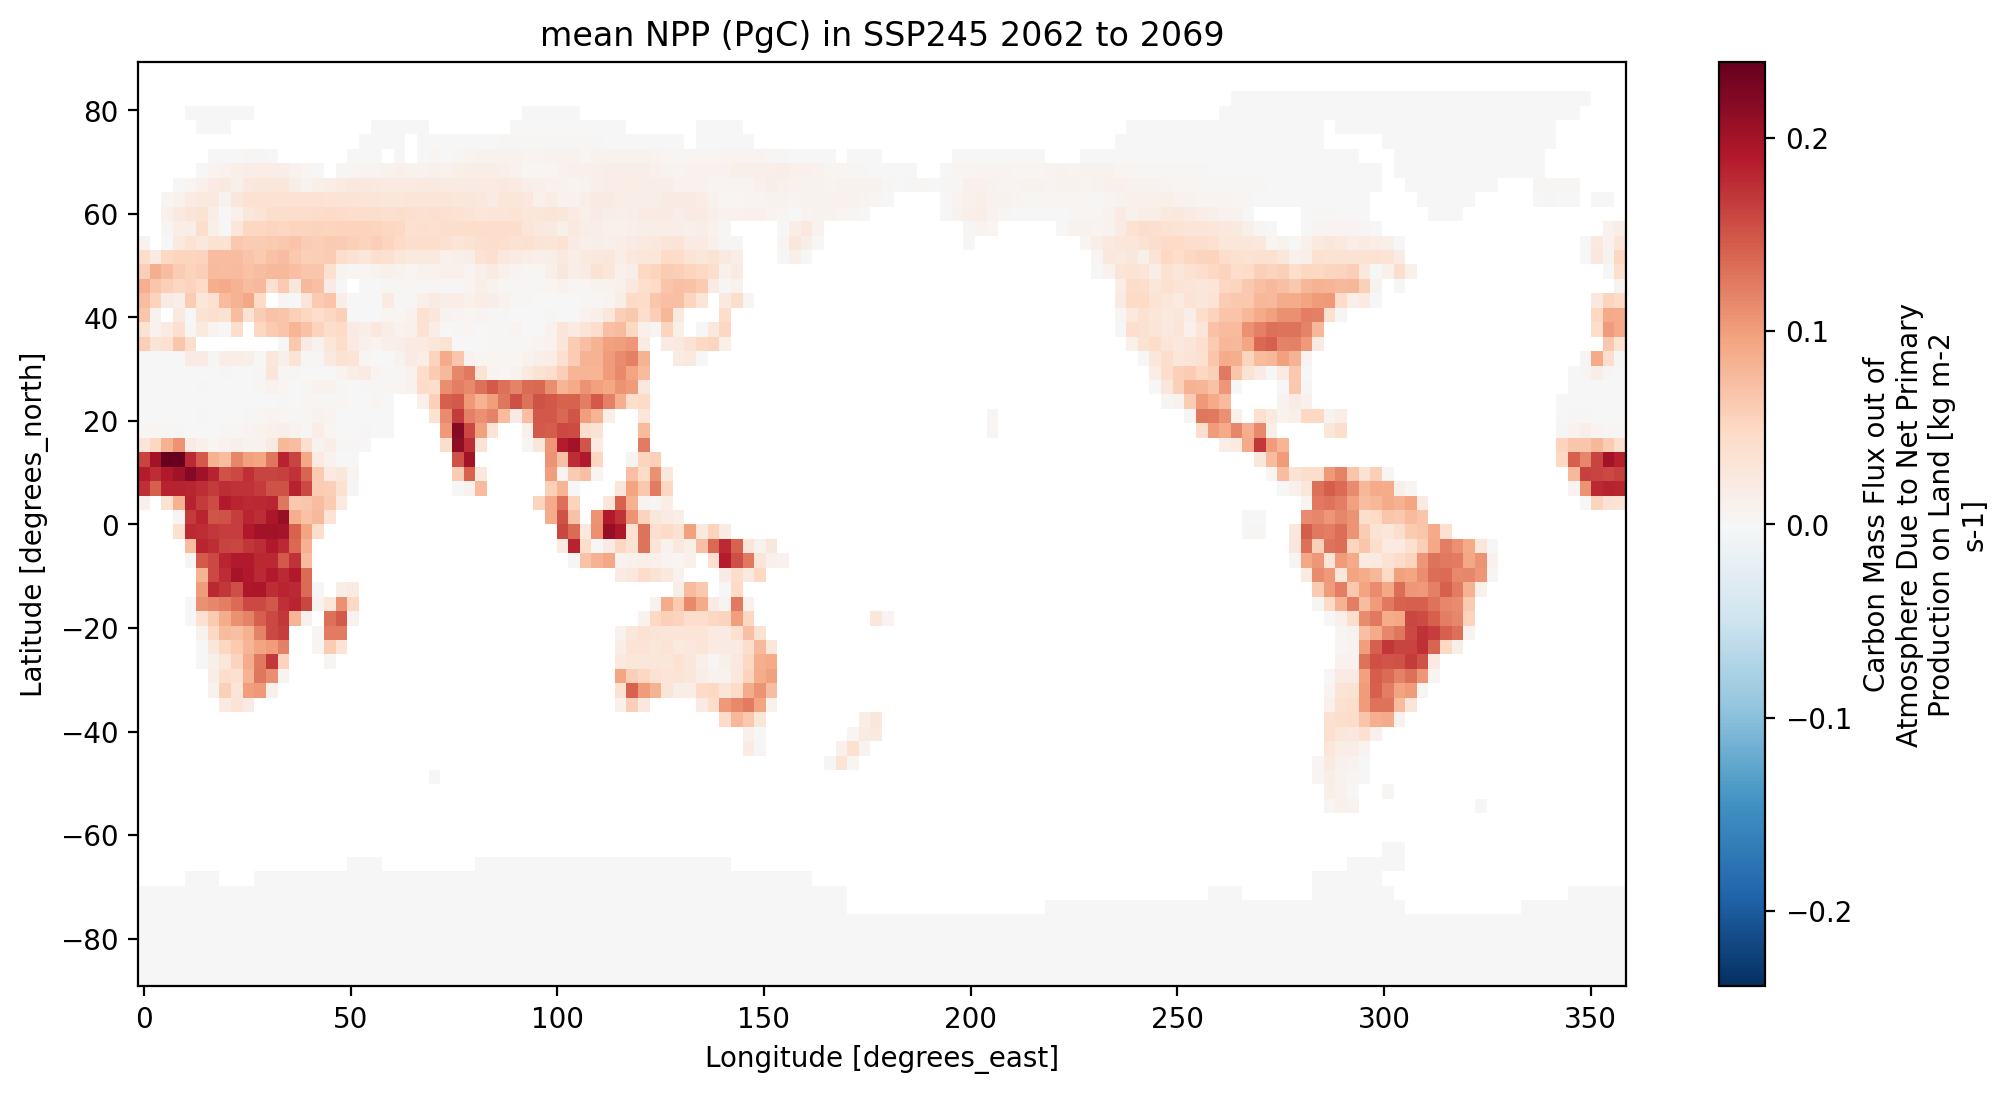

In [52]:
field.npp.mean(dim = 'time').plot()
plt.title('mean NPP (PgC) in SSP245 2062 to 2069')
# Save the plot to a file
plt.savefig("figs/ssp245_2062to2069_meanNPP.png", dpi=300, bbox_inches="tight")
plt.show()
# Clear the figure
plt.close()


Text(0.5, 1.0, 'Difference in NPP between SSP245 0.25deg bin avg and SSP585 (PgC)')

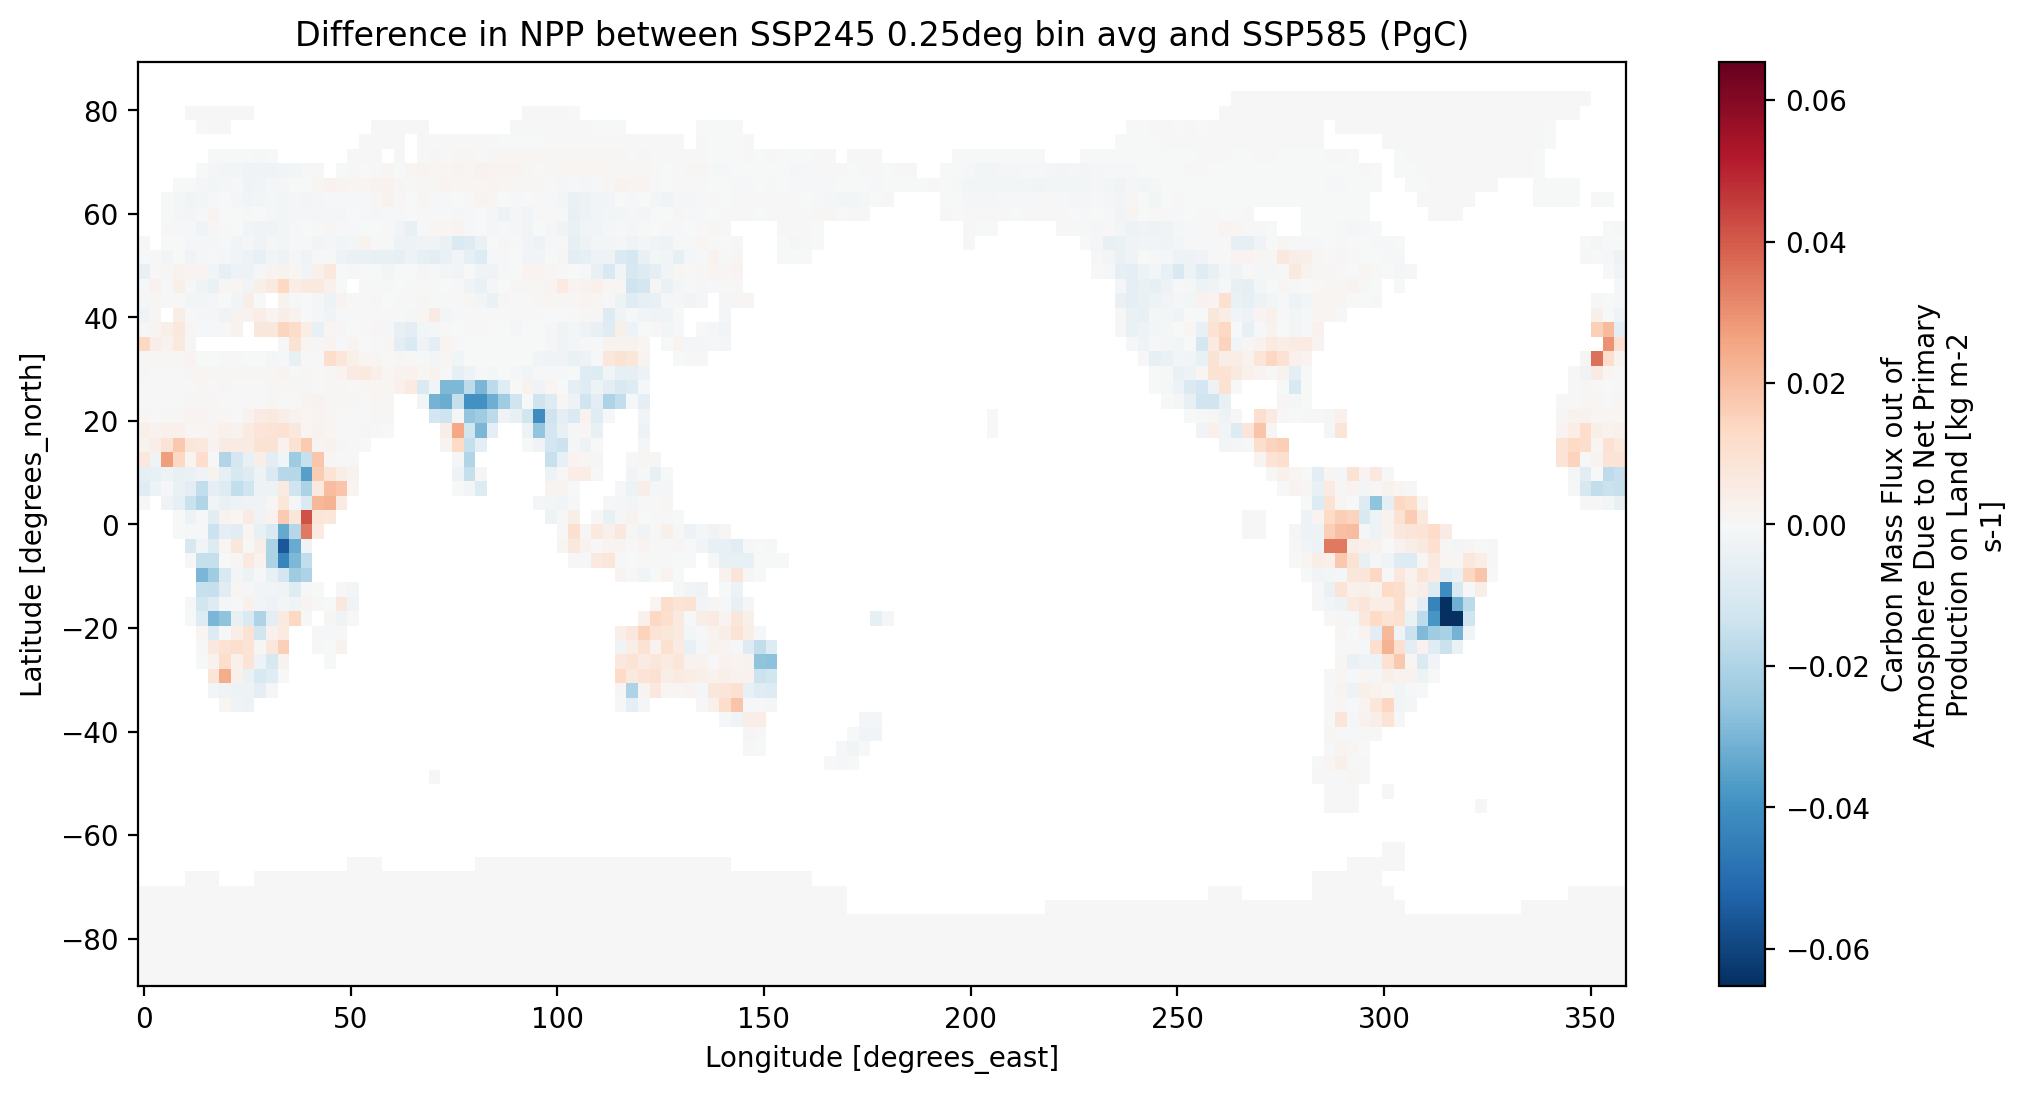

In [53]:
x = field.npp.mean(dim = 'time')-field_fut.npp.mean(dim = 'time')
x.plot()
plt.title('Difference in NPP between SSP245 0.25deg bin avg and SSP585 (PgC)')

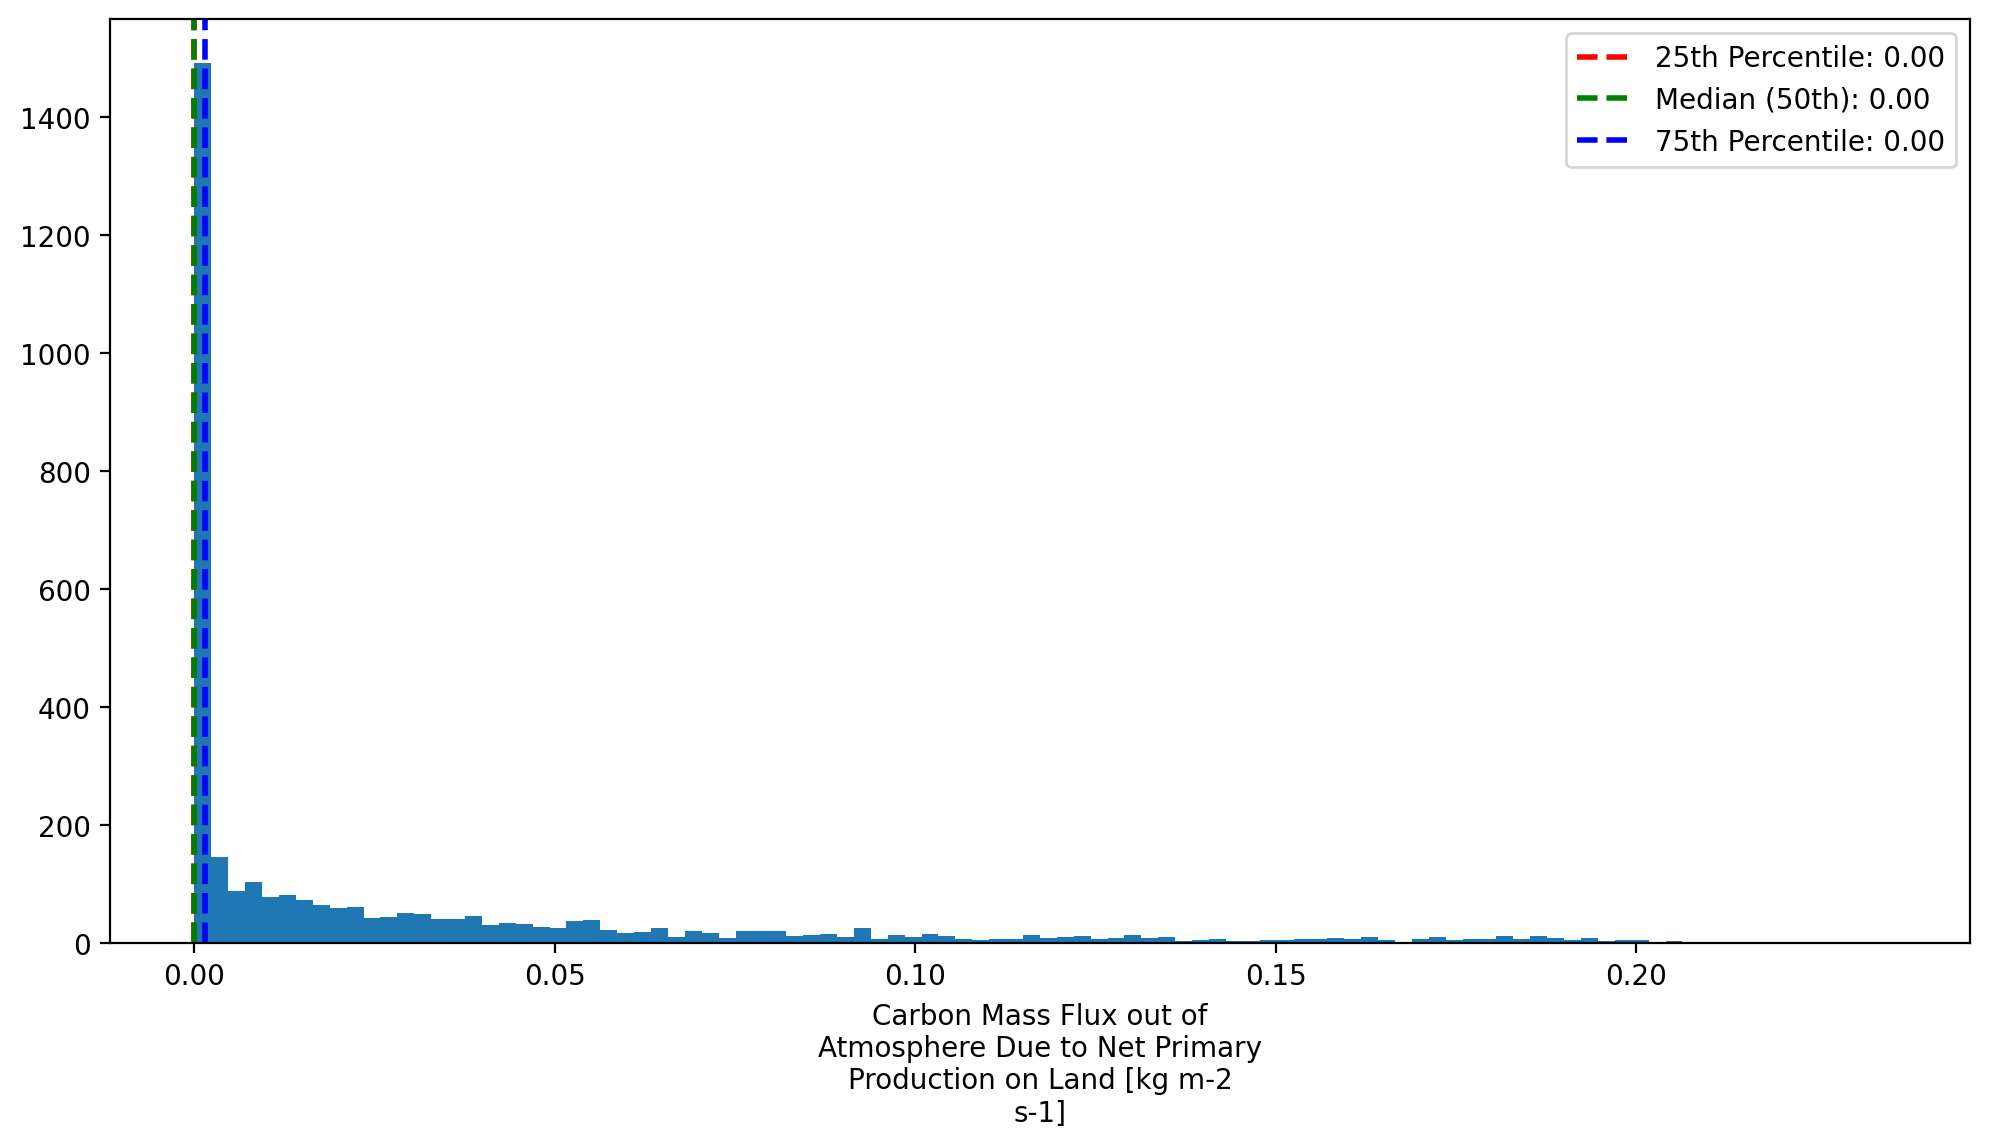

array([0.        , 0.        , 0.00147184])

In [54]:
quantiles = np.percentile(field_fut.npp.fillna(0).mean(dim='time'), [25, 50, 75])
# 4. Add vertical lines for each quantile
colors = ['red', 'green', 'blue']
labels = ['25th Percentile', 'Median (50th)', '75th Percentile']



field_fut.npp.mean(dim = 'time').plot.hist(bins=100)
# Add vertical quantile lines
for q, color, label in zip(quantiles, colors, labels):
    plt.axvline(x=q, color=color, linestyle='--', linewidth=2, label=f'{label}: {q:.2f}')
plt.legend()
plt.show()

quantiles

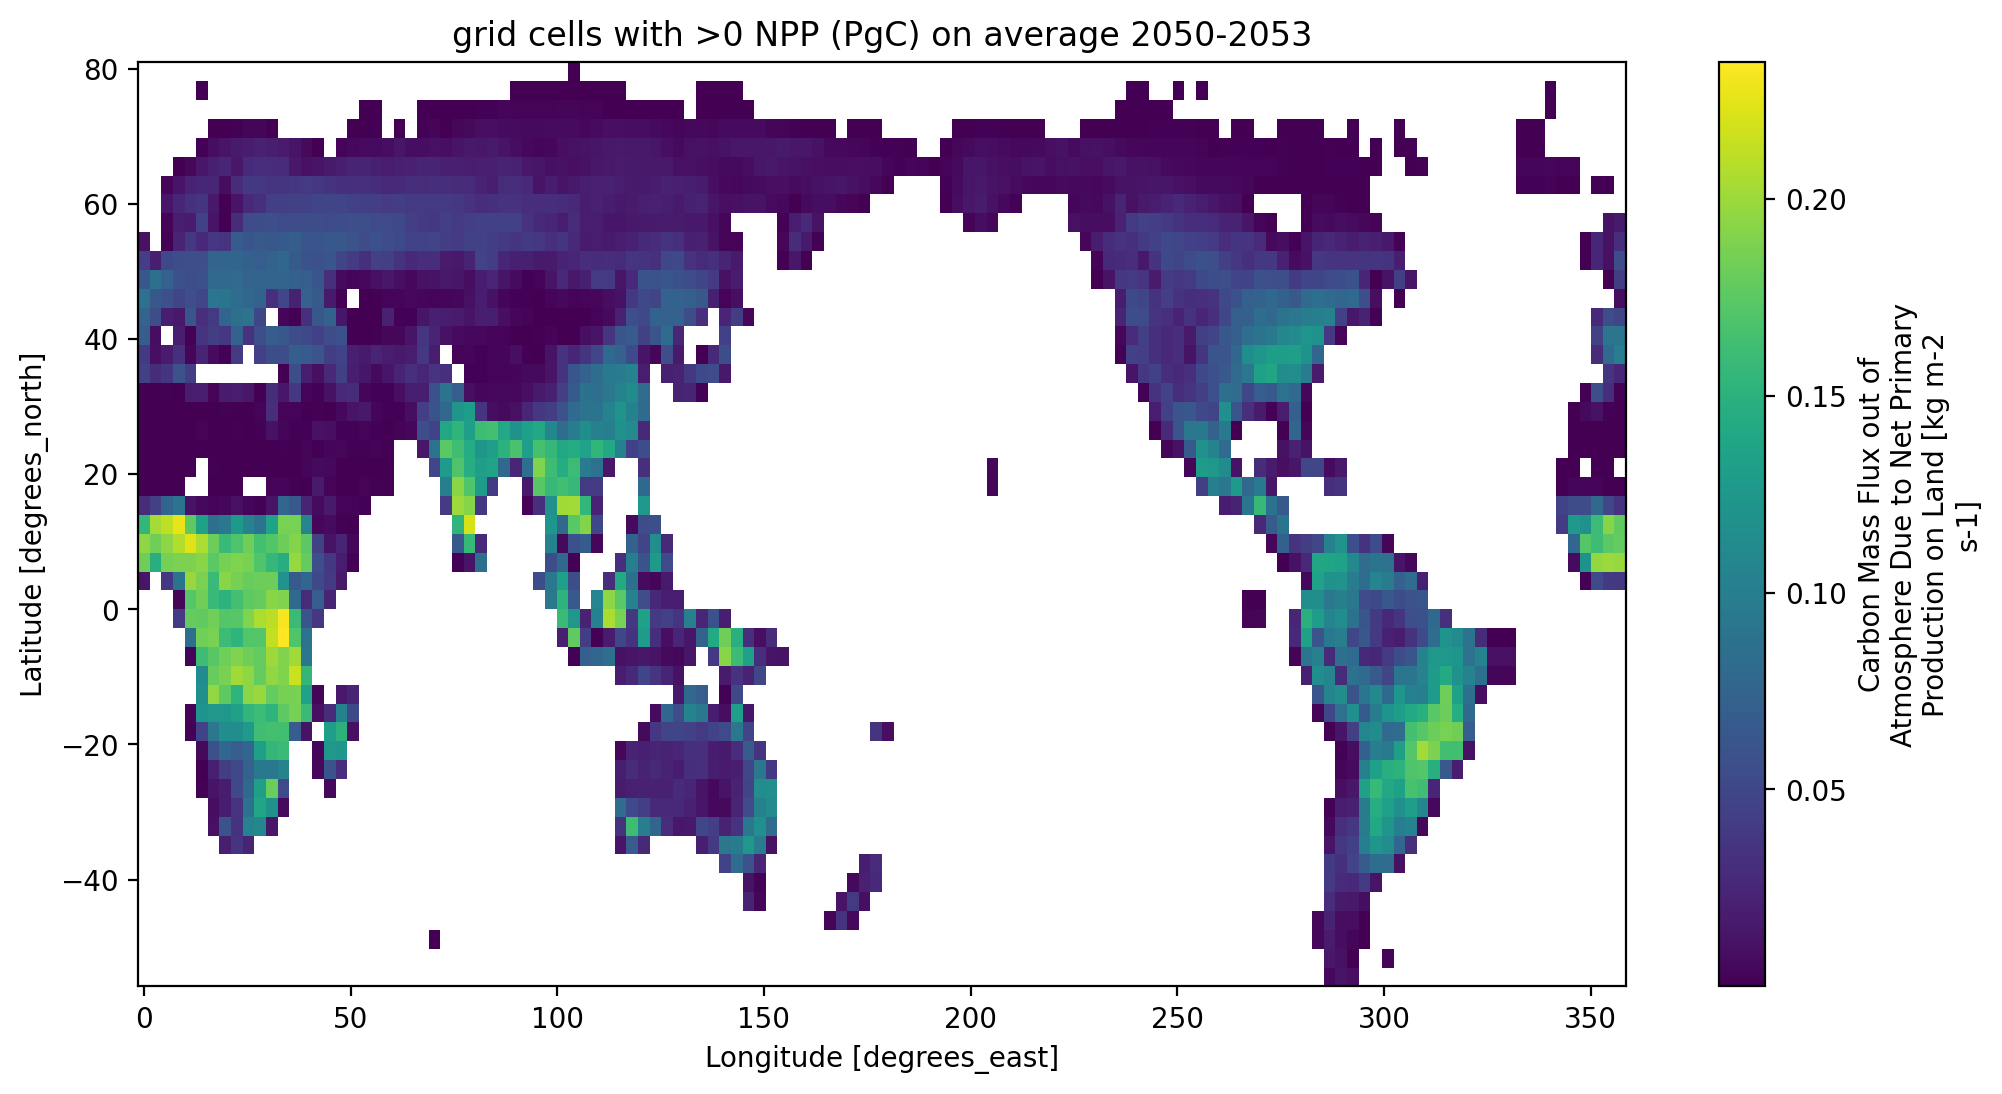

In [74]:
field_fut.npp.mean(dim='time').where(field_fut.npp.mean(dim='time')>0, drop =True).plot()
plt.title("grid cells with >0 NPP (PgC) on average 2050-2053")
plt.show()
#plt.savefig("figs/ssp245_2062to2069_meanNPP.png", dpi=300, bbox_inches="tight")



Text(0.5, 1.0, 'Bias in applying ssp245 pattern in .25deg bin (2062 to 2069) to SSP585 (2050 to 2053) (PgC)')

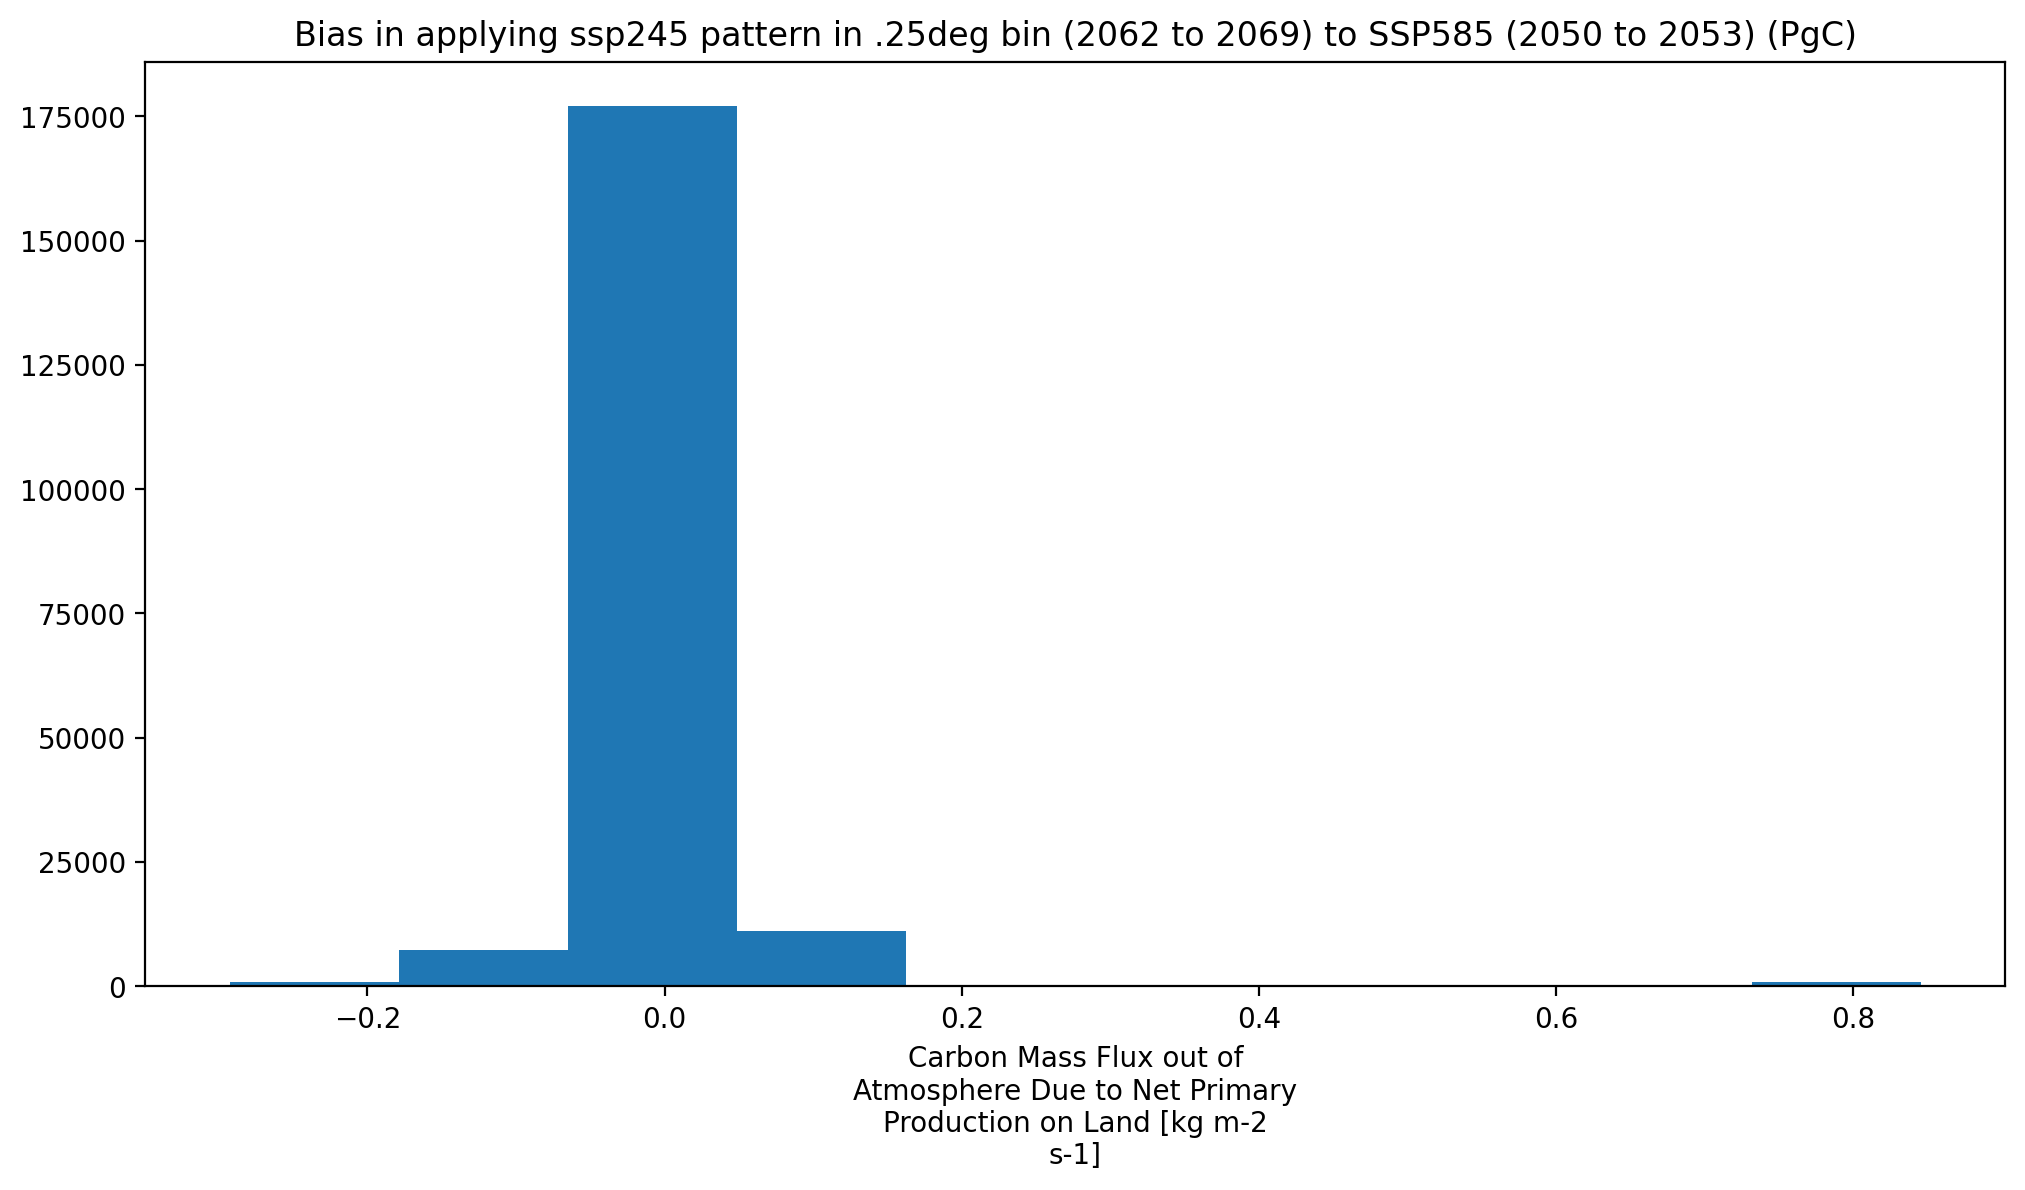

In [86]:
field_fut.npp.mean(dim='time')

filtered_ctbias = ct_bias.where(field_fut.npp.mean(dim='time')>0, drop =True)

bias.where(field_fut.npp.mean(dim='time')>0, drop =True).npp.plot()
plt.title('Bias in applying ssp245 pattern in .25deg bin (2062 to 2069) to SSP585 (2050 to 2053) (PgC)')

#plt.savefig("figs/ssp245_2062to2069_meanNPP.png", dpi=300, bbox_inches="tight")



Places where it is worst are also places with highest NPP. look at the bias/avg NPP especially in those places

In [87]:
bias.where(field_fut.npp.mean(dim='time')>0, drop =True).npp

top15grids =field_fut.npp.mean(dim='time').stack(cell=('lon', 'lat')).to_series().nlargest(15).reset_index()

top15grids['max_bias/mean_npp'] = 0.065 / top15grids['npp']

top15grids

,lon,lat,npp,max_bias/mean_npp
0,33.7500,-4.185921,0.234557,0.277118
1,33.7500,-1.395307,0.231752,0.280472
2,8.4375,12.557756,0.225829,0.287828
3,11.2500,9.767146,0.223401,0.290956
4,78.7500,12.557756,0.219802,0.295720
5,36.5625,-9.767146,0.215724,0.301312
6,30.9375,-4.185921,0.212708,0.305584
7,5.6250,12.557756,0.210795,0.308356
8,30.9375,-1.395307,0.210724,0.308460
9,8.4375,9.767146,0.207089,0.313875


AttributeError: Rectangle.set() got an unexpected keyword argument 'vmax'

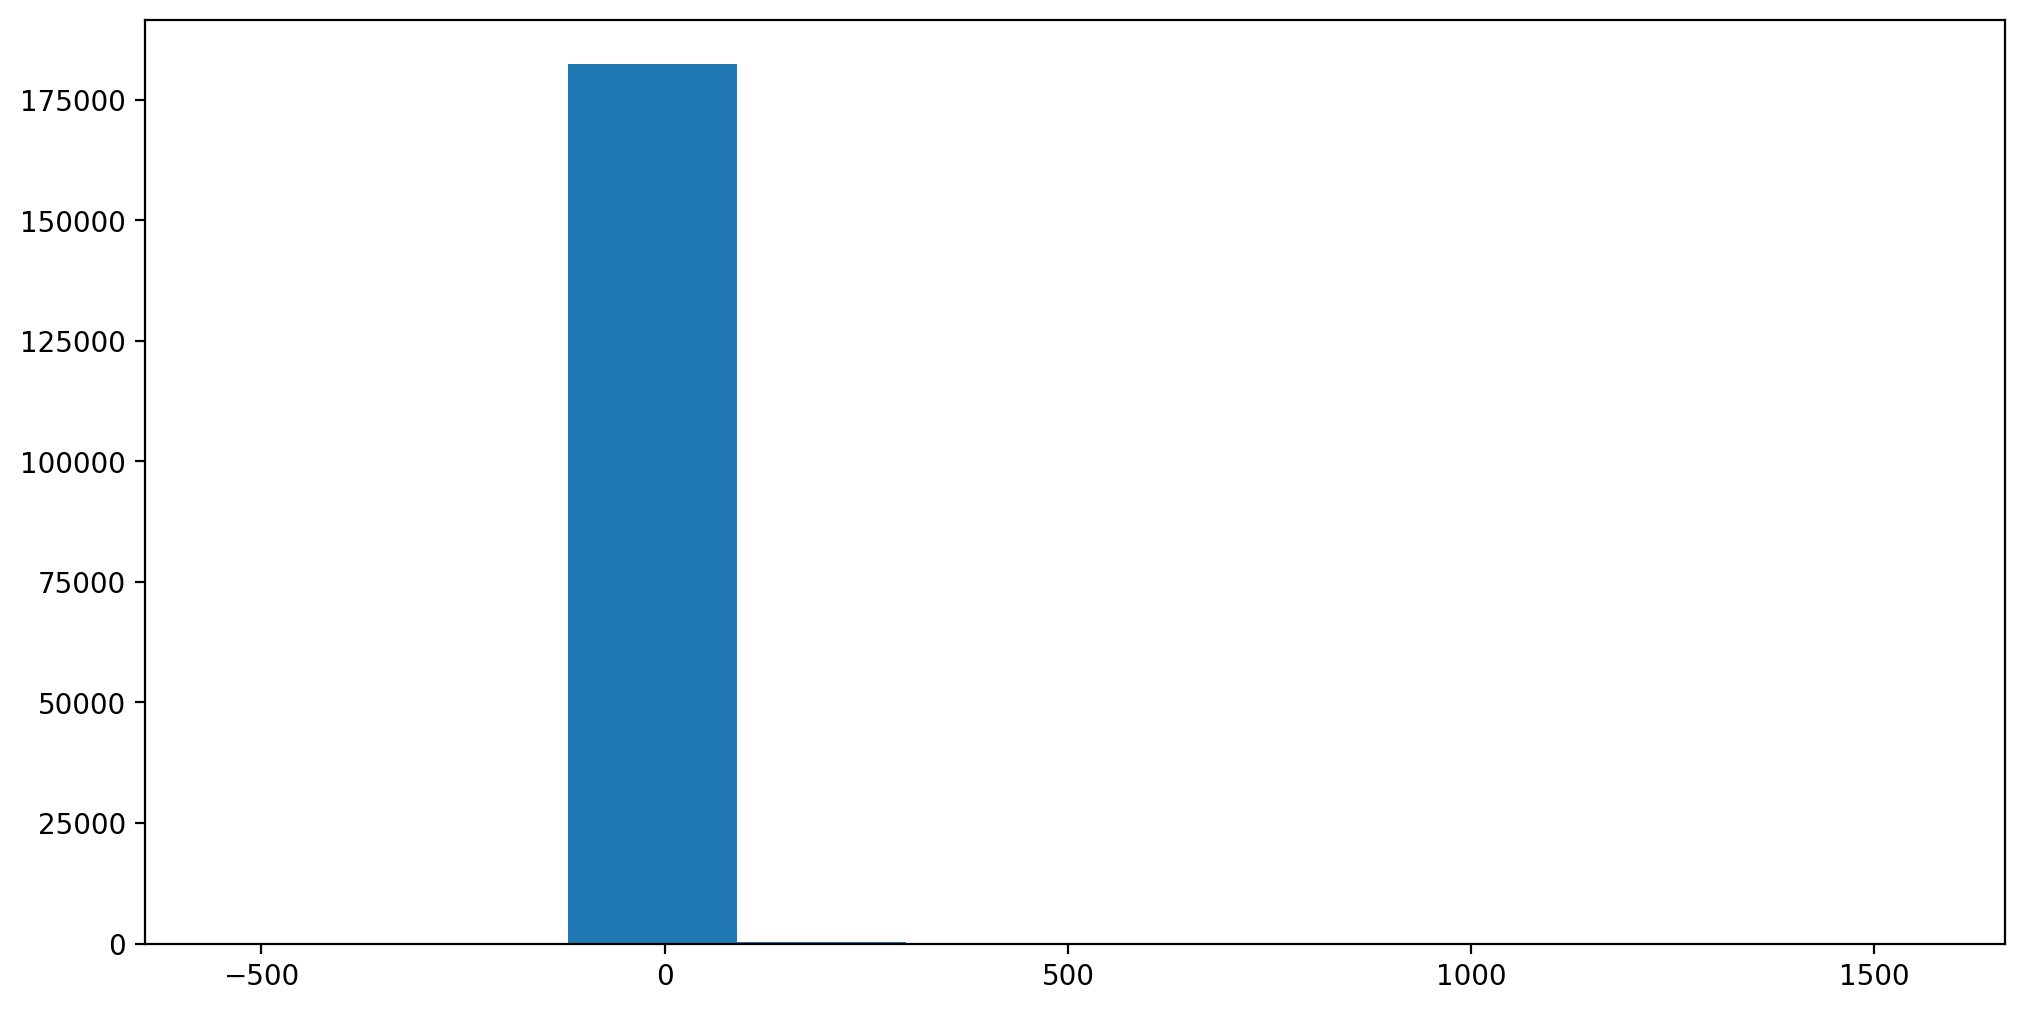

In [88]:
weighted_bias = bias.where(field_fut.npp.mean(dim='time')>0.0005, drop =True).npp / field_fut.npp.mean(dim='time')

weighted_bias.plot(vmax = 0.5)
#plt.title('Bias in applying ssp245 pattern in .25deg bin (2062 to 2069) to SSP585 (2050 to 2053) (PgC)')

Max grid cell error is 27.7% of the avg NPP in that cell, occuring in our most important grid cells. 27.7% still not great. 

 But a lot better than just applying the wrong pattern to the entire time series, where the biggest producing grid cells (highest avg NPP 2015-2100), had bias 100% their NPP.
 
 Hopefully even better at GCAM land unit scale? also could work with smaller temperature bins 

 # GCAM regions?

 - do 32 regions for now because dont have boundary issues with CanESM grids being big. 

 - error on GCAM land units will be between grid and 32 region errors. 


 Because everything is linear, doing the aggregation of NPP before vs after pattern scaling doesn't matter. Have the patterns already
 loaded up so we'll aggregate both the real and created SSP585 values to the region level for this temperature bin, then repeat errors on that. 

In [89]:
# load up the shape files
import geopandas as gpd
import rioxarray as rxr

#shp = gpd.read_file("reg_glu_boundaries_moirai_combined_3p1_0p5arcmin.shp") # https://zenodo.org/records/4688451
#shp['single_id'] = shp['reg_nm'] + '~' + shp['glu_nm']


# for 32 regions only:
shp = gpd.read_file("region_boundaries_moirai_combined_3p1_0p5arcmin.shp") # https://zenodo.org/records/4688451
shp['single_id'] = shp['reg_nm']

shp

,key,reg_id,reg_nm,geometry,single_id
0,1,1,USA,"MULTIPOLYGON (((-64.91667 17.83333, -64.66667 ...",USA
1,2,2,Africa_Eastern,"MULTIPOLYGON (((63.33333 -19.58333, 63.5 -19.5...",Africa_Eastern
2,3,3,Africa_Northern,"MULTIPOLYGON (((11.16667 34.91667, 11.33333 34...",Africa_Northern
3,4,4,Africa_Southern,"MULTIPOLYGON (((28.41667 -28.58333, 28.75 -28....",Africa_Southern
4,5,5,Africa_Western,"MULTIPOLYGON (((8.66667 3.83333, 8.91667 3.833...",Africa_Western
5,6,6,Australia_NZ,"MULTIPOLYGON (((158.83333 -54.5, 158.91667 -54...",Australia_NZ
6,7,7,Brazil,"MULTIPOLYGON (((-60.75 5.25, -60.58333 5.25, -...",Brazil
7,8,8,Canada,"MULTIPOLYGON (((-80 60, -79.91667 60, -79.9166...",Canada
8,9,9,Central America and Caribbean,"MULTIPOLYGON (((-59.66667 13.41667, -59.58333 ...",Central America and Caribbean
9,10,10,Central Asia,"MULTIPOLYGON (((40.08333 43.58333, 40.41667 43...",Central Asia


In [61]:
# need to give xarray data sets a CRS, set the spatial dimension names so that
# polygon specific clipping and aggregatio works,
# and change the lon range to -180 to 180 to match the shapes
field_fut1 =field_fut.rio.write_crs("EPSG:4326")
field_fut1 = field_fut1.rio.set_spatial_dims(x_dim="lon", y_dim="lat")
field_fut1.coords["lon"] = (field_fut1.coords['lon'] +180) % 360 - 180
field_fut1 = field_fut1.sortby('lon')

yhat_fut1 = yhat_fut.rio.write_crs("EPSG:4326")
yhat_fut1 = yhat_fut1.rio.set_spatial_dims(x_dim="lon", y_dim="lat")
yhat_fut1.coords["lon"] = (yhat_fut1.coords['lon'] +180) % 360 - 180
yhat_fut1 = yhat_fut1.sortby('lon')

# force the shp file to have the same CRS 
shp = shp.to_crs(field_fut1.rio.crs)

# loop over polygons and do the aggregation in each
yhat_fut2 = []
field_fut2 = []

for index, row in shp.iterrows():

  poly_geometry = [row.geometry]

  # real data
  try:
      # Summation because NPP; other vars would need grid cell area weighted mean.
      field_fut2.append(field_fut1.rio.clip(poly_geometry, 
                                            field_fut1.rio.crs,
                                            drop=True).sum(dim=['lat','lon']).assign_coords(single_id = row['single_id']).expand_dims('single_id'))
  except:
    # We clip using 'all_touched=True' or without dropping to generate the grid footprint
    # then force everything to 0.

    # Clip without dropping to match the exact regional coordinate grid lines, then fill with 0
    blank_poly = field_fut1.rio.clip(poly_geometry,
                                      field_fut1.rio.crs, 
                                      drop=False)
    blank_poly = blank_poly.fillna(0)  # Convert NaNs to 0

    # Crop it down manually using the bounds of the polygon to keep the list lightweight
    # (This ensures the bounding box shrinks just like drop=True would have done)
    minx, miny, maxx, maxy = row.geometry.bounds
    blank_poly = blank_poly.sel(
        {field_fut1.rio.x_dim: slice(minx, maxx), 
         field_fut1.rio.y_dim: slice(miny, maxy)}
    )

    blank_poly = blank_poly.assign_coords(single_id = row['single_id']).expand_dims('single_id')
    field_fut2.append(blank_poly)

  # and the created data. 
  # these data sets have the same grids so could prob include in single try/except but this feels a little safer
  # because it checks each of the npp sets (real and created) for non-overlap with the shapes separately
  try:
     yhat_fut2.append(yhat_fut1.rio.clip(poly_geometry, 
                                             yhat_fut1.rio.crs, 
                                             drop=True).sum(dim=['lat','lon']).assign_coords(single_id = row['single_id']).expand_dims('single_id'))

  except:
      # We clip using 'all_touched=True' or without dropping to generate the grid footprint
      # then force everything to 0.
      
      # # Clip without dropping to match the exact regional coordinate grid lines, then fill with 0
         blank_poly = yhat_fut1.rio.clip(poly_geometry,
                                           yhat_fut1.rio.crs, 
                                           drop=False)
         blank_poly = blank_poly.fillna(0)  # Convert NaNs to 0
     
         # Crop it down manually using the bounds of the polygon to keep the list lightweight
         # (This ensures the bounding box shrinks just like drop=True would have done)
         minx, miny, maxx, maxy = row.geometry.bounds
         blank_poly = blank_poly.sel(
             {yhat_fut1.rio.x_dim: slice(minx, maxx), 
              yhat_fut1.rio.y_dim: slice(miny, maxy)}
         )
     
         blank_poly = blank_poly.assign_coords(single_id = row['single_id']).expand_dims('single_id')
         yhat_fut2.append(blank_poly)
                                             
       
    



In [62]:
yhat_comb = xr.concat(yhat_fut2, dim = 'single_id')
field_comb = xr.concat(field_fut2, dim = 'single_id')


In [63]:


region_resids = yhat_comb-field_comb
bias = region_resids.mean(dim='time')
bias

<xarray.Dataset> Size: 4kB
Dimensions:      (single_id: 32)
Coordinates:
  * single_id    (single_id) <U31 4kB 'USA' 'Africa_Eastern' ... 'Colombia'
    spatial_ref  int64 8B 0
Data variables:
    npp          (single_id) float64 256B 0.0181 0.2068 ... 0.09738 0.1415
Attributes: (12/57)
    CCCma_model_hash:            66c9146b8290f2c6ba88fd7d4119ba01e952e060
    CCCma_parent_runid:          rc3.1-his10
    CCCma_pycmor_hash:           33c30511acc319a98240633965a04ca99c26427e
    CCCma_runid:                 rc3.1-s8510
    Conventions:                 CF-1.7 CMIP-6.2
    YMDH_branch_time_in_child:   2015:01:01:00
    ...                          ...
    tracking_id:                 hdl:21.14100/5ff99cf0-39a3-4760-b6cc-44841c6...
    variable_id:                 npp
    variant_label:               r10i1p1f1
    version:                     v20190429
    version_id:                  v20190429
    units:                       Pg C

In [64]:
merged_shp = shp.merge(bias.to_dataframe().reset_index(),
                       on = 'single_id',
                       how ='left').rename(columns={'npp':'npp_bias'}).drop(columns=['spatial_ref'])
merged_shp

,key,reg_id,reg_nm,geometry,single_id,npp_bias
0,1,1,USA,"MULTIPOLYGON (((-64.91667 17.83333, -64.66667 ...",USA,0.018098
1,2,2,Africa_Eastern,"MULTIPOLYGON (((63.33333 -19.58333, 63.5 -19.5...",Africa_Eastern,0.206791
2,3,3,Africa_Northern,"MULTIPOLYGON (((11.16667 34.91667, 11.33333 34...",Africa_Northern,0.151539
3,4,4,Africa_Southern,"MULTIPOLYGON (((28.41667 -28.58333, 28.75 -28....",Africa_Southern,-0.435328
4,5,5,Africa_Western,"MULTIPOLYGON (((8.66667 3.83333, 8.91667 3.833...",Africa_Western,0.070203
5,6,6,Australia_NZ,"MULTIPOLYGON (((158.83333 -54.5, 158.91667 -54...",Australia_NZ,0.086364
6,7,7,Brazil,"MULTIPOLYGON (((-60.75 5.25, -60.58333 5.25, -...",Brazil,0.230907
7,8,8,Canada,"MULTIPOLYGON (((-80 60, -79.91667 60, -79.9166...",Canada,0.003020
8,9,9,Central America and Caribbean,"MULTIPOLYGON (((-59.66667 13.41667, -59.58333 ...",Central America and Caribbean,0.077168
9,10,10,Central Asia,"MULTIPOLYGON (((40.08333 43.58333, 40.41667 43...",Central Asia,-0.051104


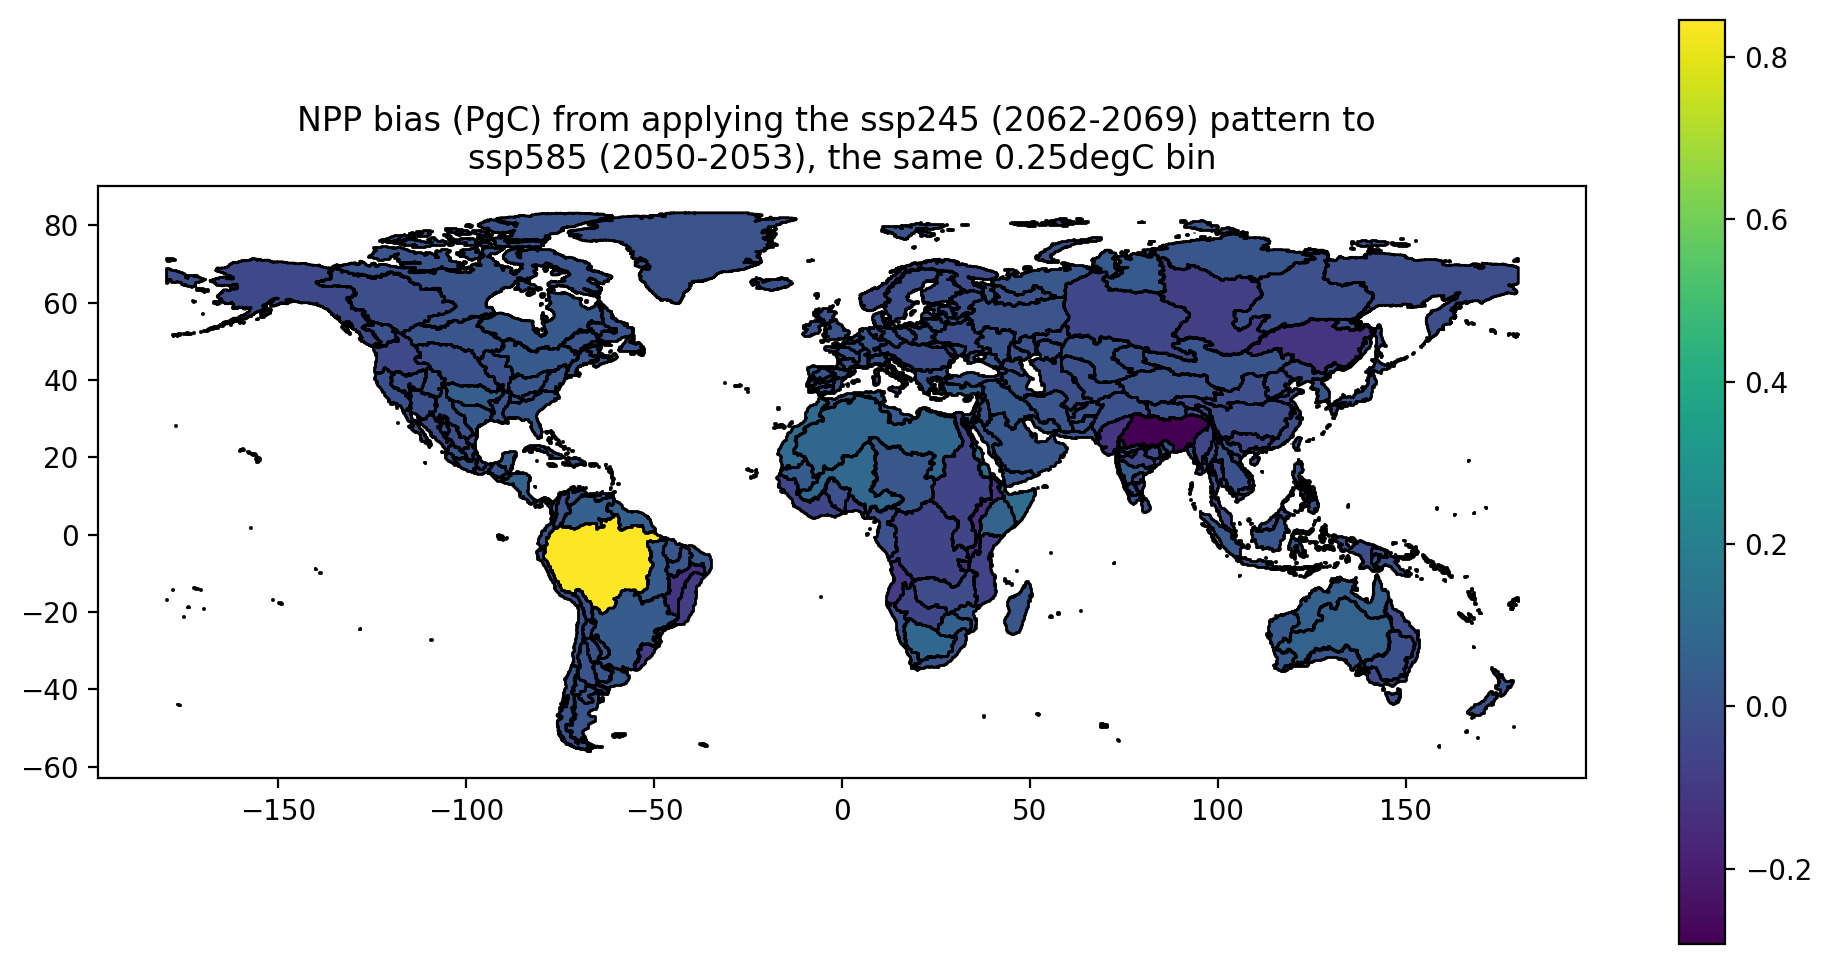

In [92]:
fig, ax = plt.subplots()

merged_shp.plot(column = 'npp_bias',
                ax=ax,
                legend=True,
                edgecolor='black')
plt.title("NPP bias (PgC) from applying the ssp245 (2062-2069) pattern to \nssp585 (2050-2053), the same 0.25degC bin")
plt.savefig("figs/ssp245_2062to2069_NPP_gcam_bias.png", dpi=300, bbox_inches="tight")
plt.show()


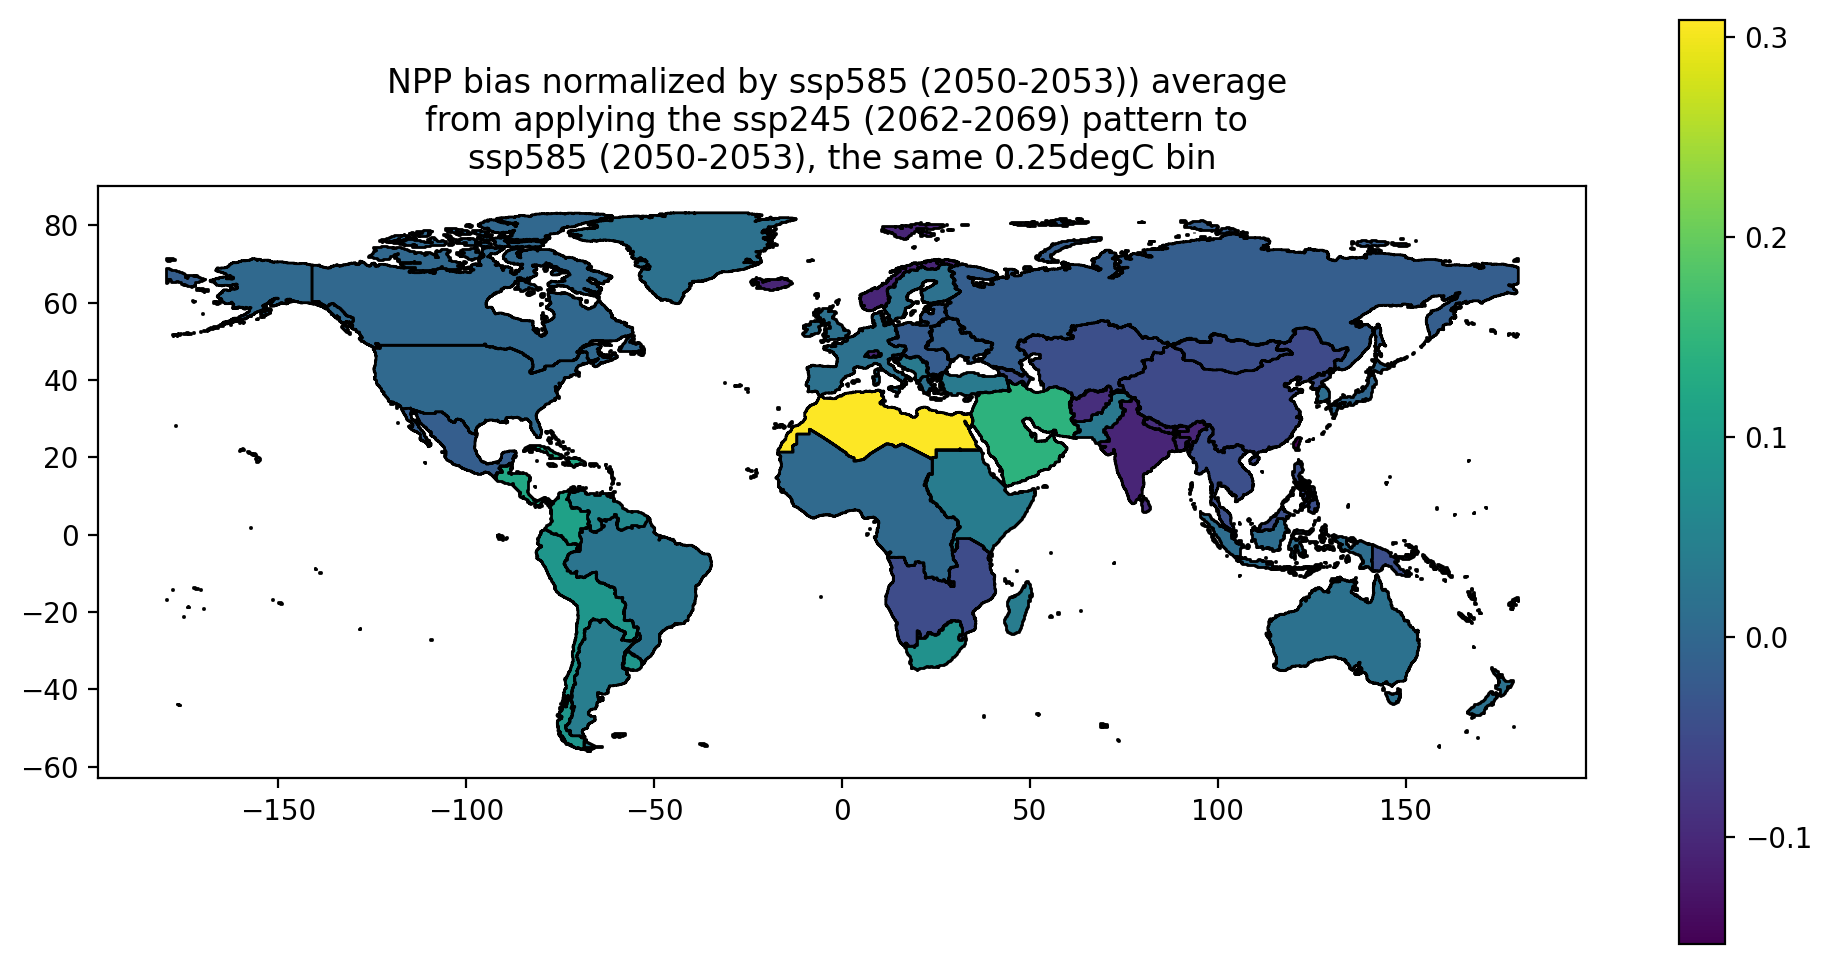

,key,reg_id,reg_nm,geometry,single_id,npp_bias,npp,spatial_ref,bias/npp
2,3,3,Africa_Northern,"MULTIPOLYGON (((11.16667 34.91667, 11.33333 34...",Africa_Northern,0.151539,0.491520,0,0.308308
29,30,30,Taiwan,"MULTIPOLYGON (((118.25 24.5, 118.5 24.5, 118.5...",Taiwan,-0.008399,0.054725,0,-0.153468
20,21,21,Middle East,"MULTIPOLYGON (((52.08333 12.33333, 52.16667 12...",Middle East,0.084302,0.589808,0,0.142931
8,9,9,Central America and Caribbean,"MULTIPOLYGON (((-59.66667 13.41667, -59.58333 ...",Central America and Caribbean,0.077168,0.627940,0,0.122890
31,32,32,Colombia,"MULTIPOLYGON (((-71.66667 12.58333, -71.58333 ...",Colombia,0.141482,1.283036,0,0.110271
16,17,17,India,"MULTIPOLYGON (((93.66667 7.5, 93.75 7.5, 93.75...",India,-0.512394,4.821292,0,-0.106277
15,16,16,European Free Trade Association,"MULTIPOLYGON (((8.5 47.83333, 8.66667 47.83333...",European Free Trade Association,-0.016391,0.154611,0,-0.106013
26,27,27,South Asia,"MULTIPOLYGON (((79.91667 9.91667, 80.08333 9.9...",South Asia,-0.056569,0.607301,0,-0.093148
25,26,26,South America_Southern,"MULTIPOLYGON (((-109.41667 -27, -109.25 -27, -...",South America_Southern,0.312257,3.494480,0,0.089357
23,24,24,South Africa,"MULTIPOLYGON (((37.58333 -46.75, 37.83333 -46....",South Africa,0.090883,1.162566,0,0.078174


In [66]:
# and normalized by region average NPP in ssp585 2050-2053 
merged_shp_normalized = merged_shp.merge(field_comb.mean(dim='time').to_dataframe().reset_index(),
                       on = 'single_id',
                       how ='left')
merged_shp_normalized['bias/npp'] = merged_shp_normalized['npp_bias']/merged_shp_normalized['npp']

fig, ax = plt.subplots()

merged_shp_normalized.plot(column = 'bias/npp',
                ax=ax,
                legend=True,
                edgecolor='black')
plt.title("NPP bias normalized by ssp585 (2050-2053)) average \nfrom applying the ssp245 (2062-2069) pattern to \nssp585 (2050-2053), the same 0.25degC bin")
plt.show()

merged_shp_normalized.sort_values(by = 'bias/npp', key = abs, ascending=False)


25 out of 32 regions have bias magnitude <10% the ssp585 average, and we were never going to do great in Africa Northern to begin with.

Likely that at the basin or land unit (basin intersect region), will do worse than this but better than grid scale and that's probably good enough?

# DO it for the land units

In [93]:
# load up the shape files
import geopandas as gpd
import rioxarray as rxr

#shp = gpd.read_file("reg_glu_boundaries_moirai_combined_3p1_0p5arcmin.shp") # https://zenodo.org/records/4688451
#shp['single_id'] = shp['reg_nm'] + '~' + shp['glu_nm']

shp = gpd.read_file("glu_boundaries_moirai_combined_3p1_0p5arcmin.shp") # https://zenodo.org/records/4688451
shp['single_id'] =  shp['glu_nm']
shp

,key,glu_id,glu_nm,geometry,single_id
0,1,1,Arctic_Ocean_Islands,"MULTIPOLYGON (((67.16667 77.08333, 68.25 77.08...",Arctic_Ocean_Islands
1,2,2,Northwest_Territories,"MULTIPOLYGON (((-78 64.08333, -77.66667 64.083...",Northwest_Territories
2,3,3,Siberia_North_Coast,"MULTIPOLYGON (((124.16667 70.91667, 124.25 70....",Siberia_North_Coast
3,4,4,Siberia_West_Coast,"MULTIPOLYGON (((146.58333 43.91667, 146.83333 ...",Siberia_West_Coast
4,5,5,Kara_Sea_Coast,"MULTIPOLYGON (((79 73.16667, 79.33333 73.16667...",Kara_Sea_Coast
5,6,6,Lena,"MULTIPOLYGON (((140.75 60.25, 140.91667 60.25,...",Lena
6,7,7,Pacific_and_Arctic_Coast,"MULTIPOLYGON (((-178.25 52, -177.91667 52, -17...",Pacific_and_Arctic_Coast
7,8,8,Scandinavia_North_Coast,"MULTIPOLYGON (((25.66667 71.25, 25.83333 71.25...",Scandinavia_North_Coast
8,9,9,Russia_Barents_Sea_Coast,"MULTIPOLYGON (((42.58333 66.83333, 42.75 66.83...",Russia_Barents_Sea_Coast
9,10,10,Mackenzie,"MULTIPOLYGON (((-135.25 69.5, -135 69.5, -135 ...",Mackenzie


In [94]:
# need to give xarray data sets a CRS, set the spatial dimension names so that
# polygon specific clipping and aggregatio works,
# and change the lon range to -180 to 180 to match the shapes
field_fut1 =field_fut.rio.write_crs("EPSG:4326")
field_fut1 = field_fut1.rio.set_spatial_dims(x_dim="lon", y_dim="lat")
field_fut1.coords["lon"] = (field_fut1.coords['lon'] +180) % 360 - 180
field_fut1 = field_fut1.sortby('lon')

yhat_fut1 = yhat_fut.rio.write_crs("EPSG:4326")
yhat_fut1 = yhat_fut1.rio.set_spatial_dims(x_dim="lon", y_dim="lat")
yhat_fut1.coords["lon"] = (yhat_fut1.coords['lon'] +180) % 360 - 180
yhat_fut1 = yhat_fut1.sortby('lon')

# force the shp file to have the same CRS 
shp = shp.to_crs(field_fut1.rio.crs)

# loop over polygons and do the aggregation in each
yhat_fut2 = []
field_fut2 = []

for index, row in shp.iterrows():

  poly_geometry = [row.geometry]

  # real data
  try:
      # Summation because NPP; other vars would need grid cell area weighted mean.
      field_fut2.append(field_fut1.rio.clip(poly_geometry, 
                                            field_fut1.rio.crs,
                                            drop=True).sum(dim=['lat','lon']).assign_coords(single_id = row['single_id']).expand_dims('single_id'))
  except:
    # We clip using 'all_touched=True' or without dropping to generate the grid footprint
    # then force everything to 0.

    # Clip without dropping to match the exact regional coordinate grid lines, then fill with 0
    blank_poly = field_fut1.rio.clip(poly_geometry,
                                      field_fut1.rio.crs, 
                                      drop=False)
    blank_poly = blank_poly.fillna(0)  # Convert NaNs to 0

    # Crop it down manually using the bounds of the polygon to keep the list lightweight
    # (This ensures the bounding box shrinks just like drop=True would have done)
    minx, miny, maxx, maxy = row.geometry.bounds
    blank_poly = blank_poly.sel(
        {field_fut1.rio.x_dim: slice(minx, maxx), 
         field_fut1.rio.y_dim: slice(miny, maxy)}
    )

    blank_poly = blank_poly.assign_coords(single_id = row['single_id']).expand_dims('single_id')
    field_fut2.append(blank_poly)

  # and the created data. 
  # these data sets have the same grids so could prob include in single try/except but this feels a little safer
  # because it checks each of the npp sets (real and created) for non-overlap with the shapes separately
  try:
     yhat_fut2.append(yhat_fut1.rio.clip(poly_geometry, 
                                             yhat_fut1.rio.crs, 
                                             drop=True).sum(dim=['lat','lon']).assign_coords(single_id = row['single_id']).expand_dims('single_id'))

  except:
      # We clip using 'all_touched=True' or without dropping to generate the grid footprint
      # then force everything to 0.
      
      # # Clip without dropping to match the exact regional coordinate grid lines, then fill with 0
         blank_poly = yhat_fut1.rio.clip(poly_geometry,
                                           yhat_fut1.rio.crs, 
                                           drop=False)
         blank_poly = blank_poly.fillna(0)  # Convert NaNs to 0
     
         # Crop it down manually using the bounds of the polygon to keep the list lightweight
         # (This ensures the bounding box shrinks just like drop=True would have done)
         minx, miny, maxx, maxy = row.geometry.bounds
         blank_poly = blank_poly.sel(
             {yhat_fut1.rio.x_dim: slice(minx, maxx), 
              yhat_fut1.rio.y_dim: slice(miny, maxy)}
         )
     
         blank_poly = blank_poly.assign_coords(single_id = row['single_id']).expand_dims('single_id')
         yhat_fut2.append(blank_poly)

In [95]:
yhat_comb = xr.concat(yhat_fut2, dim = 'single_id')
field_comb = xr.concat(field_fut2, dim = 'single_id')
yhat_comb

/var/folders/_y/tftrxl2d0h1962g9ct_ccvwc0000gn/T/ipykernel_17593/1142999744.py:1: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'lat' ('lat',) The recommendation is to set join explicitly for this case.
  yhat_comb = xr.concat(yhat_fut2, dim = 'single_id')
/var/folders/_y/tftrxl2d0h1962g9ct_ccvwc0000gn/T/ipykernel_17593/1142999744.py:1: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'lon' ('lon',) The recommendation is to set join explicitly for this case.
  yhat_comb = xr.concat(yhat_fut2, dim = 'single_id')
/var

<xarray.Dataset> Size: 26MB
Dimensions:      (single_id: 235, time: 4, lat: 27, lon: 128)
Coordinates:
  * single_id    (single_id) <U44 41kB 'Arctic_Ocean_Islands' ... 'Narmada'
  * time         (time) object 32B 2050-07-01 17:00:00 ... 2053-07-01 17:00:00
  * lat          (lat) float64 216B -26.51 -23.72 -20.93 ... 43.25 51.63 57.21
  * lon          (lon) float64 1kB -180.0 -177.2 -174.4 ... 171.6 174.4 177.2
    spatial_ref  int64 8B 0
Data variables:
    npp          (single_id, time, lat, lon) float64 26MB 0.002728 ... nan
Attributes: (12/57)
    CCCma_model_hash:            66c9146b8290f2c6ba88fd7d4119ba01e952e060
    CCCma_parent_runid:          rc3.1-his10
    CCCma_pycmor_hash:           33c30511acc319a98240633965a04ca99c26427e
    CCCma_runid:                 rc3.1-s8510
    Conventions:                 CF-1.7 CMIP-6.2
    YMDH_branch_time_in_child:   2015:01:01:00
    ...                          ...
    tracking_id:                 hdl:21.14100/5ff99cf0-39a3-4760-b6cc-44841c6...
    variable_id:                 npp
    variant_label:               r10i1p1f1
    version:                     v20190429
    version_id:                  v20190429
    units:                       Pg C

In [96]:
region_resids = yhat_comb-field_comb
bias = region_resids.mean(dim='time')
bias

<xarray.Dataset> Size: 7MB
Dimensions:      (single_id: 235, lat: 27, lon: 128)
Coordinates:
  * single_id    (single_id) <U44 41kB 'Arctic_Ocean_Islands' ... 'Narmada'
  * lat          (lat) float64 216B -26.51 -23.72 -20.93 ... 43.25 51.63 57.21
  * lon          (lon) float64 1kB -180.0 -177.2 -174.4 ... 171.6 174.4 177.2
    spatial_ref  int64 8B 0
Data variables:
    npp          (single_id, lat, lon) float64 6MB -0.0002182 -0.0002182 ... nan
Attributes: (12/57)
    CCCma_model_hash:            66c9146b8290f2c6ba88fd7d4119ba01e952e060
    CCCma_parent_runid:          rc3.1-his10
    CCCma_pycmor_hash:           33c30511acc319a98240633965a04ca99c26427e
    CCCma_runid:                 rc3.1-s8510
    Conventions:                 CF-1.7 CMIP-6.2
    YMDH_branch_time_in_child:   2015:01:01:00
    ...                          ...
    tracking_id:                 hdl:21.14100/5ff99cf0-39a3-4760-b6cc-44841c6...
    variable_id:                 npp
    variant_label:               r10i1p1f1
    version:                     v20190429
    version_id:                  v20190429
    units:                       Pg C

In [97]:

merged_shp = shp.merge(bias.to_dataframe().reset_index().drop(columns = ['lon', 'lat']).drop_duplicates(ignore_index=True),
                       on = 'single_id',
                       how ='left').rename(columns={'npp':'npp_bias'}).drop(columns=['spatial_ref'])
merged_shp

,key,glu_id,glu_nm,geometry,single_id,npp_bias
0,1,1,Arctic_Ocean_Islands,"MULTIPOLYGON (((67.16667 77.08333, 68.25 77.08...",Arctic_Ocean_Islands,-2.181681e-04
1,2,2,Northwest_Territories,"MULTIPOLYGON (((-78 64.08333, -77.66667 64.083...",Northwest_Territories,2.719402e-03
2,3,3,Siberia_North_Coast,"MULTIPOLYGON (((124.16667 70.91667, 124.25 70....",Siberia_North_Coast,1.048105e-02
3,4,4,Siberia_West_Coast,"MULTIPOLYGON (((146.58333 43.91667, 146.83333 ...",Siberia_West_Coast,-2.204734e-02
4,5,5,Kara_Sea_Coast,"MULTIPOLYGON (((79 73.16667, 79.33333 73.16667...",Kara_Sea_Coast,2.677780e-02
5,6,6,Lena,"MULTIPOLYGON (((140.75 60.25, 140.91667 60.25,...",Lena,-1.475605e-02
6,7,7,Pacific_and_Arctic_Coast,"MULTIPOLYGON (((-178.25 52, -177.91667 52, -17...",Pacific_and_Arctic_Coast,-4.288779e-02
7,8,8,Scandinavia_North_Coast,"MULTIPOLYGON (((25.66667 71.25, 25.83333 71.25...",Scandinavia_North_Coast,-3.058626e-02
8,9,9,Russia_Barents_Sea_Coast,"MULTIPOLYGON (((42.58333 66.83333, 42.75 66.83...",Russia_Barents_Sea_Coast,1.697992e-02
9,10,10,Mackenzie,"MULTIPOLYGON (((-135.25 69.5, -135 69.5, -135 ...",Mackenzie,-2.109513e-02


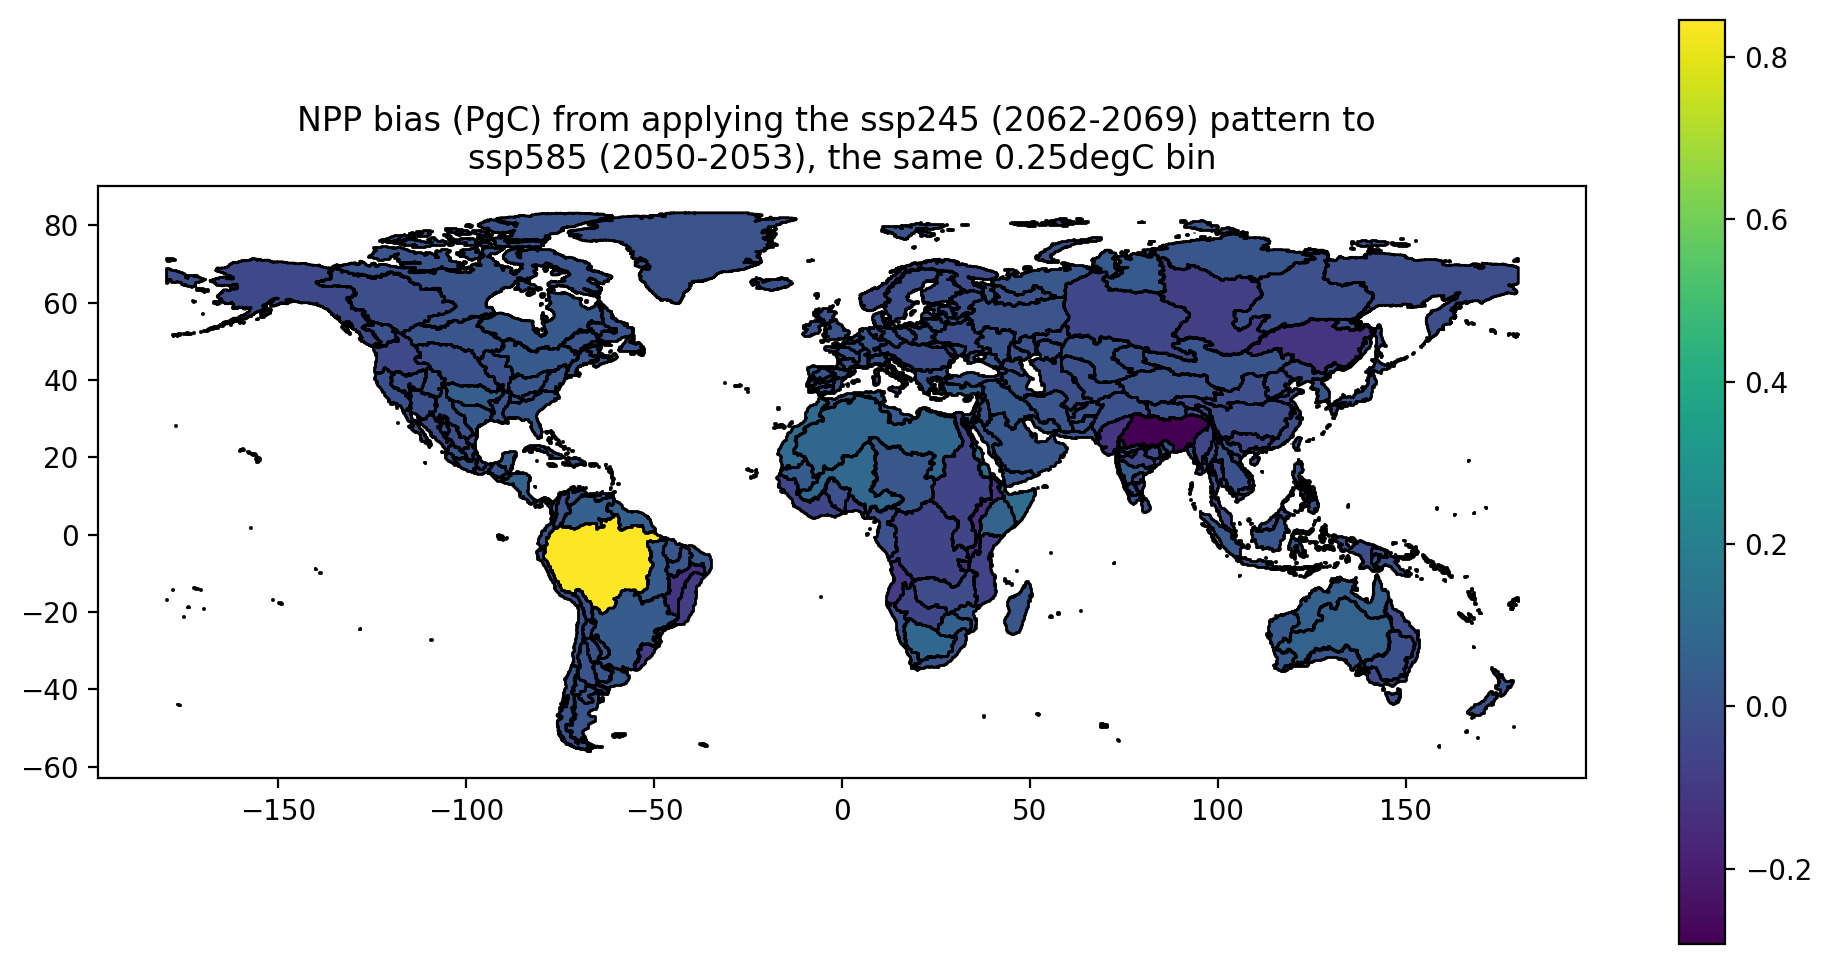

In [98]:
fig, ax = plt.subplots()

merged_shp.plot(column = 'npp_bias',
                ax=ax,
                legend=True,
                edgecolor='black')
plt.title("NPP bias (PgC) from applying the ssp245 (2062-2069) pattern to \nssp585 (2050-2053), the same 0.25degC bin")
plt.show()

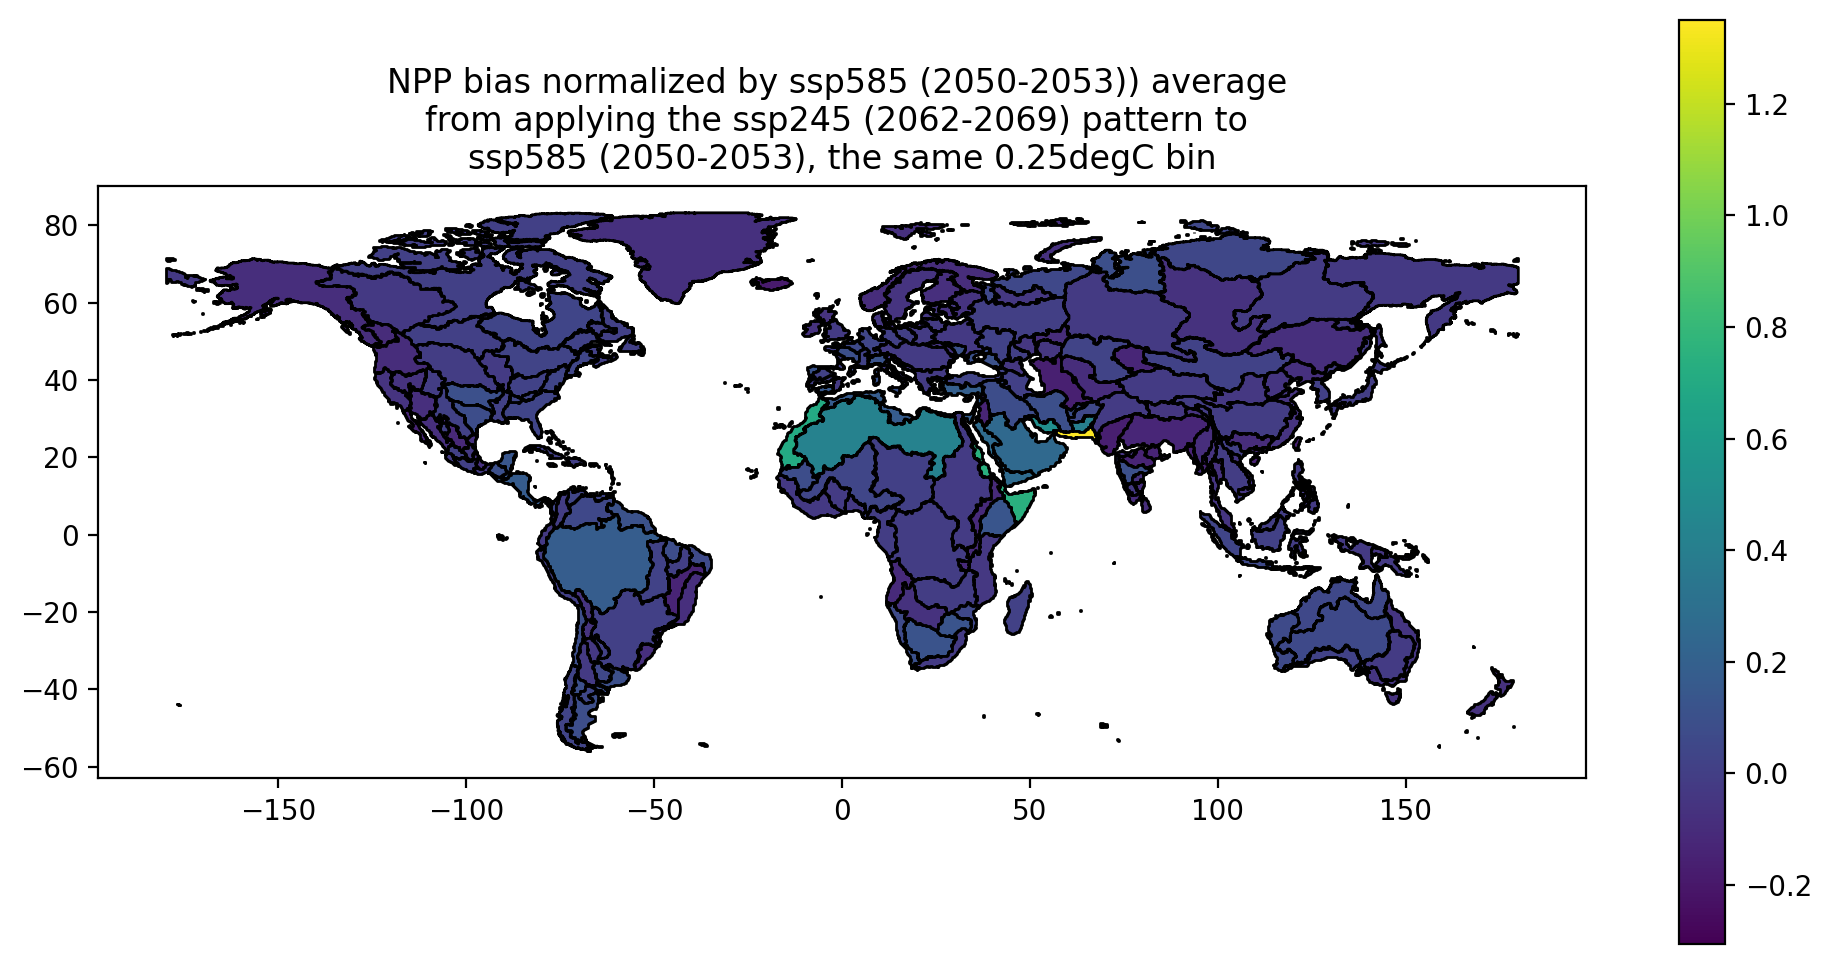

,key,glu_id,glu_nm,geometry,single_id,npp_bias,npp,spatial_ref,bias/npp
89,75,75,Mediterranean_Sea_East_Coast,"MULTIPOLYGON (((26.5 40.5, 27.33333 40.5, 27.3...",Mediterranean_Sea_East_Coast,0.052863,0.278102,0,0.190084
212,168,168,Amazon,"MULTIPOLYGON (((-60.75 5.25, -59.83333 5.25, -...",Amazon,0.845354,4.868072,0,0.173653
170,135,135,Southern_Central_America,"MULTIPOLYGON (((-81.83333 7.66667, -81.75 7.66...",Southern_Central_America,0.064568,0.381427,0,0.169280
130,107,107,Sabarmati,"MULTIPOLYGON (((72.41667 21.75, 72.5 21.75, 72...",Sabarmati,-0.117975,0.697431,0,-0.169156
155,123,123,Godavari,"POLYGON ((79.58333 22.66667, 80.25 22.66667, 8...",Godavari,-0.063353,0.444085,0,-0.142659
154,122,122,Mahandi,"POLYGON ((82.25 23.5, 82.5 23.5, 82.5 23.41667...",Mahandi,-0.038152,0.267843,0,-0.142443
242,192,192,Sao_Francisco,"POLYGON ((-40.33333 -7.25, -40.25 -7.25, -40.2...",Sao_Francisco,-0.126211,0.890950,0,-0.141659
134,111,111,Yucatan_Peninsula,"MULTIPOLYGON (((-87.91667 17.58333, -87.83333 ...",Yucatan_Peninsula,0.040709,0.298129,0,0.136549
133,110,110,Ganges_Bramaputra,"POLYGON ((79 31.5, 79.16667 31.5, 79.16667 31....",Ganges_Bramaputra,-0.292650,2.262933,0,-0.129323
214,170,170,Shebelli_Juba,"POLYGON ((42.66667 9.66667, 42.75 9.66667, 42....",Shebelli_Juba,0.063967,0.498942,0,0.128206


In [100]:
# and normalized by region average NPP in ssp585 2050-2053 
merged_shp_normalized = merged_shp.merge(field_comb.mean(dim='time').to_dataframe().reset_index().drop(columns = ['lon', 'lat']).drop_duplicates(ignore_index=True),
                       on = 'single_id',
                       how ='left')
merged_shp_normalized['bias/npp'] = merged_shp_normalized['npp_bias']/merged_shp_normalized['npp']

fig, ax = plt.subplots()

merged_shp_normalized.plot(column = 'bias/npp',
                ax=ax,
                legend=True,
                edgecolor='black')
plt.title("NPP bias normalized by ssp585 (2050-2053)) average \nfrom applying the ssp245 (2062-2069) pattern to \nssp585 (2050-2053), the same 0.25degC bin")
plt.savefig("figs/ssp245_2062to2069_normalize_NPP_bais.png", dpi=300, bbox_inches="tight")
plt.show()


# filter out places with <0.5PgC NPP
pd.set_option('display.max_rows', None)
merged_shp_normalized[merged_shp_normalized['npp']>0.2].sort_values(by = 'bias/npp', key = abs, ascending=False)

So definitely not great to have a 17% error in the amazon but not bad overall. only 7 out of 235 basins both have a decent amount of NPP (>0.2 Pg) and have error > 10%. 

- note that the errors are worse when doing intersection of regions and basins instead of just basins as here, because artifically chops up physical featrures. Eg the error in the Amazon for that is 21%

# TODO

1. convert code above into functions
2. apply systematically to more temperature bins and more ESMs and continue checking
3. With multiple ensemble members per experiment
4. at the GCAM land unit scale or basin sized
5. test 0.1deg bins - will be few years per realizationsXscenarioXesm but since learning the pattern across realizations and scenarios for each ESM, prob still enough data. 

In [56]:
# and bin 
binsize = 0.1
binedges = np.arange(-5, 10, binsize, )

gsat['group'] = pd.cut(gsat['smooth_value'], bins= binedges)

grouped_year_ranges = pd.DataFrame()    
for group_name, group_df in gsat.groupby(['group', 'experiment', 'ensemble', 'model']):
    #print(group_df)
    grouped_year_ranges = pd.concat([grouped_year_ranges,
                                     pd.DataFrame({
                                       'scenario': group_df['experiment'].unique(),  
                                       'ensemble': group_df['ensemble'].unique(), 
                                       'model': group_df['model'].unique(), 
                                       'start_yr': np.min(group_df['year']),
                                       'stop_yr': np.max(group_df['year']),
                                       'group': group_df['group'].unique()
                                     })],
                                     ignore_index=True)
# end for over groups in historical


grouped_year_ranges

,scenario,ensemble,model,start_yr,stop_yr,group
0,historical,r10i1p1f1,CanESM5,1850,1854,"(-0.3, -0.2]"
1,historical,r10i1p1f1,CanESM5,1851,1858,"(-0.2, -0.1]"
2,historical,r10i1p1f1,CanESM5,1853,1918,"(-0.1, -1.78e-14]"
3,historical,r10i1p1f1,CanESM5,1856,1924,"(-1.78e-14, 0.1]"
4,historical,r10i1p1f1,CanESM5,1860,1943,"(0.1, 0.2]"
5,historical,r10i1p1f1,CanESM5,1930,1983,"(0.2, 0.3]"
6,historical,r10i1p1f1,CanESM5,1949,1993,"(0.3, 0.4]"
7,historical,r10i1p1f1,CanESM5,1994,1996,"(0.4, 0.5]"
8,historical,r10i1p1f1,CanESM5,1997,1998,"(0.5, 0.6]"
9,historical,r10i1p1f1,CanESM5,1999,2000,"(0.6, 0.7]"
